# Business Objective 

An E Commerce company or DTH (you can choose either of these two domains) provider is 
facing a lot of competition in the current market and it has become a challenge to retain the 
existing customers in the current situation. Hence, the company wants to develop a model 
through which they can do churn prediction of the accounts and provide segmented offers to the 
potential churners. In this company, account churn is a major thing because 1 account can have 
multiple customers. hence by losing one account the company might be losing more than one 
customer. 
<br></br>
You have been assigned to develop a churn prediction model for this company and provide 
business recommendations on the campaign. 
Your campaign suggestion should be unique and be very clear on the campaign offer because 
your recommendation will go through the revenue assurance team. If they find that you are 
giving a lot of free (or subsidized) stuff thereby making a loss to the company; they are not going 
to approve your recommendation.<br></br>
Hence be very careful while providing campaign recommendation.

# Import Libraries

In [193]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format',lambda x :'%.2f'%x)
pd.set_option('display.max_columns',None)

import scipy.stats as stats # for Chisquare
from sklearn.model_selection import train_test_split,RandomizedSearchCV,cross_validate,StratifiedKFold

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

from statsmodels.stats.outliers_influence import variance_inflation_factor

#models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier,RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

#Evaluation metrics
import sklearn.metrics as metrics
from sklearn.metrics import (
accuracy_score,recall_score,precision_score,f1_score,confusion_matrix,make_scorer,roc_auc_score,roc_curve,precision_recall_curve,classification_report
)


from sklearn.decomposition import PCA

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# Import Data

In [4]:
#import os
#os.chdir(C:/Users/Ashwin/OneDrive/Documents/Great Learning/Capestone/)
data=pd.read_excel('Customer Churn Data.xlsx',sheet_name='Data for DSBA')

# Sanity Check

## Data Overview

**Displaying first 5 records**

In [5]:
data.head()

,AccountID,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
0,20000,1,4,3.00,6.00,Debit Card,Female,3.00,3,Super,2.00,Single,9,1.00,11,1,5,159.93,Mobile
1,20001,1,0,1.00,8.00,UPI,Male,3.00,4,Regular Plus,3.00,Single,7,1.00,15,0,0,120.90,Mobile
2,20002,1,0,1.00,30.00,Debit Card,Male,2.00,4,Regular Plus,3.00,Single,6,1.00,14,0,3,NaN,Mobile
3,20003,1,0,3.00,15.00,Debit Card,Male,2.00,4,Super,5.00,Single,8,0.00,23,0,3,134.07,Mobile
4,20004,1,0,1.00,12.00,Credit Card,Male,2.00,3,Regular Plus,5.00,Single,3,0.00,11,1,3,129.60,Mobile


**Displaying last 5 records**

In [6]:
data.tail()

,AccountID,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
11255,31255,0,10,1.00,34.00,Credit Card,Male,3.00,2,Super,1.00,Married,9,0.00,19,1,4,153.71,Computer
11256,31256,0,13,1.00,19.00,Credit Card,Male,3.00,5,HNI,5.00,Married,7,0.00,16,1,8,226.91,Mobile
11257,31257,0,1,1.00,14.00,Debit Card,Male,3.00,2,Super,4.00,Married,7,1.00,22,1,4,191.42,Mobile
11258,31258,0,23,3.00,11.00,Credit Card,Male,4.00,5,Super,4.00,Married,7,0.00,16,2,9,179.90,Computer
11259,31259,0,8,1.00,22.00,Credit Card,Male,3.00,2,Super,3.00,Married,5,0.00,13,2,3,175.04,Mobile


In [7]:
data.sample(n=5,random_state=1)

,AccountID,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
784,20784,0,0,1.00,31.00,Debit Card,Female,2.00,1,Regular Plus,2.00,Single,2,1.00,12,1,1,129.94,Mobile
6943,26943,1,0,3.00,22.00,E wallet,Male,2.00,3,Regular Plus,5.00,Married,5,0.00,20,1,0,119.90,Computer
3709,23709,0,10,3.00,23.00,E wallet,Female,4.00,5,Super,5.00,Divorced,6,0.00,14,2,NaN,181.47,Mobile
6439,26439,0,0,1.00,10.00,Credit Card,Female,2.00,3,Regular Plus,4.00,Single,4,0.00,19,1,1,120.96,Mobile
5310,25310,0,9,1.00,25.00,Debit Card,Male,3.00,2,Super,5.00,Married,3,0.00,12,2,11,177.08,Mobile


### Observation:

- The dataset begins with AccountID 20000 and ends with AccountID 31259.
- The target variable for prediction is Churn.
- Some of the features contain the value 0, which warrants further analysis to assess relevance or data quality.
- Missing values are present in the dataset and will need to be addressed during preprocessing.


## Data shape

In [8]:
data.shape

(11260, 19)

This Data set has 11,260 rows and 19 columna

## Data information

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11260 entries, 0 to 11259
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   AccountID                11260 non-null  int64  
 1   Churn                    11260 non-null  int64  
 2   Tenure                   11158 non-null  object 
 3   City_Tier                11148 non-null  float64
 4   CC_Contacted_LY          11158 non-null  float64
 5   Payment                  11151 non-null  object 
 6   Gender                   11152 non-null  object 
 7   Service_Score            11162 non-null  float64
 8   Account_user_count       11148 non-null  object 
 9   account_segment          11163 non-null  object 
 10  CC_Agent_Score           11144 non-null  float64
 11  Marital_Status           11048 non-null  object 
 12  rev_per_month            11158 non-null  object 
 13  Complain_ly              10903 non-null  float64
 14  rev_growth_yoy        

### Observation:

- Account ID can be excluded from the analysis.
- Out of the 19 columns, only one column has complete data—the rest contain missing values.
- The dataset includes 5 float columns, 2 integer columns, and 12 object (string) columns.
- Among the 12 object columns, the following features appear to be misclassified and should ideally be numeric:
    - Tenure
    - Account_user_count
    - rev_per_month
    - rev_growth_yoy
    - coupon_used_for_payment
    - Day_Since_CC_connect
    - cashback

These will need appropriate type conversion and validation.



## Treating Inconsistency in the columns

In [10]:
for i in data.columns:
    print(i)
    print(data[i].unique())
    print('*'*30)

AccountID
[20000 20001 20002 ... 31257 31258 31259]
******************************
Churn
[1 0]
******************************
Tenure
[4 0 2 13 11 '#' 9 99 19 20 14 8 26 18 5 30 7 1 23 3 29 6 28 24 25 16 10
 15 22 nan 27 12 21 17 50 60 31 51 61]
******************************
City_Tier
[ 3.  1. nan  2.]
******************************
CC_Contacted_LY
[  6.   8.  30.  15.  12.  22.  11.   9.  31.  18.  13.  20.  29.  28.
  26.  14.  10.  25.  27.  17.  23.  33.  19.  35.  24.  16.  32.  21.
  nan  34.   5.   4. 126.   7.  36. 127.  42.  38.  37.  39.  40.  41.
 132.  43. 129.]
******************************
Payment
['Debit Card' 'UPI' 'Credit Card' 'Cash on Delivery' 'E wallet' nan]
******************************
Gender
['Female' 'Male' 'F' nan 'M']
******************************
Service_Score
[ 3.  2.  1. nan  0.  4.  5.]
******************************
Account_user_count
[3 4 nan 5 2 '@' 1 6]
******************************
account_segment
['Super' 'Regular Plus' 'Regular' 'HNI' 'Regular 

### Observation:

- City_Tier should be converted as Object for categorical representation.
- Complain_ly has only binary value hence we can change it as object for categorical representation.
- The Tenure column contains the special character #.
- The Gender column includes mixed representations such as 'Female', 'Male', 'F', and 'M'.
- The Account_user_count field contains the @ symbol.
- rev_per_month has values with a + symbol that need to be cleaned for numeric conversion.
- rev_growth_yoy includes entries with the $ symbol.
- The coupon_used_for_payment field contains various symbols like $, #, and *.
- Day_Since_CC_connect also includes values with the $ symbol.
- The Login_device column contains entries like '&&&&'.
- account_segment has Regular Plus ,'Regular + , Super Plus , Super +
- Service_Score - Rating of 0 is not typically valid in most scoring systems, these entries likely represent missing or invalid responses and should be treated as non-values (NaN) for appropriate handling in subsequent analysis

Appart from this most of the columns have nan values, which can be teated while performing missing value treatment.

#### Object Columns

In [11]:
data['Gender'].replace(['M','F'],['Male','Female'],inplace=True)

In [12]:
data['Login_device'].replace('&&&&',np.nan,inplace=True)

In [13]:
data['account_segment']=data['account_segment'].str.replace('+','Plus')

In [14]:
data['Service_Score'].replace(0,np.nan,inplace=True)

#### Number columns

In [15]:
numer_columns_to_be_checked=['Churn','Tenure','City_Tier','CC_Contacted_LY','Service_Score',
                             'Account_user_count','CC_Agent_Score','rev_per_month','rev_growth_yoy','Complain_ly',
                            'coupon_used_for_payment','Day_Since_CC_connect','cashback']

In [16]:
# Among the numer_columns_to_be_checked identifies the columns that are Object tipe
wrong_object_columns=[]
for i in numer_columns_to_be_checked:
    if data[i].dtype == 'object':
        wrong_object_columns.append(i)

In [17]:
# converts the non numeric charactes to nan in the wrong_object_columns
for i in wrong_object_columns:
    data.loc[data[i].str.isdigit()==False,i]=np.nan

In [18]:
# Changes the datatype of wrong_object_columns to float
for i in wrong_object_columns:
    data[i]=data[i].astype(float)

#### changing number columns as object

In [19]:
data['City_Tier']=data['City_Tier'].astype('object')

In [20]:
data['Complain_ly']=data['Complain_ly'].astype('object')

### Checking data information after treating inconsistency

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11260 entries, 0 to 11259
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   AccountID                11260 non-null  int64  
 1   Churn                    11260 non-null  int64  
 2   Tenure                   11042 non-null  float64
 3   City_Tier                11148 non-null  object 
 4   CC_Contacted_LY          11158 non-null  float64
 5   Payment                  11151 non-null  object 
 6   Gender                   11152 non-null  object 
 7   Service_Score            11154 non-null  float64
 8   Account_user_count       10816 non-null  float64
 9   account_segment          11163 non-null  object 
 10  CC_Agent_Score           11144 non-null  float64
 11  Marital_Status           11048 non-null  object 
 12  rev_per_month            10469 non-null  float64
 13  Complain_ly              10903 non-null  object 
 14  rev_growth_yoy        

### Observation:

- The following columns contained inconsistent data types and have been cleaned and converted to float:
    - Tenure
    - Account_user_count
    - rev_per_month
    - rev_growth_yoy
    - coupon_used_for_payment
    - Day_Since_CC_connect
    - cashback
- Missing values in the Login_device column increased due to the replacement of '&&&&' with NaN.
- Values in the Gender column were standardized by converting 'M' and 'F' to 'Male' and 'Female', respectively.




In [22]:
data['Churn']=data['Churn'].astype('object')

changing Churn as Object for analysis purpose

## Statistical Summary

#### Numeric data

In [23]:
np.round(data.describe(include=np.number).T)

,count,mean,std,min,25%,50%,75%,max
AccountID,11260.00,25630.00,3251.00,20000.00,22815.00,25630.00,28444.00,31259.00
Tenure,11042.00,11.00,13.00,0.00,2.00,9.00,16.00,99.00
CC_Contacted_LY,11158.00,18.00,9.00,4.00,11.00,16.00,23.00,132.00
Service_Score,11154.00,3.00,1.00,1.00,2.00,3.00,3.00,5.00
Account_user_count,10816.00,4.00,1.00,1.00,3.00,4.00,4.00,6.00
CC_Agent_Score,11144.00,3.00,1.00,1.00,2.00,3.00,4.00,5.00
rev_per_month,10469.00,6.00,12.00,1.00,3.00,5.00,7.00,140.00
rev_growth_yoy,11257.00,16.00,4.00,4.00,13.00,15.00,19.00,28.00
coupon_used_for_payment,11257.00,2.00,2.00,0.00,1.00,1.00,2.00,16.00
Day_Since_CC_connect,10902.00,5.00,4.00,0.00,2.00,3.00,8.00,47.00


### Observation

Tenure :

Based on the available data, the average tenure is 11 months, with a minimum of 0 months, indicating that some users may be churning before completing even one full month. The maximum tenure observed is 99 months. Since the mean is greater than the median, the distribution is right-skewed, and the data shows a standard deviation of 12 months.

CC_Contacted_LY :

On average, all customers associated with an account contacted customer care 18 times over the past 12 months. The minimum number of contacts was 4, and the maximum reached 132. Notably, the large gap between the 75th percentile and the maximum value indicates the presence of high outliers. Since the mean is less than the median, the distribution is left-skewed, suggesting that while most users cluster around higher values, a significant portion made relatively few contacts


Service_Score :

The Service_score ranges from 1 to 5, with a mean of 3. Approximately 75% of customers rated the service as 3 or below, indicating that higher satisfaction levels are relatively rare.

Account_user_count :

On average, 4 customers are tagged to a single account, with the minimum being 1 and the maximum reaching 6. Approximately 75% of accounts have 4 or fewer customers associated with them. This suggests a fairly compact distribution, with the majority of accounts hosting small customer groups.

CC_Agent_Score :

The CC_Agent_Score ranges from 1 to 5, with a mean of 3, indicating a moderate average perception of agent performance. Notably, in 75% of the cases, the score is 4 or below, suggesting that higher ratings are less frequent and that the majority of customers rate their customer care experience as average or slightly above average.

rev_per_month :

Assuming the revenue is reported in USD, the rev_per_month column shows a mean of `$`6, with values ranging from a minimum of `$`1 to a maximum of `$`140. Since the mean is greater than the median, the distribution is right-skewed, suggesting that a small number of high-revenue observations are pulling the average upward. The standard deviation is $12, indicating substantial variability in customer revenue across accounts.

rev_growth_yoy :

The rev_growth_yoy column shows a mean of `$`16, with values ranging from a minimum of `$`4 to a maximum of `$`28. Since the mean is greater than the median, the distribution is right-skewed, suggesting that a small number of high-revenue observations are pulling the average upward. The standard deviation is $4.

coupon_used_for_payment:

Over the past 12 months, customers have used coupons for payments an average of 2 times, with usage ranging from a minimum of 0 to a maximum of 16 times. Despite the maximum being relatively high, approximately 75% of customers have used coupons 2 times or fewer, indicating that frequent coupon usage. 

Day_Since_CC_connect :

The number of days since no customers contacted customer care ranges from a minimum of 0 days to a maximum of 47 days. The average (mean) is 5 days, while 75% of the time, the count is 8 days or fewer. 

Cashback :

Over the last 12 months, the cashback generated per account ranges from a minimum of 0 to a maximum of 1997. While the mean cashback is notably greater than the median, indicating a right-skewed distribution, approximately 75% of accounts received 200 or less in cashback. The data shows a standard deviation of 179.

#### Object data

In [24]:
data.describe(exclude=np.number).T

,count,unique,top,freq
Churn,11260,2,0,9364
City_Tier,11148.00,3.00,1.00,7263.00
Payment,11151,5,Debit Card,4587
Gender,11152,2,Male,6704
account_segment,11163,5,Regular Plus,4124
Marital_Status,11048,3,Married,5860
Complain_ly,10903.00,2.00,0.00,7792.00
Login_device,10500,2,Mobile,7482


### Observation

Churn :

The target column is binary, with values 0 and 1. A value of 1 indicates customers who have churned, whereas 0 represents those who have retained. The dataset is imbalanced, with a majority of records labeled as 0, suggesting that most customers in the dataset did not churn.

City_Tier :

The City_Tier column consists of three distinct tiers: 1, 2, and 3. Among these, Tier 3 accounts for the largest share of customers.

Payment :

The dataset includes five distinct payment modes, among which Debit Card emerges as the most widely preferred option by customers

Gender :

The dataset shows a higher number of male customers compared to female customers.

account_segment :

The dataset includes five distinct account segments, among which ‘Regular Plus’ is the most preferred by customers.

Marital_Status :

The dataset includes customers across three marital statuses, with Married individuals forming the largest group.

Complain_ly :

This column contains binary values, where 1 indicates that a complaint was raised by the customer in the past 12 months, and 0 indicates no complaint. The data shows that the majority of customers have not raised any complaints.

Login_device :

The dataset features two types of login devices, with Mobile being the most commonly used among customers.

## Duplicate detection

In [25]:
data.duplicated().sum()

0

This dataset has no Duplicates.

## Identifying missing values

In [26]:
missing_data=(data.isnull().sum()[data.isnull().sum()>0]/data.shape[0])*100

In [27]:
missing_data=missing_data.reset_index()
missing_data.columns=['Columns','Missing_percentage']

In [28]:
missing_data.sort_values(by='Missing_percentage',ascending=False).reset_index(drop=True)[:5]

,Columns,Missing_percentage
0,rev_per_month,7.02
1,Login_device,6.75
2,cashback,4.20
3,Account_user_count,3.94
4,Day_Since_CC_connect,3.18


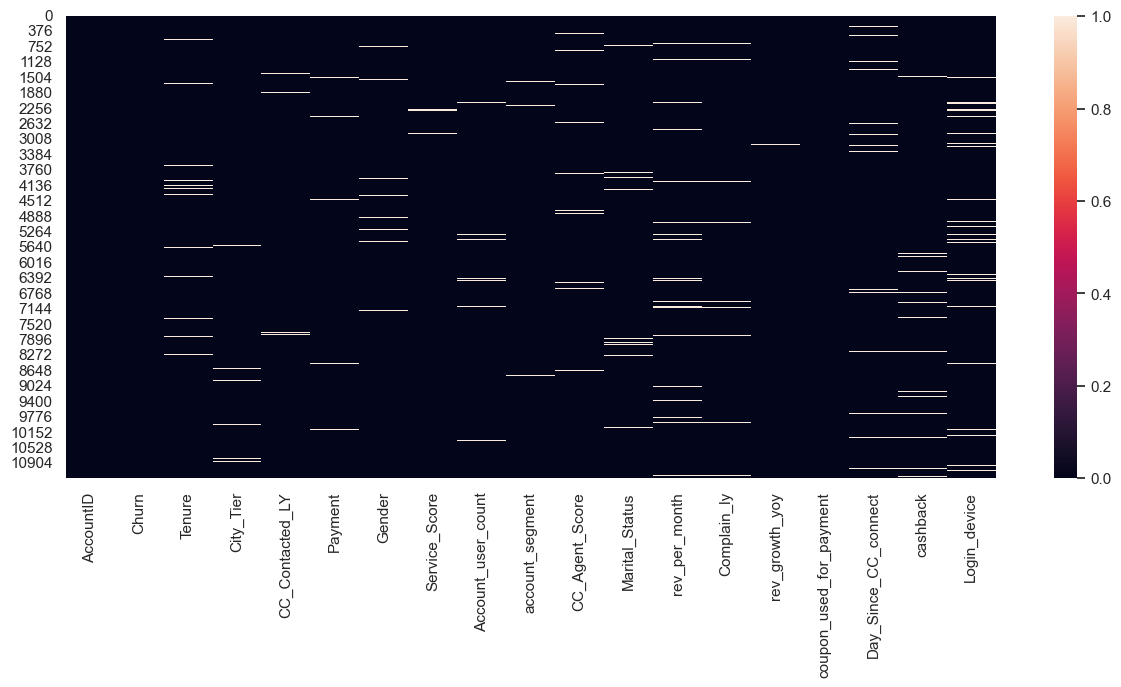

In [29]:
plt.figure(figsize=(15,6))
sns.heatmap(data.isnull())
plt.show()

### Data after initial clean up.

In [30]:
data_cleaned=data.copy()

In [31]:
# Account ID can be droped
data_cleaned.drop('AccountID',axis=1,inplace=True)

In [32]:
data_cleaned.head()

,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
0,1,4.00,3.00,6.00,Debit Card,Female,3.00,3.00,Super,2.00,Single,9.00,1.00,11.00,1.00,5.00,159.93,Mobile
1,1,0.00,1.00,8.00,UPI,Male,3.00,4.00,Regular Plus,3.00,Single,7.00,1.00,15.00,0.00,0.00,120.90,Mobile
2,1,0.00,1.00,30.00,Debit Card,Male,2.00,4.00,Regular Plus,3.00,Single,6.00,1.00,14.00,0.00,3.00,NaN,Mobile
3,1,0.00,3.00,15.00,Debit Card,Male,2.00,4.00,Super,5.00,Single,8.00,0.00,23.00,0.00,3.00,134.07,Mobile
4,1,0.00,1.00,12.00,Credit Card,Male,2.00,3.00,Regular Plus,5.00,Single,3.00,0.00,11.00,1.00,3.00,129.60,Mobile


# Univariate Analysis

In [33]:
numeric_columns=data_cleaned.select_dtypes(include=np.number).columns

In [34]:
object_columns=data_cleaned.select_dtypes(exclude=np.number).columns

## Univariate Analysis for Object columns

In [35]:
#labelled bar greph
def bar_graph(data,feature,perc=True,n=None):
    total=len(data[feature]) # total numer of records in the column
    count=data[feature].nunique() # number of unique data

#    if n is None:
#        plt.figure(figsize=(count+2,4))
#    else:
#        plt.figure(figsize=(n+2,4))

    ax=sns.countplot(data=data,x=feature,palette='viridis',order=data[feature].value_counts().index[:n])

    for p in ax.patches:
        if perc==True:
            label="{:.2f}%".format((p.get_height()/total*100))
        else:
            label=p.get_height()

        x = p.get_x()+p.get_width()/2
        y = p.get_height()

        ax.annotate(
            label,
            (x,y),
            size=12,
            ha='center',
            va='center',
            xytext=(0,5),
            textcoords='offset points'
            )
    plt.title(feature,fontweight='bold',fontsize=18,color='red')
    plt.xticks(rotation=45)
plt.show()        

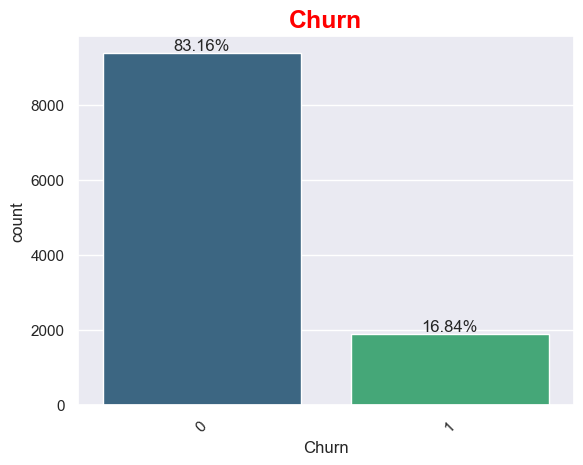

In [36]:
bar_graph(data_cleaned,'Churn',perc=True,n=None)
plt.show()

* 83.16% of customers do not churn, while only 16.84% do. This indicates a significant imbalance in the dataset.

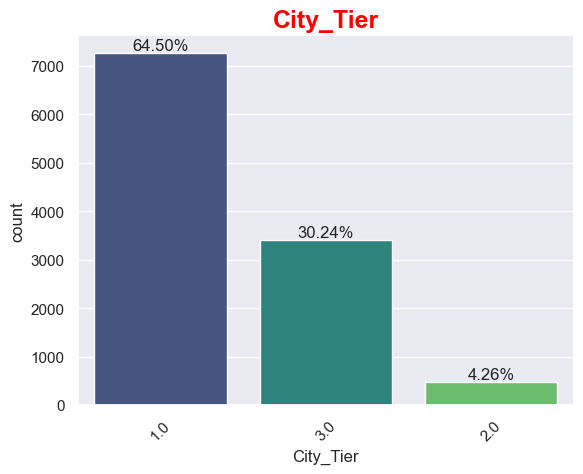

In [37]:
bar_graph(data_cleaned,'City_Tier',perc=True,n=None)
plt.show()

- The majority of customers (64.50%) are concentrated in City Tier 1, followed by 30.24% in City Tier 3. 
- City Tier 2 accounts for only a small share, with just 4.26% of the customer base.

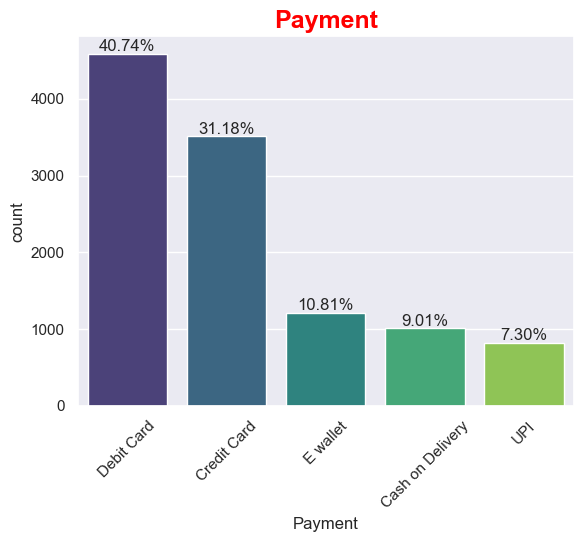

In [38]:
bar_graph(data_cleaned,'Payment',perc=True,n=None)
plt.show()

- Debit cards are the most preferred payment mode among customers, with 40.74% opting for them. Credit cards follow at 31.18%.
- UPI lags significantly behind, chosen by only 7.30% of customers.

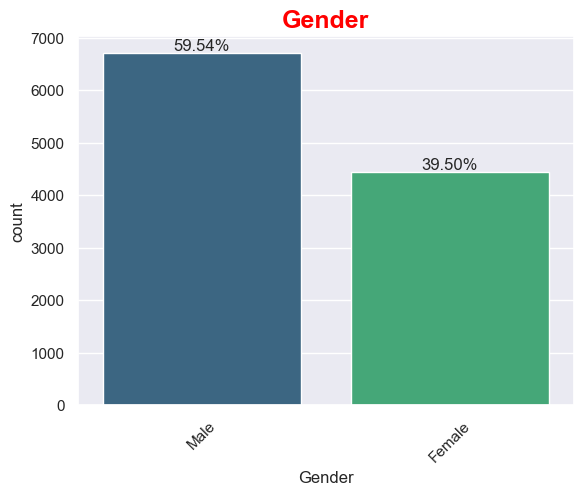

In [39]:
bar_graph(data_cleaned,'Gender',perc=True,n=None)
plt.show()

- Male customers constitute the majority at 59.54%, while female customers represent 39.50% of the customer base.

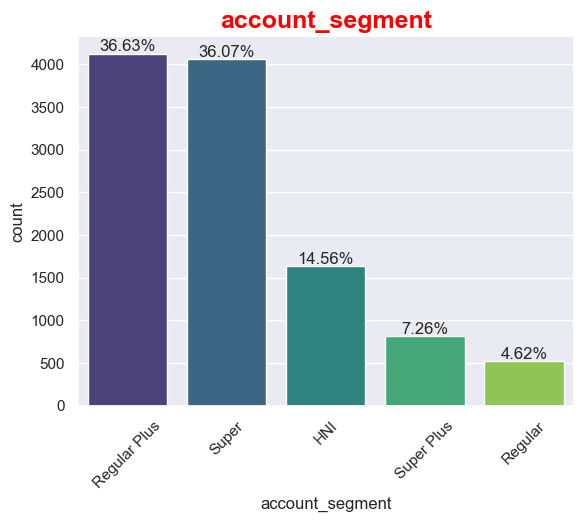

In [40]:
bar_graph(data_cleaned,'account_segment',perc=True,n=None)
plt.show()

- Regular Plus is the most preferred account segment, chosen by 36.63% of customers, closely followed by the Super segment at 36.07%.
- Together, they represent 72.7% of the customer base.
- The remaining customers fall into the HNI, Super Plus, and Regular segments.

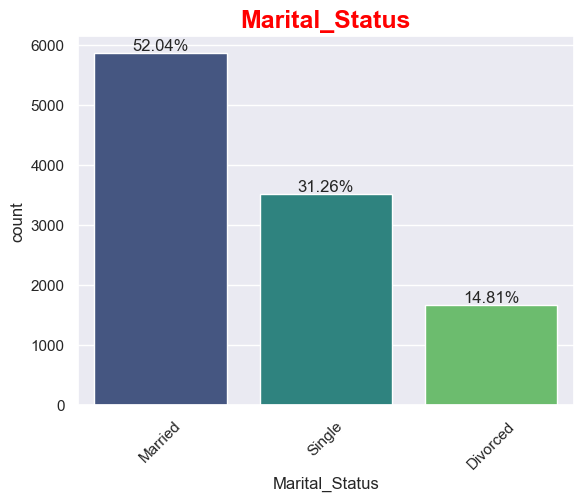

In [41]:
bar_graph(data_cleaned,'Marital_Status',perc=True,n=None)
plt.show()

- A majority of customers, 52.04%, are married. 
- Single individuals make up 31.26% of the base, while the remaining customers are divorced.

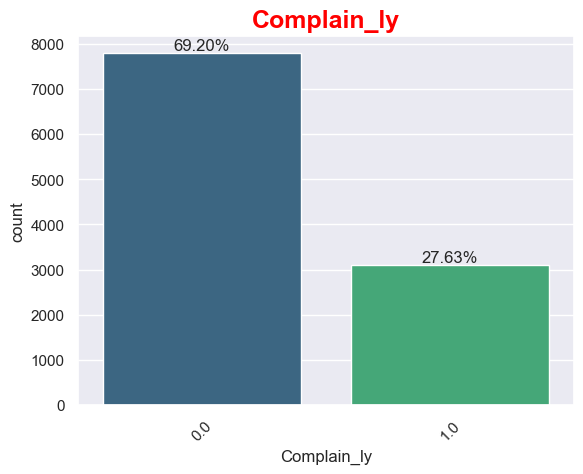

In [42]:
bar_graph(data_cleaned,'Complain_ly',perc=True,n=None)
plt.show()

- The majority of customers (69.20%) have not raised any complaints, while only 27.63% have lodged a complaint within the past 12 months.

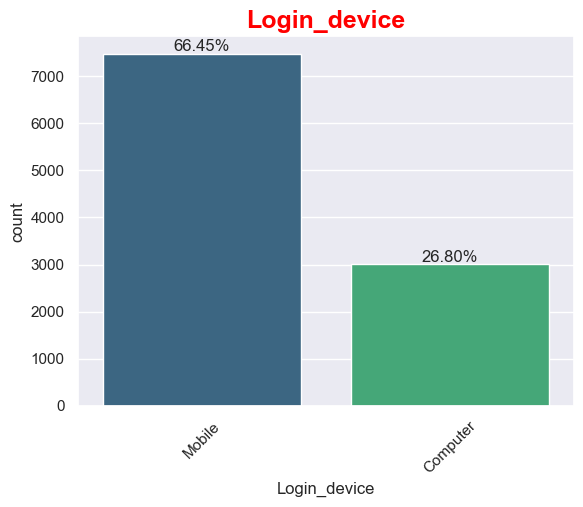

In [43]:
bar_graph(data_cleaned,'Login_device',perc=True,n=None)
plt.show()

- A majority of customers (66.45%) use mobile devices to log in, while the remaining users access their accounts via computer.

## Univariate Analysis for Numeric columns

In [44]:
#for univaruate numerica data distribution
def hist_box(data,feature,kde=True,figsize=(15,5)):

    f2,(ax_box,ax_hist) = plt.subplots(
        nrows=2,
        sharex=True,
        figsize=figsize,
        gridspec_kw=({'height_ratios':(0.25,0.75)})
    )

    sns.histplot(data=data,x=feature,kde=kde,ax=ax_hist)
    sns.boxplot(data=data,x=feature,ax=ax_box)

    ax_hist.axvline(
        data[feature].mean(),color='red',linestyle='--',label='Mean'
    )

    ax_hist.axvline(
        data[feature].median(),color='blue',linestyle='--',label='Median'
    )

    plt.legend()
    plt.suptitle('Distirbution of '+feature,color='red',fontweight='bold')
    plt.show()

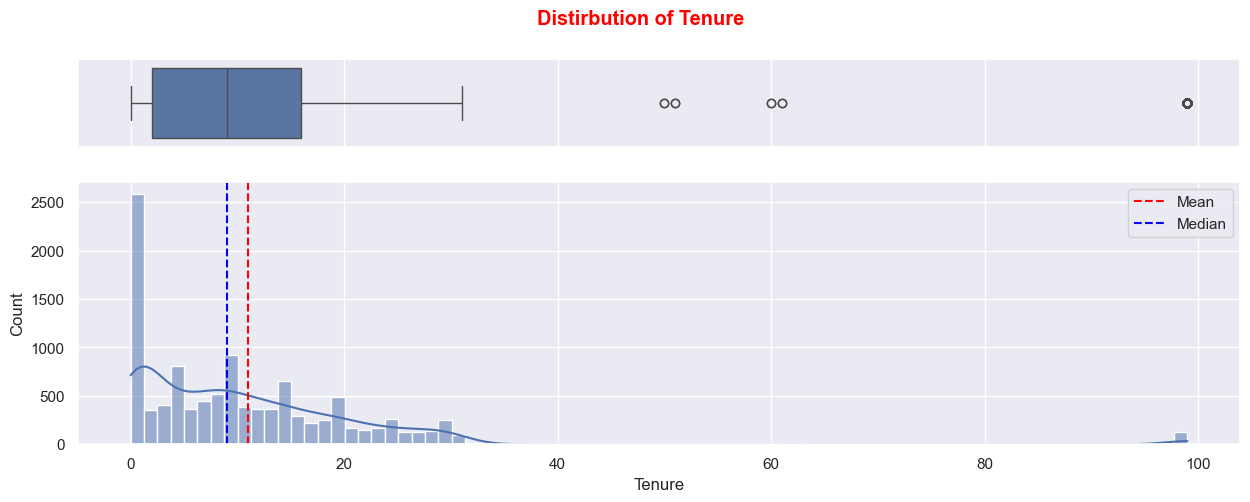

In [45]:
hist_box(data_cleaned,'Tenure',kde=True)
plt.show()

- Tenure after 40 months are outliers.
- Data is right skewed since mean is greater than median.

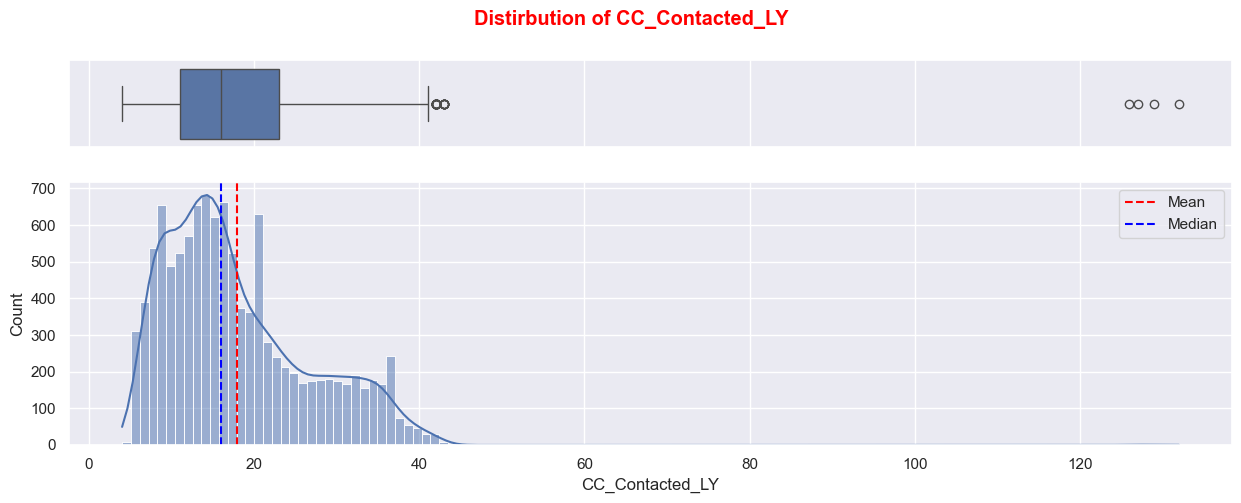

In [46]:
hist_box(data_cleaned,'CC_Contacted_LY',kde=True)
plt.show()

- Data is right skewed since mean is greater than median.

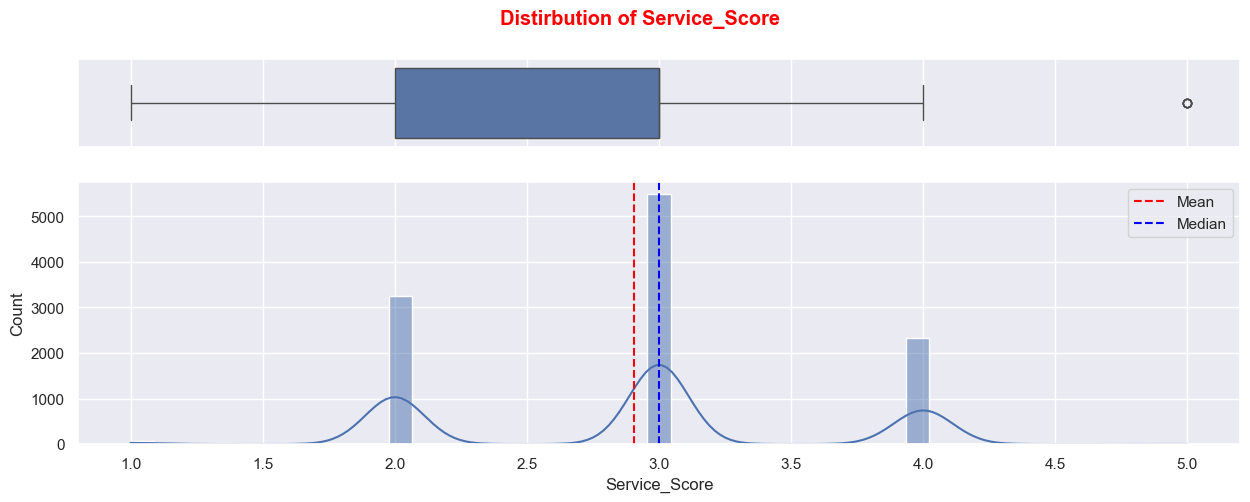

In [47]:
hist_box(data_cleaned,'Service_Score',kde=True)
plt.show()

- The majority of customers rated their service experience as 3, followed by ratings of 2 and 4. A rating of 5 appears to be an outlier, indicating very few customers selected the highest score.

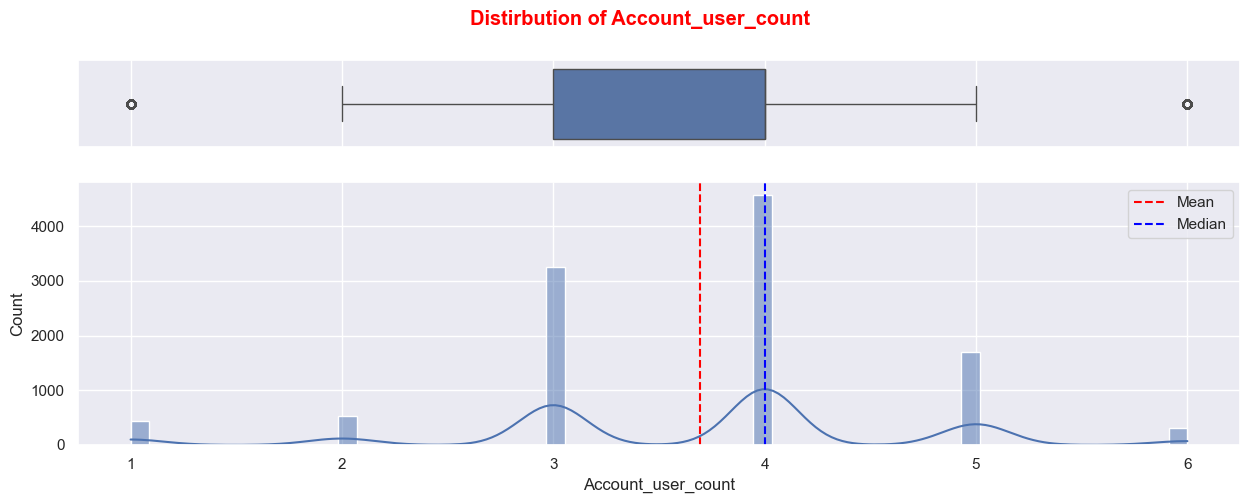

In [48]:
hist_box(data_cleaned,'Account_user_count',kde=True)
plt.show()

- Most accounts have 4 customers tagged, followed by those with 3 and 5 customers. Accounts with 1 or 6 customers are rare and considered outliers.

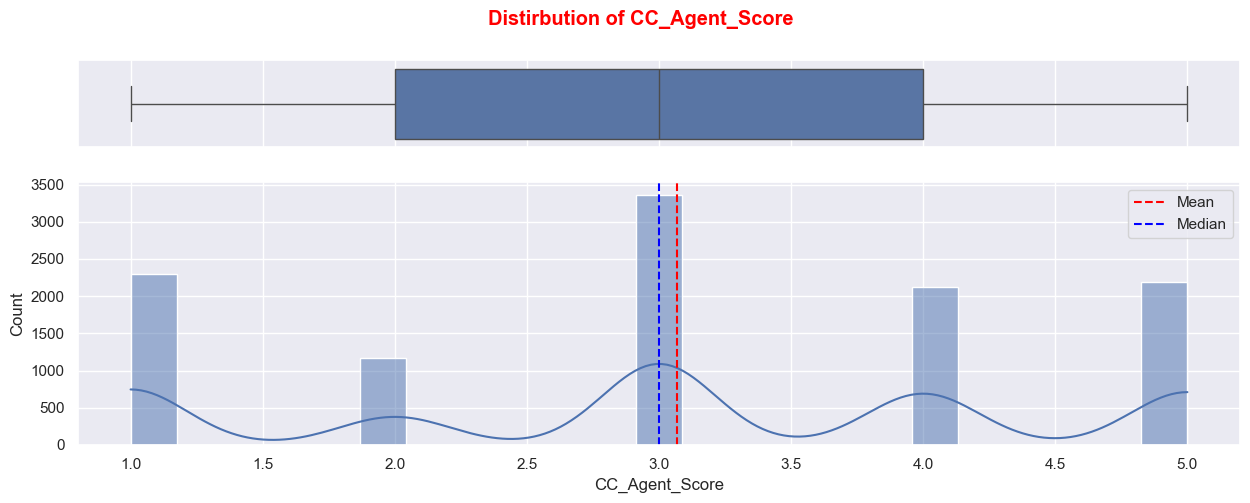

In [49]:
hist_box(data_cleaned,'CC_Agent_Score',kde=True)
plt.show()

- The data appears to be free of outliers.

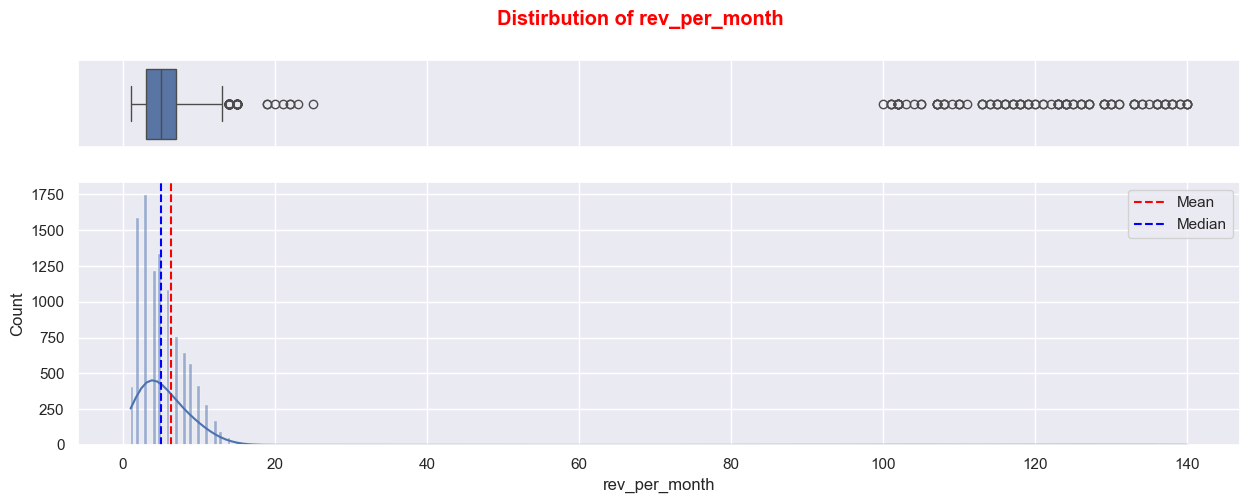

In [50]:
hist_box(data_cleaned,'rev_per_month',kde=True)
plt.show()

- The data contains numerous outliers. 
- Additionally, since the mean is greater than the median, the data distribution is right-skewed

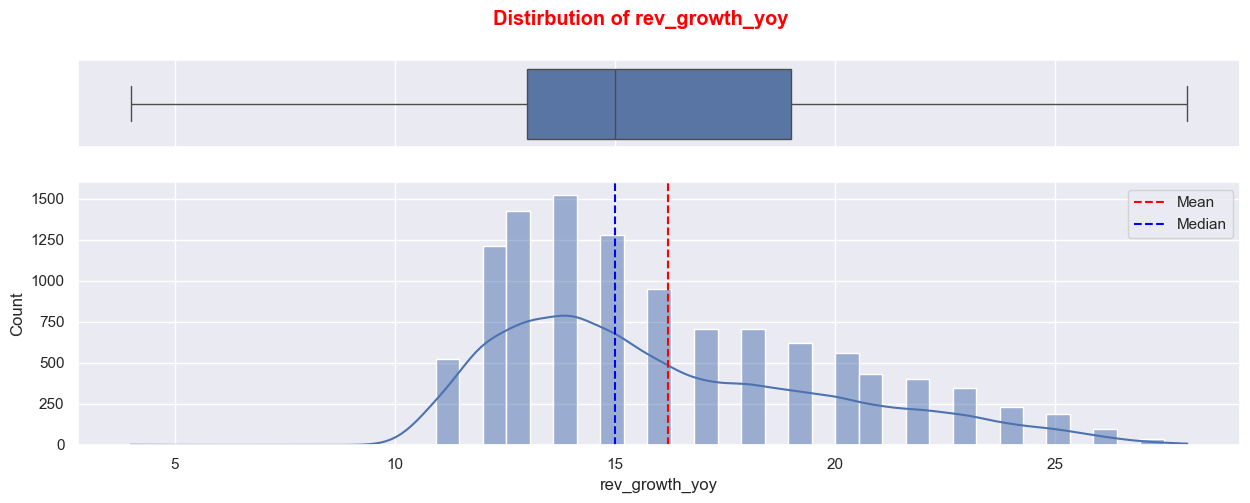

In [51]:
hist_box(data_cleaned,'rev_growth_yoy',kde=True)
plt.show()

- The data appears to be free of outliers.
- The mean is greater than the median, the data distribution is right-skewed.

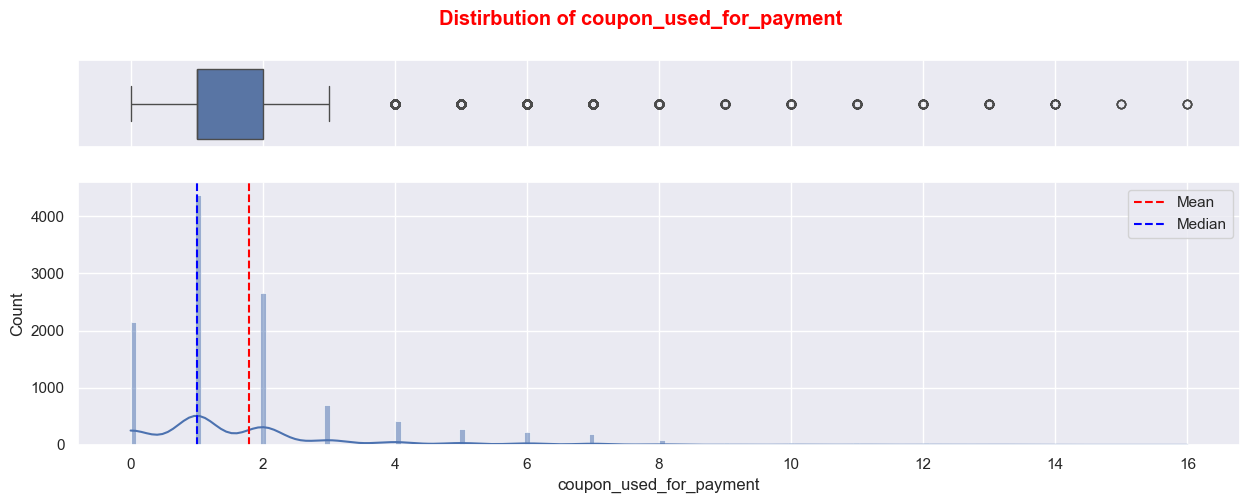

In [52]:
hist_box(data_cleaned,'coupon_used_for_payment',kde=True)
plt.show()

- This data has few outliers.
- Since the mean exceeds the median, the data distribution is right-skewed.

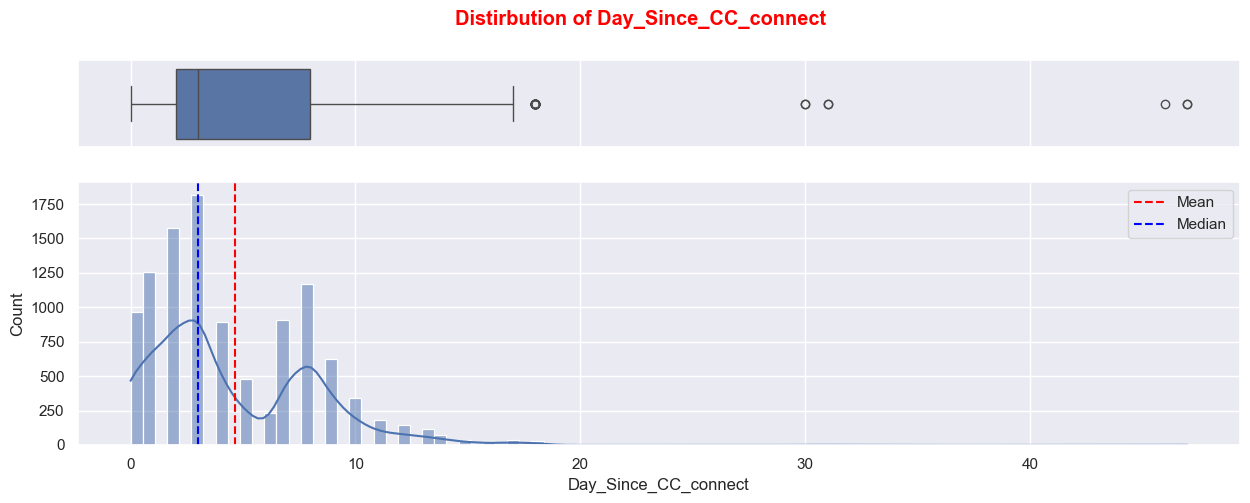

In [53]:
hist_box(data_cleaned,'Day_Since_CC_connect',kde=True)
plt.show()

- This data has few outliers.
- Since the mean exceeds the median, the data distribution is right-skewed.

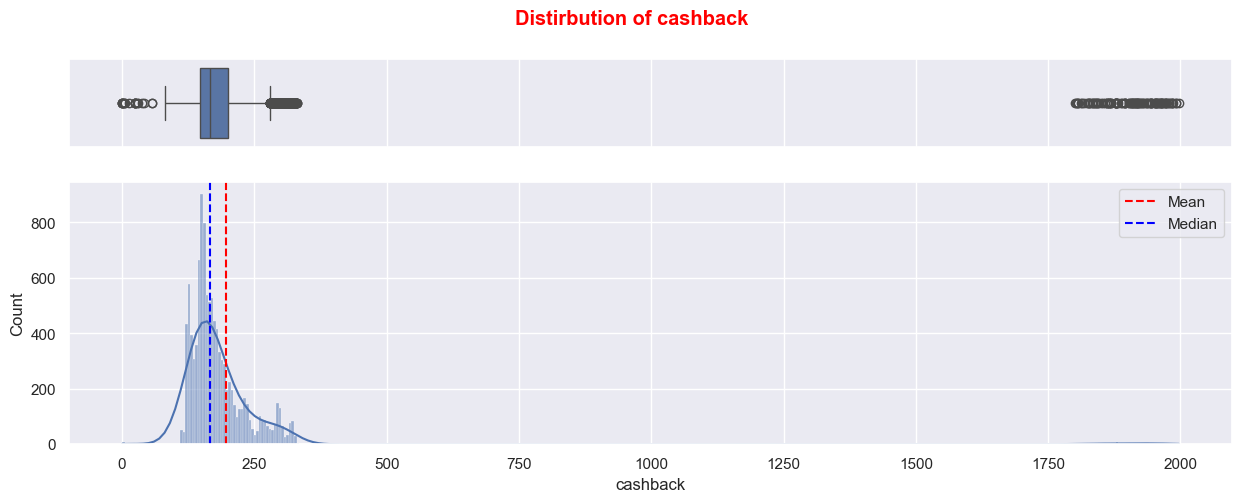

In [54]:
hist_box(data_cleaned,'cashback',kde=True)
plt.show()

- This data has many outliers.
- Since the mean exceeds the median, the data distribution is right-skewed.

# Bivariate Analysis

## Pairplot

In [55]:
#sns.pairplot(data_cleaned,hue='Churn')
#plt.show()

### Observation

- The numeric features exhibit weak linear relationships, and there is no clear separation between churned and non-churned customers.
- The distribution of cashback amounts is either below ₹500 or above ₹1800, and no observations in between.
- Similarly, revenue per month shows a split pattern—most values are either below ₹50 or above ₹100, indicating a gap in mid-range values.

## Heatmap

In [56]:
# Changing Churn column to int to know its relstionship with other numeric columns.
data_cleaned['Churn']=data_cleaned['Churn'].astype('int')

In [57]:
numeric_columns=data_cleaned.select_dtypes(include=np.number).columns

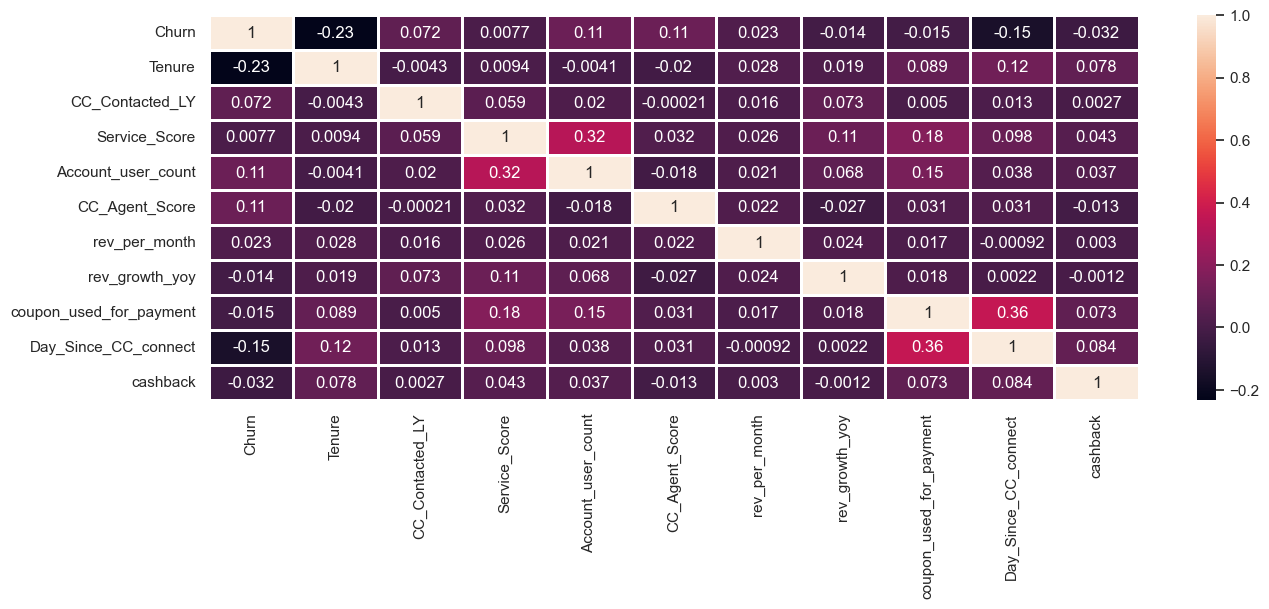

In [58]:
plt.figure(figsize=(15,5))
sns.heatmap(data=data_cleaned[numeric_columns].corr(),annot=True,fmt='.2g',linewidths=1)
plt.show()

### Observation

As observed in the pair plot, and further confirmed by the heatmap, there is no strong linear correlation between the independent and dependent variables, nor among the independent variables themselves.

## Bar plot

In [59]:
#stacked columns 
def stack(data,feature1,feature2):
    pivot_df=data.groupby([feature1,feature2]).size().reset_index(name='Count').pivot_table(index=feature1,columns=feature2,values='Count',aggfunc='sum')
    pivot_df=pivot_df[[0,1]]
    row_totals = pivot_df.sum(axis=1)
    percentage_df = pivot_df.div(row_totals, axis=0) * 100
    #print(percentage_df.T)
    ax=pivot_df.plot(kind='bar',stacked=True,figsize=(15,4),color=['#72bf6a', '#f94449'],);
    plt.title(feature1+' and '+feature2,color='red',fontweight='bold')
    plt.xticks(rotation=0)
    for i, (index, row) in enumerate(pivot_df.iterrows()):
        total = row.sum()
        bottom = 0
        for j, value in enumerate(row):
            percent = (value / total) * 100
            ax.text(
                i,                      # x-position
                bottom + value / 2,     # y-position (middle of the bar section)
                f"{percent:.1f}%",      # label
                ha='center', va='center', fontsize=9, color='black', fontweight='bold'
            )
            bottom += value

    plt.show()

In [60]:
# Changing Churn column to Object to know its relstionship with other categorical columns.
data_cleaned['Churn']=data_cleaned['Churn'].astype('object')

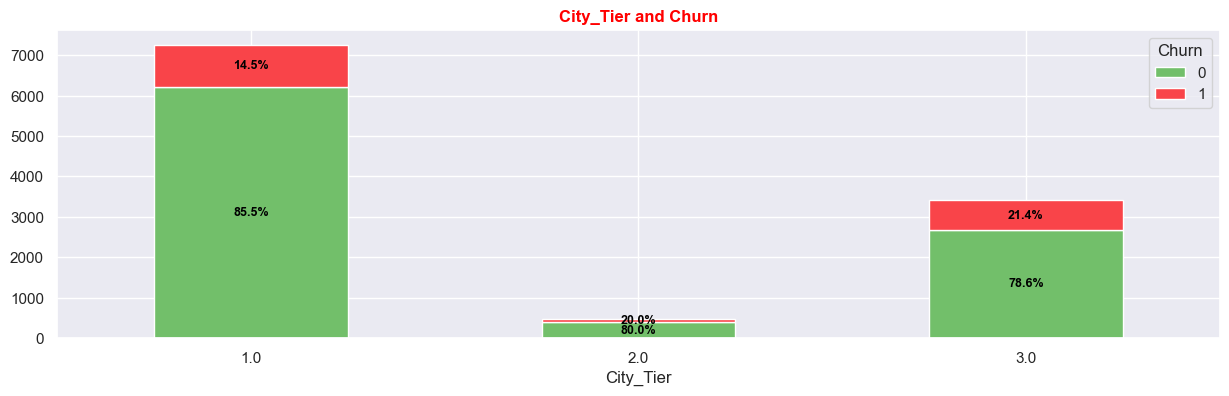

In [61]:
stack(data_cleaned,'City_Tier','Churn')

### observation:

- Customer churn is highest in Tier 3 cities at 21.4%, followed by Tier 2 cities at 20%. Tier 1 cities have the lowest churn rate among the three, at 14.5%.

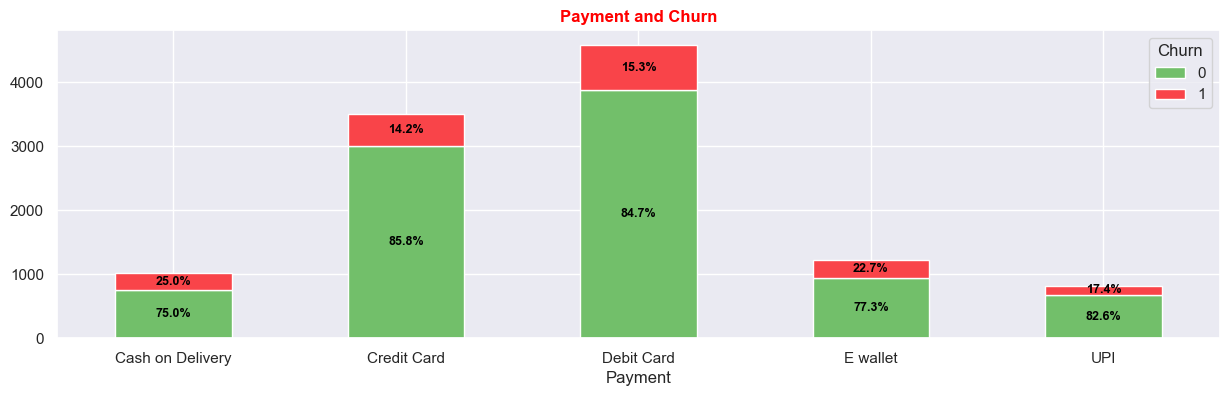

In [62]:
stack(data_cleaned,'Payment','Churn')

### Observation:

- Customers opting for Cash on Delivery exhibit the highest churn rate at 25%, followed by those using E-wallets at 22.7% and UPI at 17.4%. In contrast, churn rates among Credit Card and Debit Card users are comparatively lower.

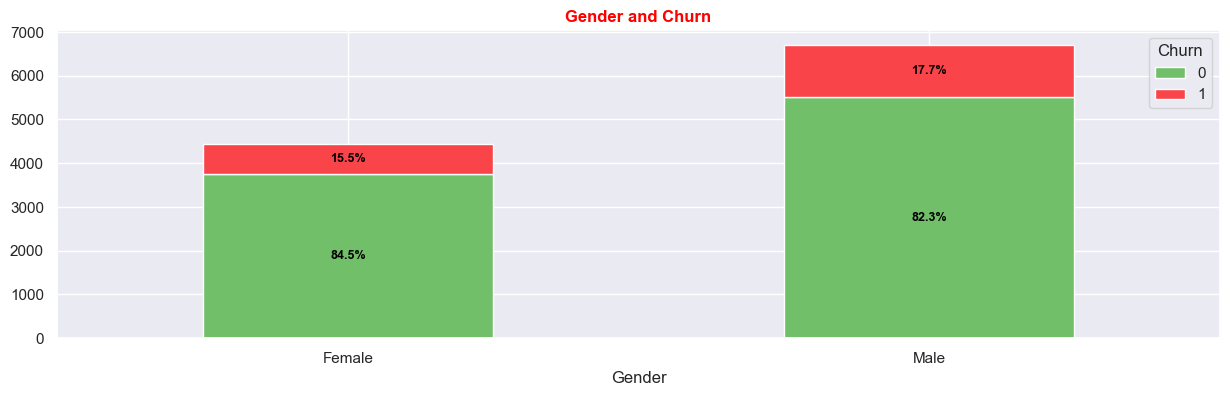

In [63]:
stack(data_cleaned,'Gender','Churn')

### Observation

Churn rates among male customers stand at 17.7%, while female customers show a slightly lower rate of 15.5%, indicating minimal variation in behavior across genders

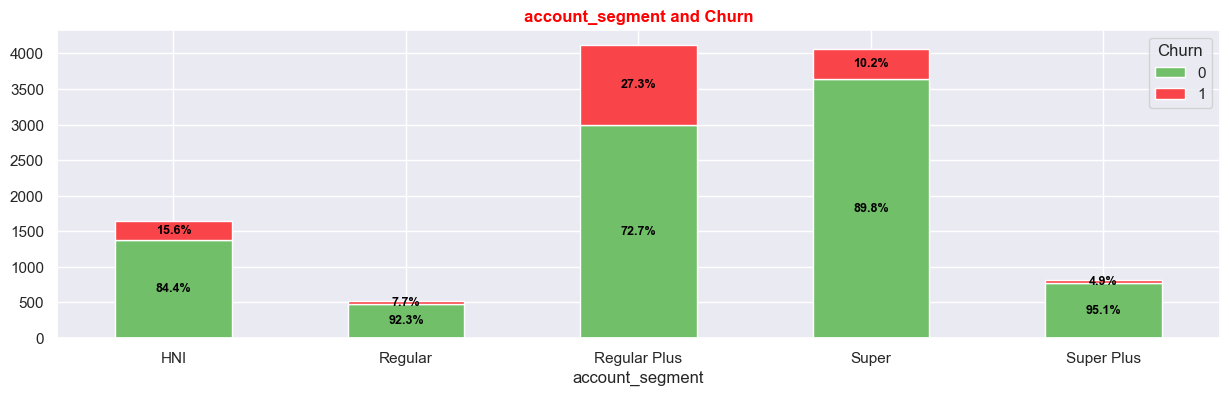

In [64]:
stack(data_cleaned,'account_segment','Churn')

### Observation
Despite being the most preferred, the RegularPlus segment experiences the highest customer churn rate at 27.3%. It’s followed by the HNI and Super segments. In contrast, the Regular and Super Plus segments exhibit significantly lower churn rates.

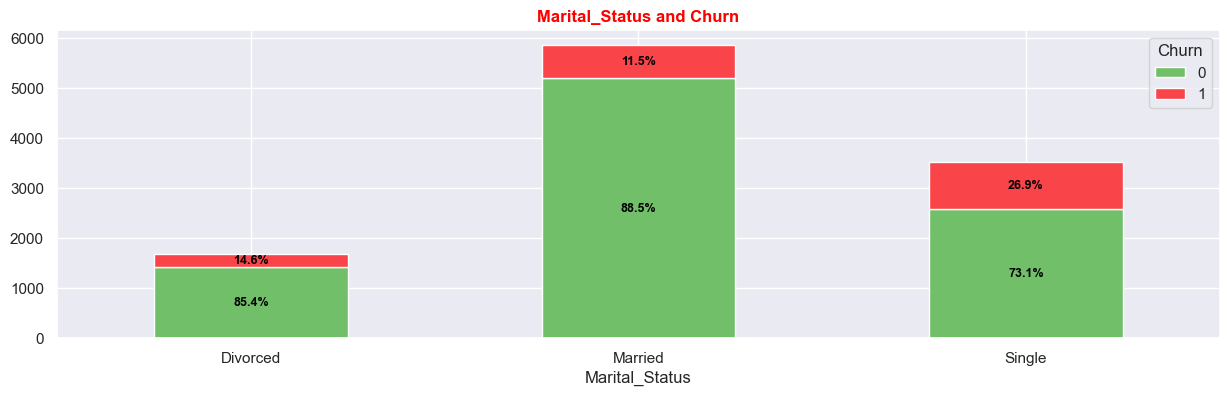

In [65]:
stack(data_cleaned,'Marital_Status','Churn')

### Observation:

- Single customers exhibit the highest churn rate at 26.9%, followed by divorced customers at 14.6%. Despite accounting for 53% of the overall customer base, married customers show a notably lower churn rate of just 11.5%.

- This pattern suggests that marital status may be an influencing factor in customer retention.

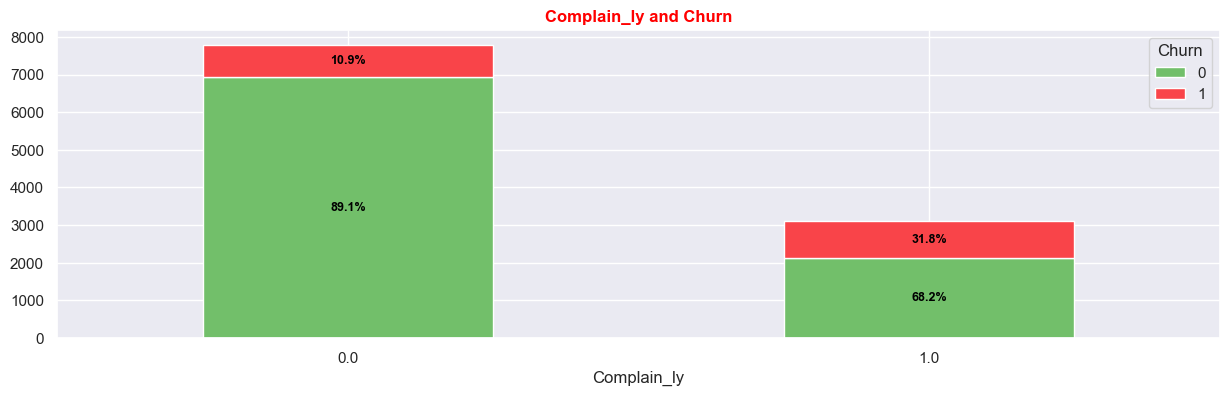

In [66]:
stack(data_cleaned,'Complain_ly','Churn')

### Observations

Customers who have filed complaints within the past 12 months show the highest churn rate at 31.8%, indicating a strong correlation between dissatisfaction and customer attrition.

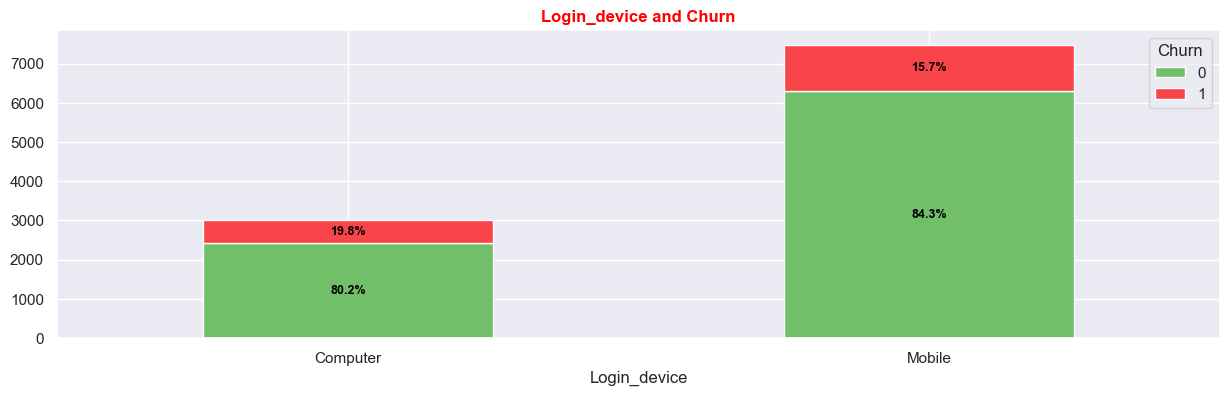

In [67]:
stack(data_cleaned,'Login_device','Churn')

### Observations

Customers accessing the platform via computers exhibit the highest churn rate at 19.8%, compared to a lower rate of 15.7% among mobile users.

## Chi-Square test

In [68]:
# chi-square tests to determine statistical significance in the association between two categorical variables).
def chisq(data,feature1,feature2):    
    crosstab = pd.crosstab(
        data[feature1], data[feature2]
    )  # Contingency table of FICO and age attributes
    
    Ho = "{} score has no effect on {}".format(feature1,feature2)
    Ha = "{} score has an effect on {}".format(feature1,feature2)
    
    chi, p_value, dof, expected = stats.chi2_contingency(crosstab)
    
    if p_value < 0.05:  # Setting our significance level at 5%
        print(f"{Ha} as the p_value ({p_value.round(3)}) < 0.05")
    else:
        print(f"{Ho} as the p_value ({p_value.round(3)}) > 0.05")

In [69]:
for i in object_columns:
    chisq(data_cleaned,i,'Churn')

Churn score has an effect on Churn as the p_value (0.0) < 0.05
City_Tier score has an effect on Churn as the p_value (0.0) < 0.05
Payment score has an effect on Churn as the p_value (0.0) < 0.05
Gender score has an effect on Churn as the p_value (0.003) < 0.05
account_segment score has an effect on Churn as the p_value (0.0) < 0.05
Marital_Status score has an effect on Churn as the p_value (0.0) < 0.05
Complain_ly score has an effect on Churn as the p_value (0.0) < 0.05
Login_device score has an effect on Churn as the p_value (0.0) < 0.05


### Observation:

All categorical (object-type) features in the dataset exhibit a statistically significant relationship with the target variable 'Churn,' as evidenced by their p-values falling below the 0.05 significance threshold.

## Numeric Columns vs Target Coumns

In [70]:
numeric_columns=data_cleaned.select_dtypes(include=np.number).columns

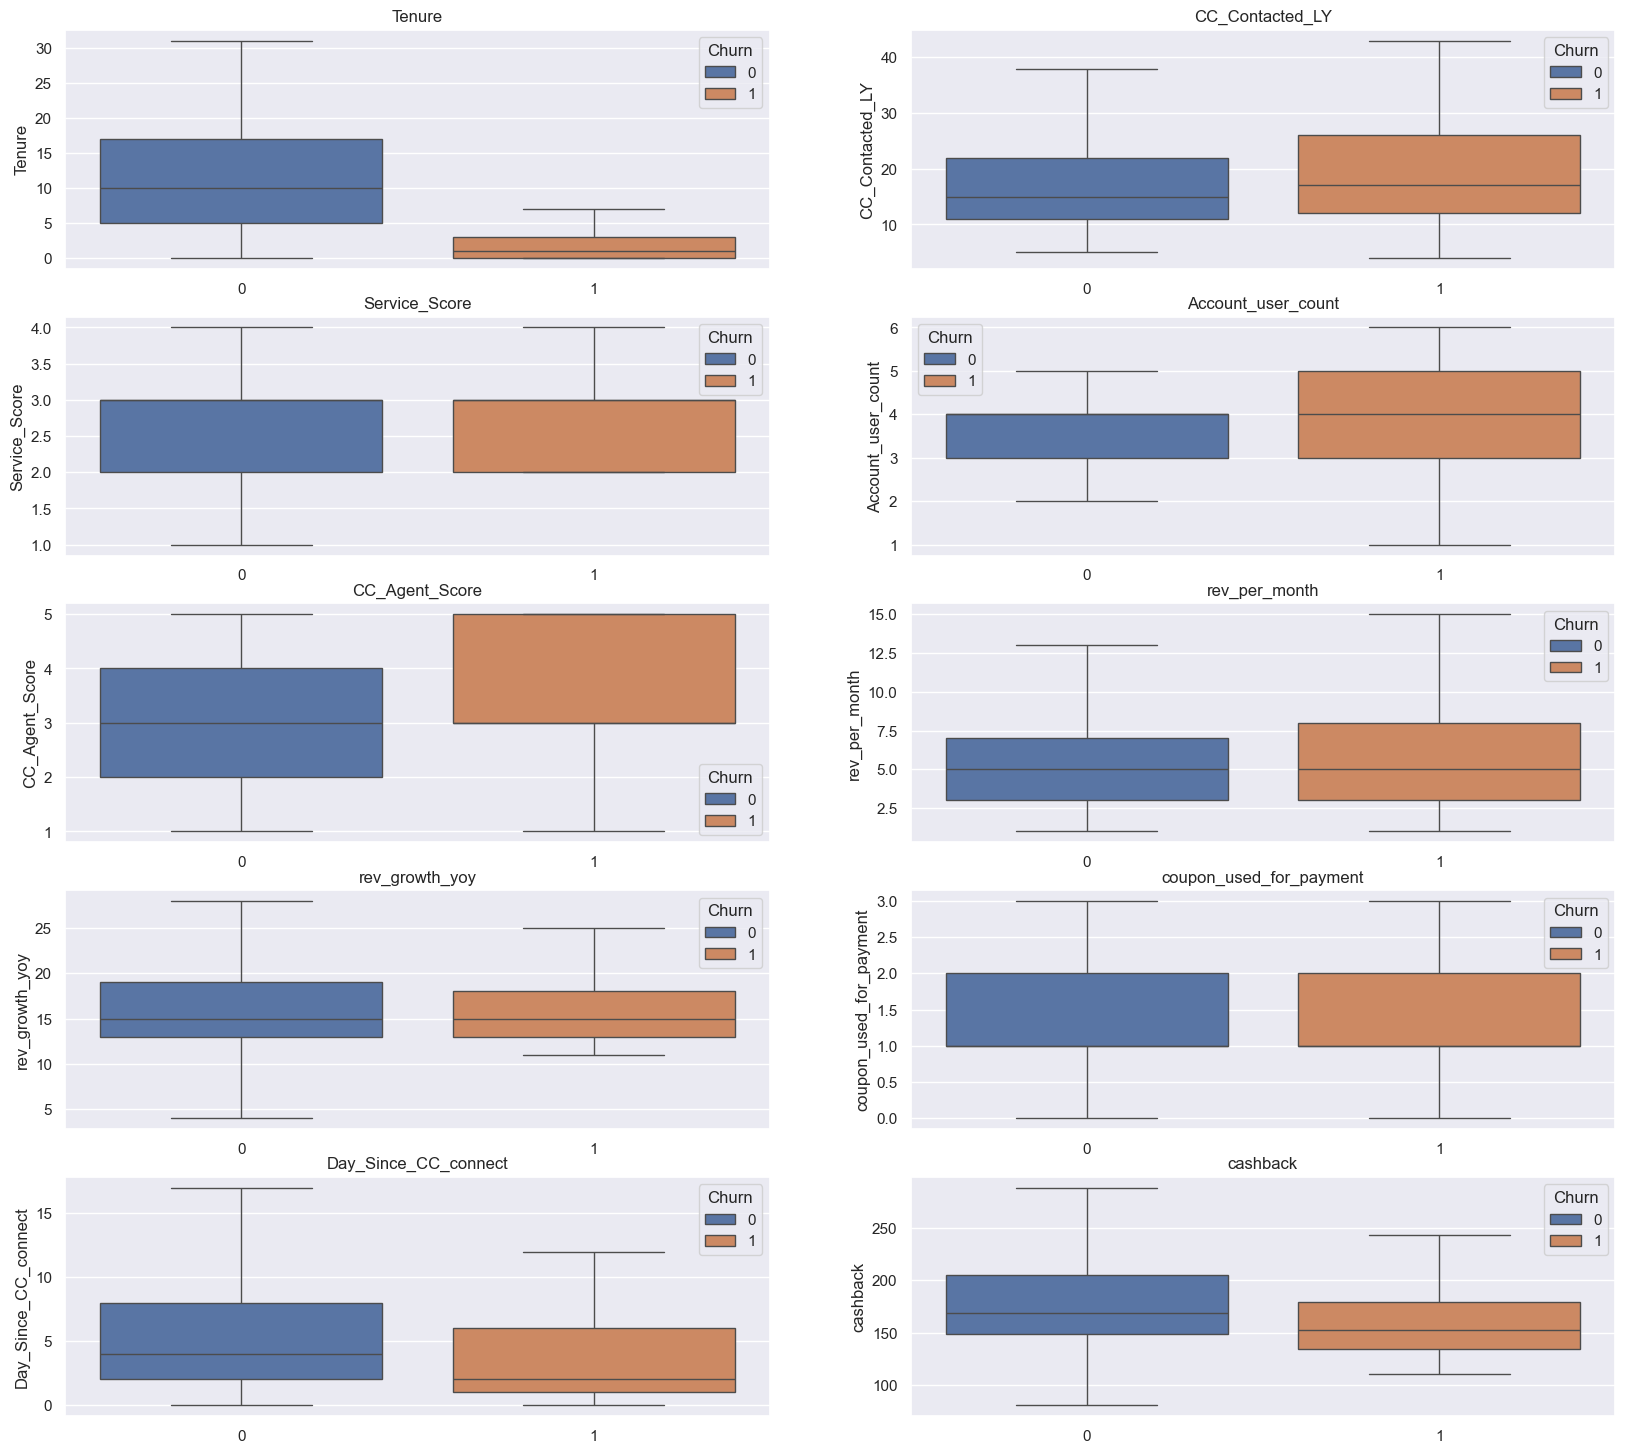

In [71]:
plt.figure(figsize=(20,18))
for i, name in enumerate(numeric_columns):
    plt.subplot(5,2,i+1)
    sns.boxplot(data=data_cleaned,x='Churn',y=name,hue='Churn',showfliers=False)
    plt.xlabel("")
    plt.title(name)
plt.show()

### Observation

- Customers with a tenure of 5 months or less are more likely to churn. 
- The 75th percentile of customer care interactions last year is noticeably higher among churned customers than those who retained their accounts.
- Accounts with either fewer than 2 users or more than 4 are also more prone to churn.
- Additionally, the average number of days since the last customer care interaction is higher for non-churning customers, indicating that frequent engagement with customer care is associated with higher churn risk. 
- Lastly, churned customers tend to receive less cashback compared to those who remain.

# Multi Variate Analysis

## Gender,Marital_status and Churn behaviour Analysis

In [72]:
gender_marriage_churn=data_cleaned.groupby(['Gender','Marital_Status'])['Churn'].value_counts().reset_index(name='Count').pivot_table(columns='Churn',
                                                                                                               index=['Marital_Status','Gender'],
                                                                                                               values='Count')

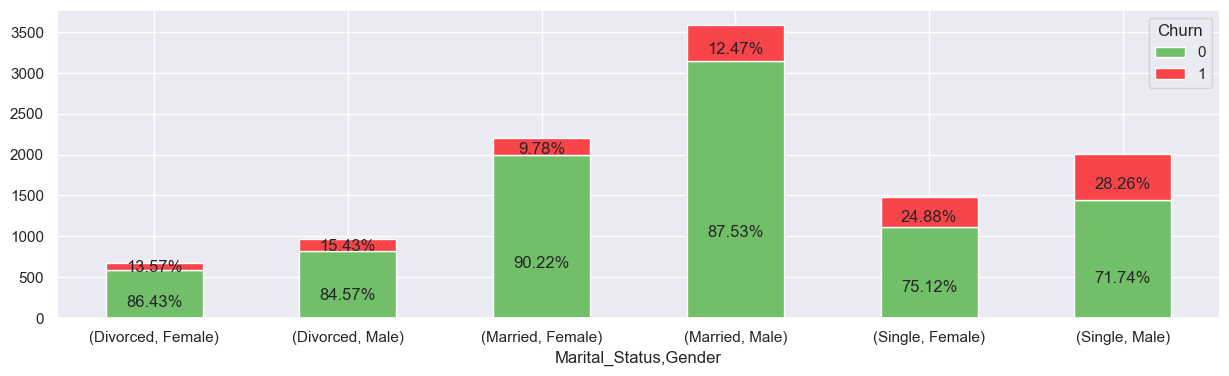

In [73]:
ax=gender_marriage_churn.plot(kind='bar',stacked=True,figsize=(15,4),color=['#72bf6a', '#f94449'])
for i ,(index,row) in enumerate(gender_marriage_churn.iterrows()):
    total=row.sum()
    bottom=0

    for j,value in enumerate(row):
        perc=(value/total)*100
        ax.text(
            i,
            bottom+value/3,
            f'{perc:.2f}%',
            ha='center',va='center'
        )
        bottom+=value
plt.xticks(rotation=0)
plt.show()

### Observation

While churn rates across genders are relatively similar, marital status reveals a notable trend—single customers churn at the highest rate. When examining both gender and marital status together, male customers show the highest churn rates within each marital category, although the differences remain minimal

## Gender,City_tier and Churn behaviour Analysis

In [74]:
city_gender_churn=data_cleaned.groupby(['City_Tier','Gender'])['Churn'].value_counts().reset_index(name='Count').pivot_table(columns='Churn',
                                                                                                               index=['City_Tier','Gender'],
                                                                                                               values='Count')

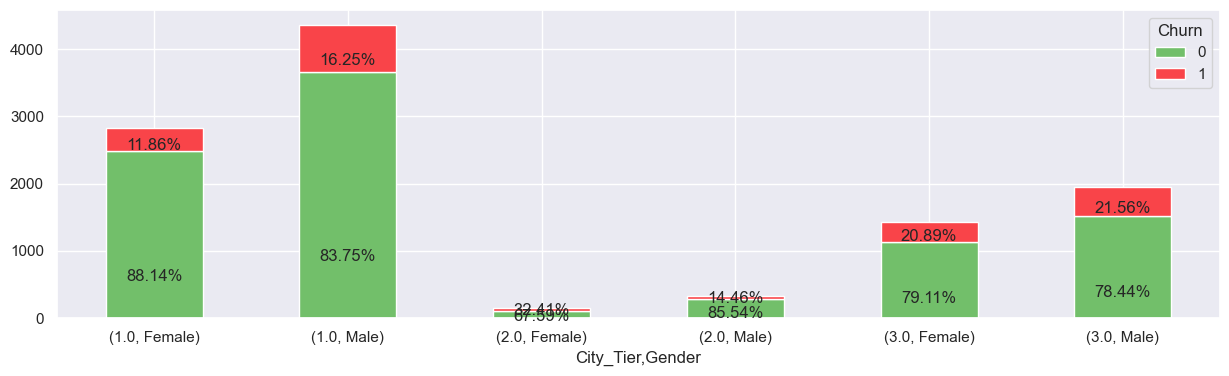

In [75]:
ax=city_gender_churn.plot(kind='bar',stacked=True,figsize=(15,4),color=['#72bf6a', '#f94449'])
for i ,(index,row) in enumerate(city_gender_churn.iterrows()):
    total=row.sum()
    bottom=0

    for j,value in enumerate(row):
        perc=(value/total)*100
        ax.text(
            i,
            bottom+value/4,
            f'{perc:.2f}%',
            ha='center',va='center'
        )
        bottom+=value
plt.xticks(rotation=0)
plt.show()

### Observation

Male customers exhibit the highest churn rates in City Tier 1 and Tier 3, whereas female customers show the greatest churn tendency in City Tier 2

## Payment,City_tier and cashback behaviour Analysis

In [76]:
Payment_City_Tier_cashback=data_cleaned.groupby(['City_Tier','Payment'])['cashback'].count().reset_index(name='count').pivot_table(columns='City_Tier',
                                                                                                               index=['Payment'],
                                                                                                               values='count')

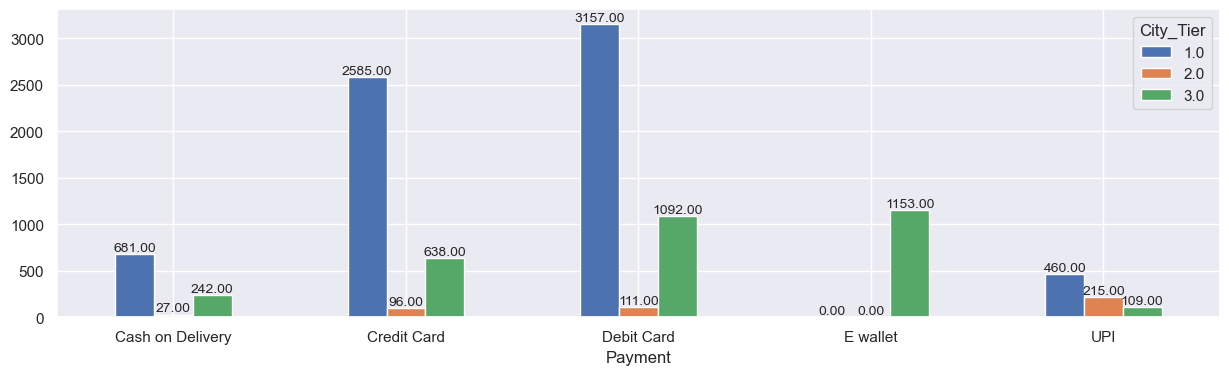

In [77]:
ax=Payment_City_Tier_cashback.plot(kind='bar',figsize=(15,4))
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # X position (center of bar)
        height,                             # Y position (top of bar)
        f'{height:.2f}',                    # Text to display
        ha='center', va='bottom', fontsize=10
    )
plt.xticks(rotation=0)
plt.show()

### Observation:

- In City Tier 1, customers who preferred Debit Cards received cashback frequently, whereas those opting for E-Wallets received none. 
- In City Tier 2, frequent cashback was observed among UPI users, with E-Wallet users again receiving none. 
- Interestingly, in City Tier 3, the pattern shifts—E-Wallet users received the most cashback, followed by those using Debit Cards.

Null values in the Cashback column will be addressed using this multi-dimensional grouping approach

## account_segment , Login_device and coupon_used_for_payment behaviour Analysis

In [78]:
account_segment_Login_device=np.round(data_cleaned.groupby(['account_segment','Login_device'])['coupon_used_for_payment'].mean()).reset_index(name='count').pivot_table(columns='Login_device',
                                                                                                               index=['account_segment'],
                                                                                                               values='count')

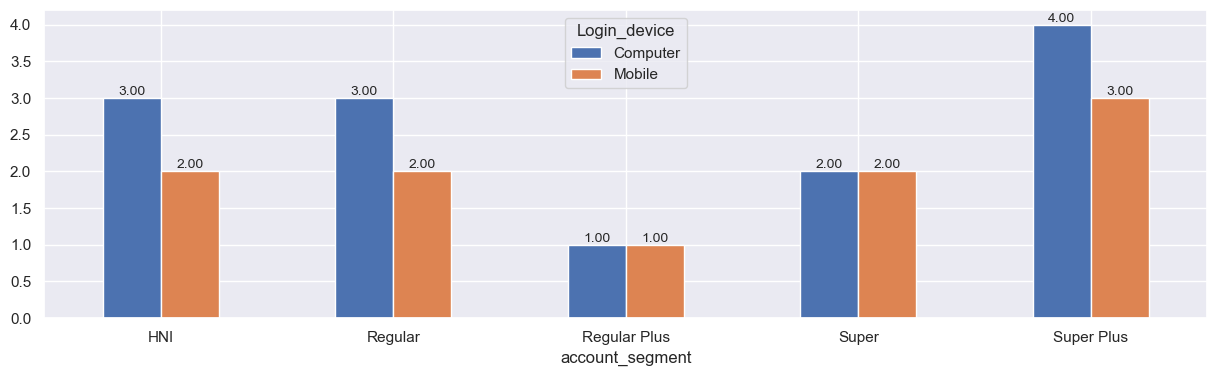

In [79]:
ax=account_segment_Login_device.plot(kind='bar',figsize=(15,4))
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # X position (center of bar)
        height,                             # Y position (top of bar)
        f'{height:.2f}',                    # Text to display
        ha='center', va='bottom', fontsize=10
    )
plt.xticks(rotation=0)
plt.show()

### Observation

- In the HNI, Regular, and Super Plus account segments, coupon usage for payments is notably higher among customers accessing via computers compared to those using mobile devices. 
- For the Regular and Super segments, coupon usage remains consistent across both computer and mobile platforms

Null values in the coupon_used_for_payment column will be addressed using this multi-dimensional grouping approach

## account_segment,City_Tier,Gender and Tenure behaviour Analysis

In [80]:
account_segment_Gender_Tenure=np.round(data_cleaned.groupby(['account_segment','Gender'])['Tenure'].median()).reset_index(name='count').pivot_table(columns='Gender',
                                                                                                               index=['account_segment'],
                                                                                                               values='count')

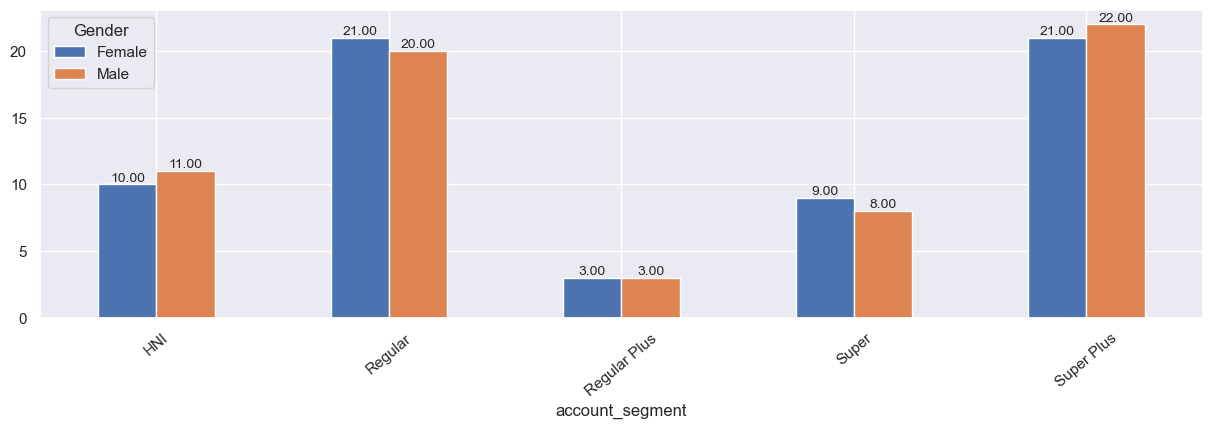

In [81]:
ax=account_segment_Gender_Tenure.plot(kind='bar',figsize=(15,4))
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # X position (center of bar)
        height,                             # Y position (top of bar)
        f'{height:.2f}',                    # Text to display
        ha='center', va='bottom', fontsize=10
    )
plt.xticks(rotation=40)
plt.show()

In [82]:
account_segment_City_Tier_Gender_Tenure=np.round(data_cleaned.groupby(['account_segment','City_Tier','Gender'])['Tenure'].median()).reset_index(name='count').pivot_table(columns='Gender',
                                                                                                               index=['account_segment','City_Tier'],
                                                                                                               values='count')

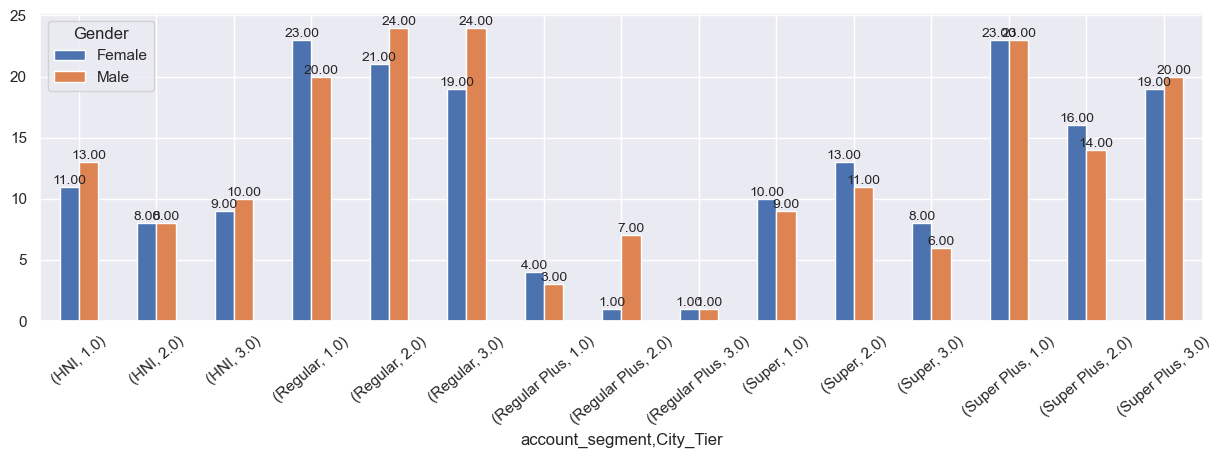

In [83]:
ax=account_segment_City_Tier_Gender_Tenure.plot(kind='bar',figsize=(15,4))
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # X position (center of bar)
        height,                             # Y position (top of bar)
        f'{height:.2f}',                    # Text to display
        ha='center', va='bottom', fontsize=10
    )
plt.xticks(rotation=40)
plt.show()

### Observation

- Overall, male and female customers exhibit similar tenure durations.
- When combining Gender with Account Segment, customers in the Regular and Super Plus segments tend to have longer tenure, followed by those in HNI and Super segments.
- Notably, although 36.63% of customers chose the Regular Plus segment, their average tenure is significantly lower than other segments.
- Including City_Tier in the analysis reveals that Regular segment customers demonstrate the highest tenure across all three tiers, followed by Super Plus.
- Interestingly, despite Regular Plus customers having the lowest overall tenure, male customers in City Tier 2 within this segment show comparatively better tenure.

Null values in the Tenure column will be addressed using this multi-dimensional grouping approach

## account_segment,City_Tier and Day_Since_CC_connect behaviour Analysis

In [84]:
account_segment_City_Tier_Day_Since_CC_connect=np.round(data_cleaned.groupby(['account_segment','City_Tier'])['Day_Since_CC_connect'].median()).reset_index(name='count').pivot_table(columns='City_Tier',
                                                                                                               index=['account_segment'],
                                                                                                               values='count')

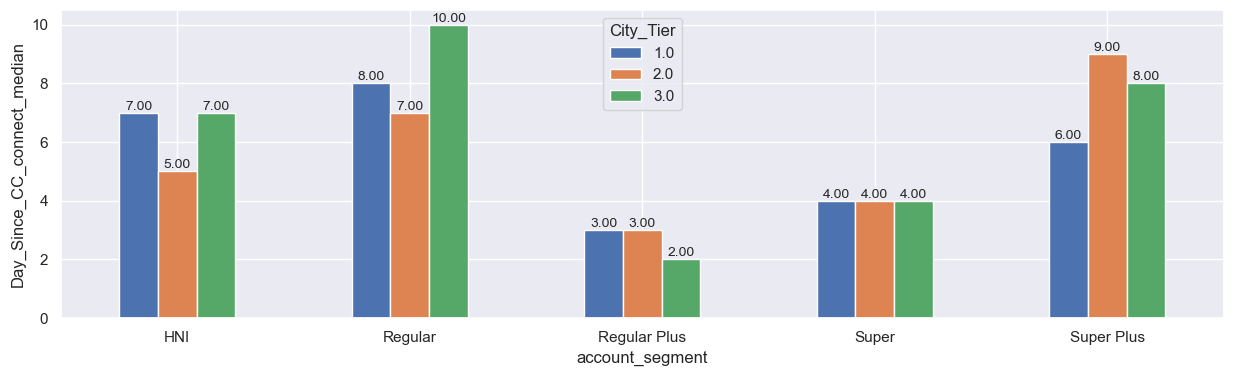

In [85]:
ax=account_segment_City_Tier_Day_Since_CC_connect.plot(kind='bar',figsize=(15,4))
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # X position (center of bar)
        height,                             # Y position (top of bar)
        f'{height:.2f}',                    # Text to display
        ha='center', va='bottom', fontsize=10
    )
plt.xticks(rotation=00)
plt.ylabel('Day_Since_CC_connect_median')
plt.show()

### Observation

The Regular Plus segment has the most customers, but their average tenure is low. Most of them contacted customer care just 2 or 3 days ago, which suggests frequent issues.This might also be the reason for less Tenure.

Although only 4.62% of customers belong to the Regular segment, they tend to have a longer tenure compared to other segments. Their engagement with customer care is also relatively better.

Null values in the Day_Since_CC_connect column will be addressed using this multi-dimensional grouping approach

# Data Preprocessing

In [86]:
df=data_cleaned.copy()

In [87]:
df['Churn']=df['Churn'].astype(int)

In [88]:
numeric_columns=df.select_dtypes(include=np.number).columns
object_columns=df.select_dtypes(exclude=np.number).columns

In [89]:
df.head()

,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
0,1,4.00,3.00,6.00,Debit Card,Female,3.00,3.00,Super,2.00,Single,9.00,1.00,11.00,1.00,5.00,159.93,Mobile
1,1,0.00,1.00,8.00,UPI,Male,3.00,4.00,Regular Plus,3.00,Single,7.00,1.00,15.00,0.00,0.00,120.90,Mobile
2,1,0.00,1.00,30.00,Debit Card,Male,2.00,4.00,Regular Plus,3.00,Single,6.00,1.00,14.00,0.00,3.00,NaN,Mobile
3,1,0.00,3.00,15.00,Debit Card,Male,2.00,4.00,Super,5.00,Single,8.00,0.00,23.00,0.00,3.00,134.07,Mobile
4,1,0.00,1.00,12.00,Credit Card,Male,2.00,3.00,Regular Plus,5.00,Single,3.00,0.00,11.00,1.00,3.00,129.60,Mobile


## Outlier Detection

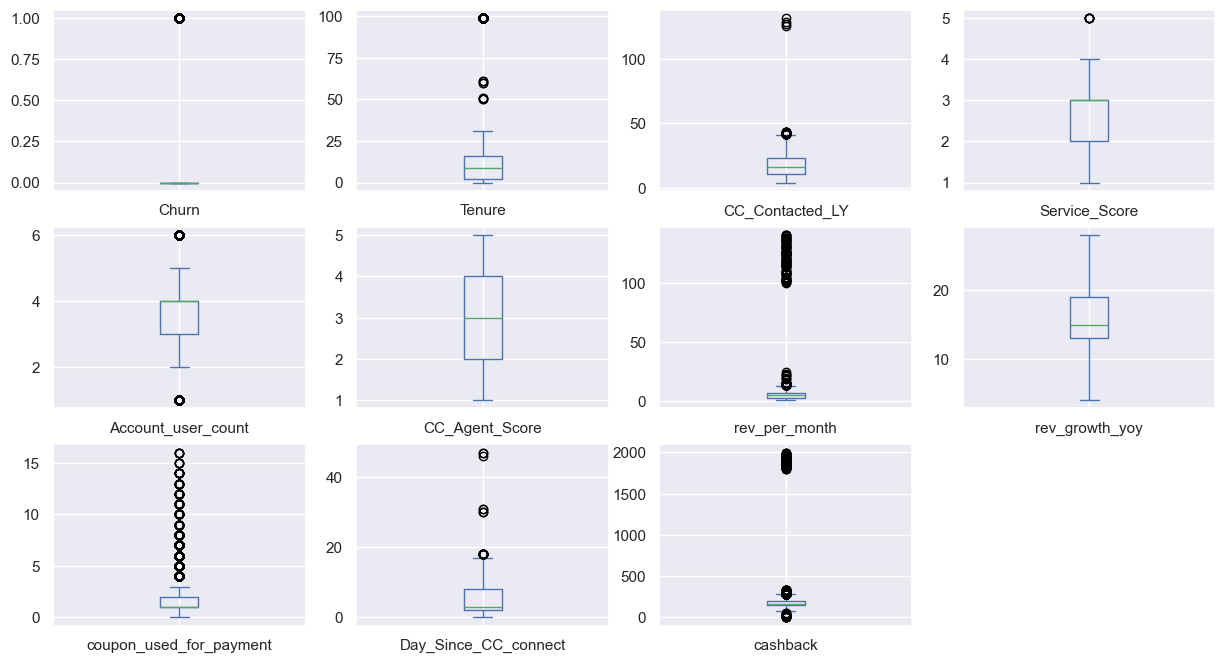

In [90]:
for i,value in enumerate(df[numeric_columns][1:].columns):
    plt.subplot(3,4,i+1)
    df[value].plot(kind='box',figsize=(15,8))
plt.show()

In [91]:
def outliers(x):
    lower,upper=x.quantile(q=[0.25,0.75])
    iqr=upper-lower
    low_whisker=lower - (1.5 * iqr)
    top_whisker=upper + (1.5 * iqr)
    return low_whisker,top_whisker

In [92]:
to_treat=['Tenure','CC_Contacted_LY','rev_per_month','coupon_used_for_payment','rev_growth_yoy','Day_Since_CC_connect','cashback']

In [93]:
outlier_counts = {}
for i in df[to_treat].columns:
    lower_whisker,upper_whisker=outliers(df[i])
    count = ((df[i] < lower_whisker) | (df[i] > upper_whisker)).sum()
    outlier_counts[i] = (count/df.shape[0])*100

In [94]:
outlier_info = pd.DataFrame({'Features':list(outlier_counts.keys()),
                            'Outler_percentage':list(outlier_counts.values())})

In [95]:
outlier_info.sort_values(by='Outler_percentage',ascending=False).reset_index(drop=True)

,Features,Outler_percentage
0,coupon_used_for_payment,12.26
1,cashback,7.81
2,rev_per_month,1.64
3,Tenure,1.23
4,CC_Contacted_LY,0.37
5,Day_Since_CC_connect,0.29
6,rev_growth_yoy,0.00


### Observation:

As the outliers appear to be genuine data points, we’ve chosen not to remove them. However, we may apply a log transformation later to reduce their influence on scale and distribution.

In [96]:
#np.log1p(df['Tenure']) to be used

## Feature Engineering

### Changing values in City Tier column

In [97]:
df['City_Tier']=df['City_Tier'].map({1:'Tier_1',2:'Tier_2',3:'Tier_3'})

### Changing values in Complain_ly column

In [98]:
df['Complain_ly']=df['Complain_ly'].map({0:'No',1:'Yes'})

### Log Transformation

In [99]:
df_log_transform=df.copy()

In [100]:
df_log_transform[to_treat]=np.log1p(df_log_transform[to_treat])

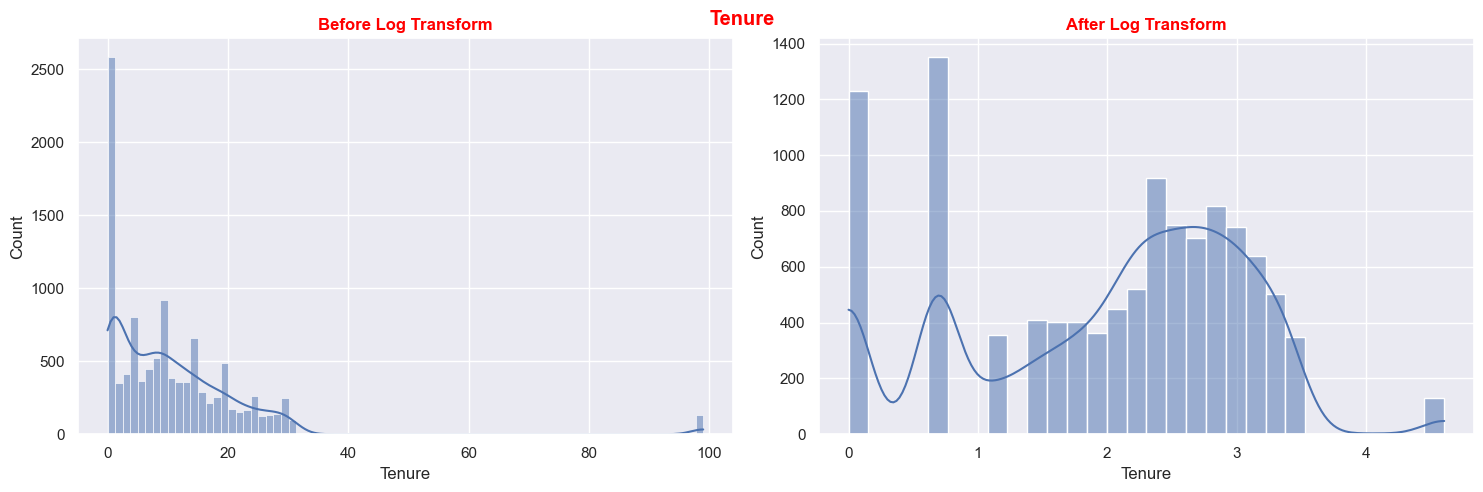

In [101]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.histplot(df,x='Tenure',kde=True)
plt.title('Before Log Transform',color='red',fontweight='bold')
plt.tight_layout()
plt.subplot(1,2,2)
sns.histplot(df_log_transform,x='Tenure',kde=True)
plt.tight_layout()
plt.title('After Log Transform',color='red',fontweight='bold')
plt.suptitle('Tenure',color='red',fontweight='bold',y=0.98)
plt.show()

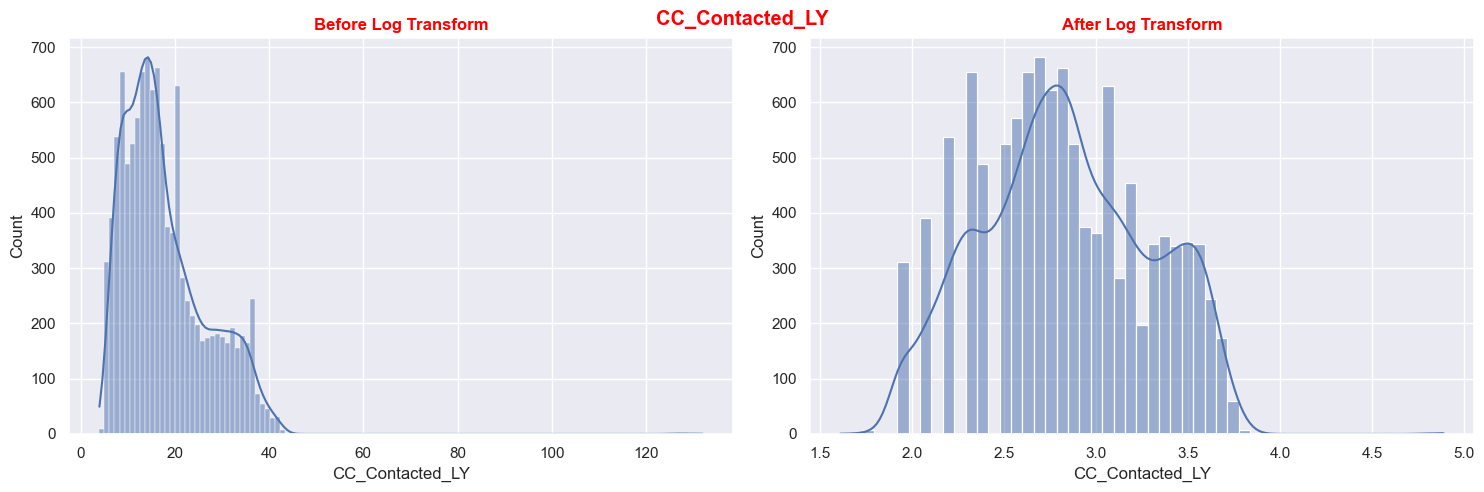

In [102]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.histplot(df,x='CC_Contacted_LY',kde=True)
plt.title('Before Log Transform',color='red',fontweight='bold')
plt.tight_layout()
plt.subplot(1,2,2)
sns.histplot(df_log_transform,x='CC_Contacted_LY',kde=True)
plt.tight_layout()
plt.title('After Log Transform',color='red',fontweight='bold')
plt.suptitle('CC_Contacted_LY',color='red',fontweight='bold',y=0.98)
plt.show()

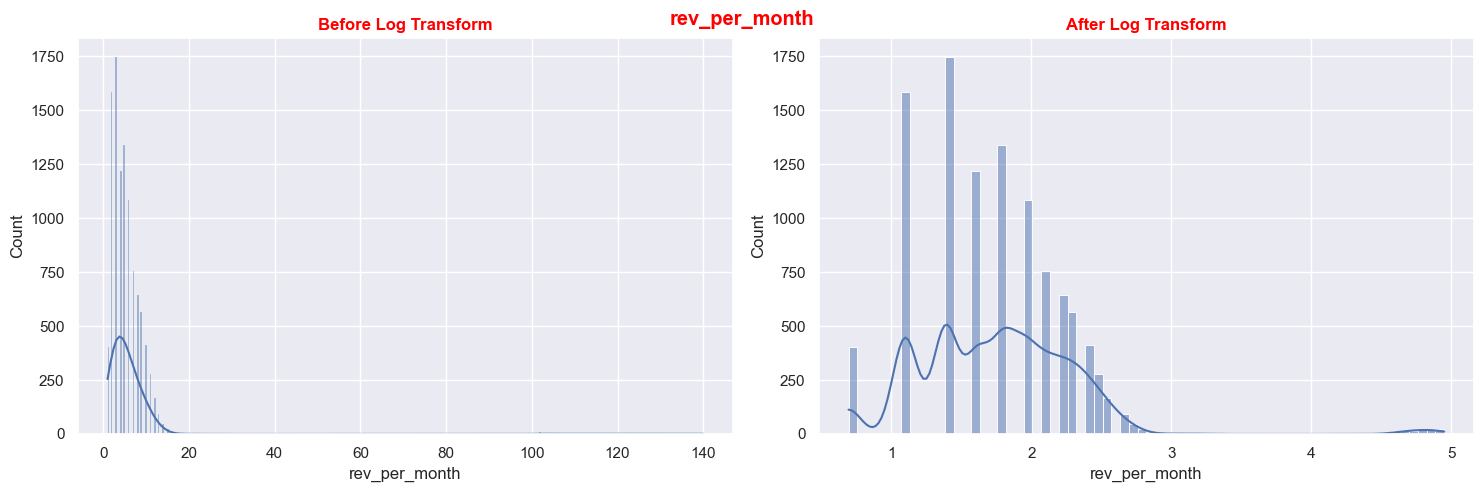

In [103]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.histplot(df,x='rev_per_month',kde=True)
plt.title('Before Log Transform',color='red',fontweight='bold')
plt.tight_layout()
plt.subplot(1,2,2)
sns.histplot(df_log_transform,x='rev_per_month',kde=True)
plt.tight_layout()
plt.title('After Log Transform',color='red',fontweight='bold')
plt.suptitle('rev_per_month',color='red',fontweight='bold',y=0.98)
plt.show()

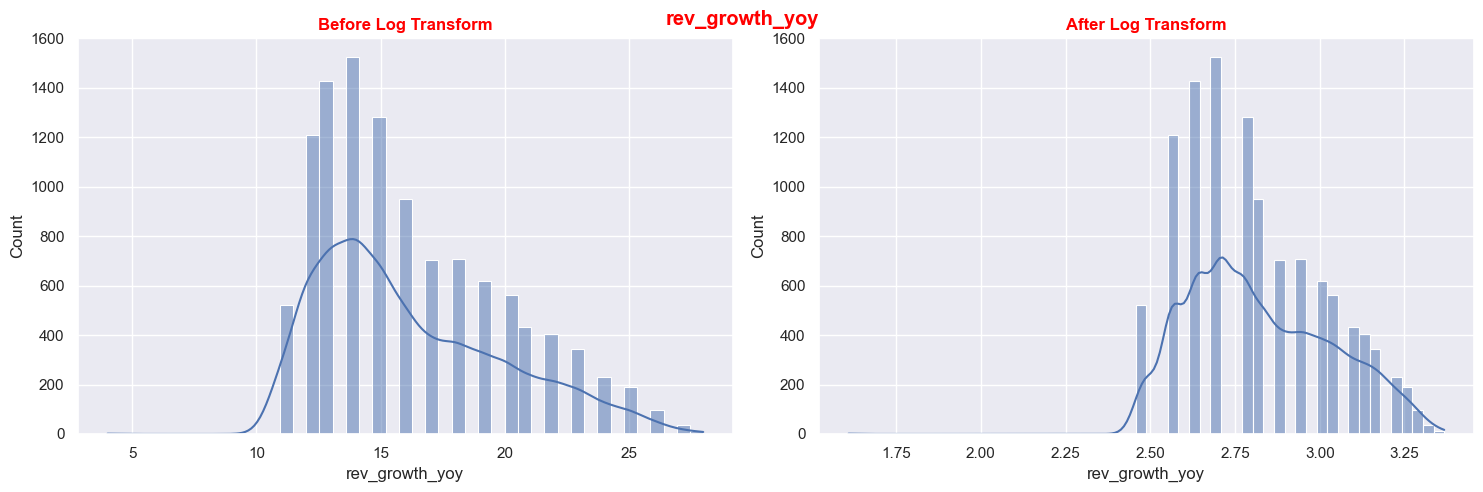

In [104]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.histplot(df,x='rev_growth_yoy',kde=True)
plt.title('Before Log Transform',color='red',fontweight='bold')
plt.tight_layout()
plt.subplot(1,2,2)
sns.histplot(df_log_transform,x='rev_growth_yoy',kde=True)
plt.tight_layout()
plt.title('After Log Transform',color='red',fontweight='bold')
plt.suptitle('rev_growth_yoy',color='red',fontweight='bold',y=0.98)
plt.show()

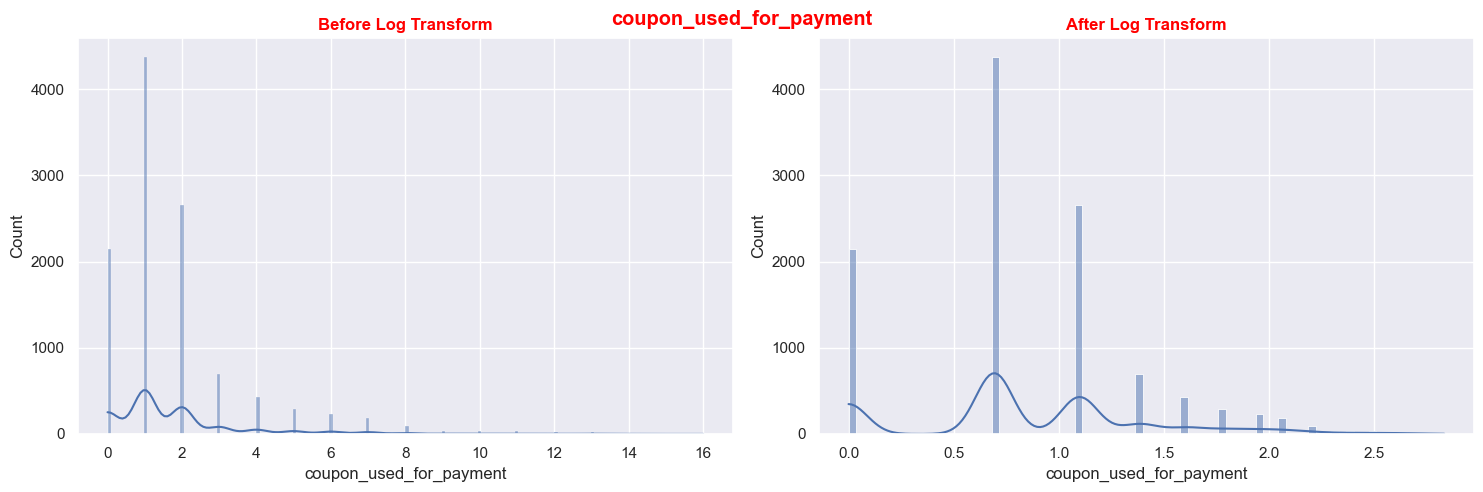

In [105]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.histplot(df,x='coupon_used_for_payment',kde=True)
plt.title('Before Log Transform',color='red',fontweight='bold')
plt.tight_layout()
plt.subplot(1,2,2)
sns.histplot(df_log_transform,x='coupon_used_for_payment',kde=True)
plt.tight_layout()
plt.title('After Log Transform',color='red',fontweight='bold')
plt.suptitle('coupon_used_for_payment',color='red',fontweight='bold',y=0.98)
plt.show()

In [106]:
to_treat

['Tenure',
 'CC_Contacted_LY',
 'rev_per_month',
 'coupon_used_for_payment',
 'rev_growth_yoy',
 'Day_Since_CC_connect',
 'cashback']

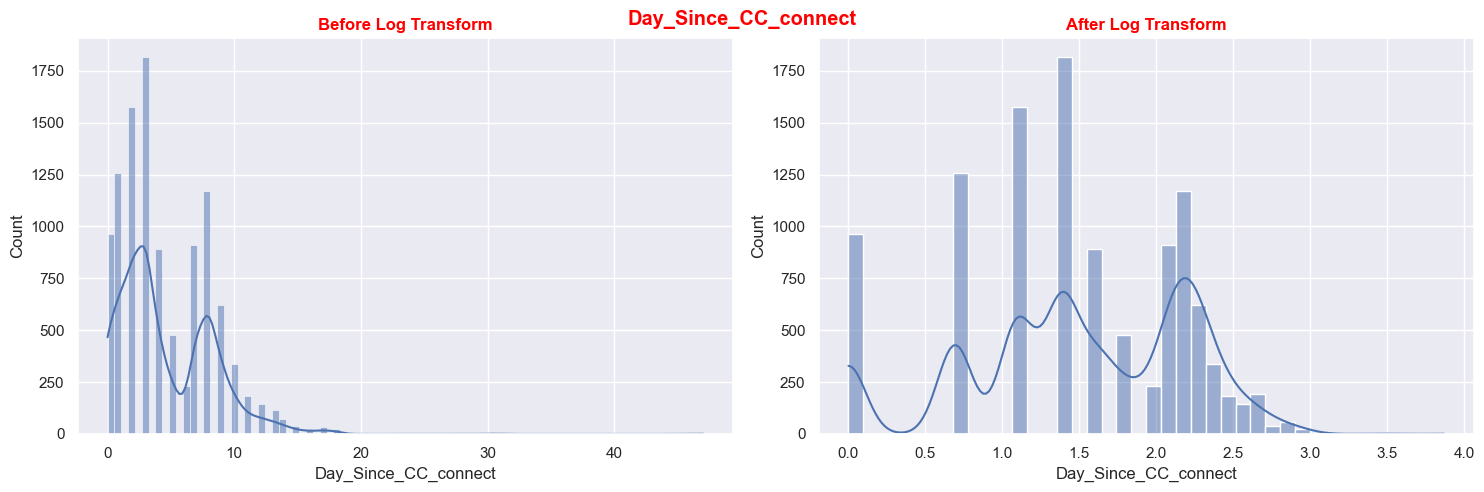

In [107]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.histplot(df,x='Day_Since_CC_connect',kde=True)
plt.title('Before Log Transform',color='red',fontweight='bold')
plt.tight_layout()
plt.subplot(1,2,2)
sns.histplot(df_log_transform,x='Day_Since_CC_connect',kde=True)
plt.tight_layout()
plt.title('After Log Transform',color='red',fontweight='bold')
plt.suptitle('Day_Since_CC_connect',color='red',fontweight='bold',y=0.98)
plt.show()

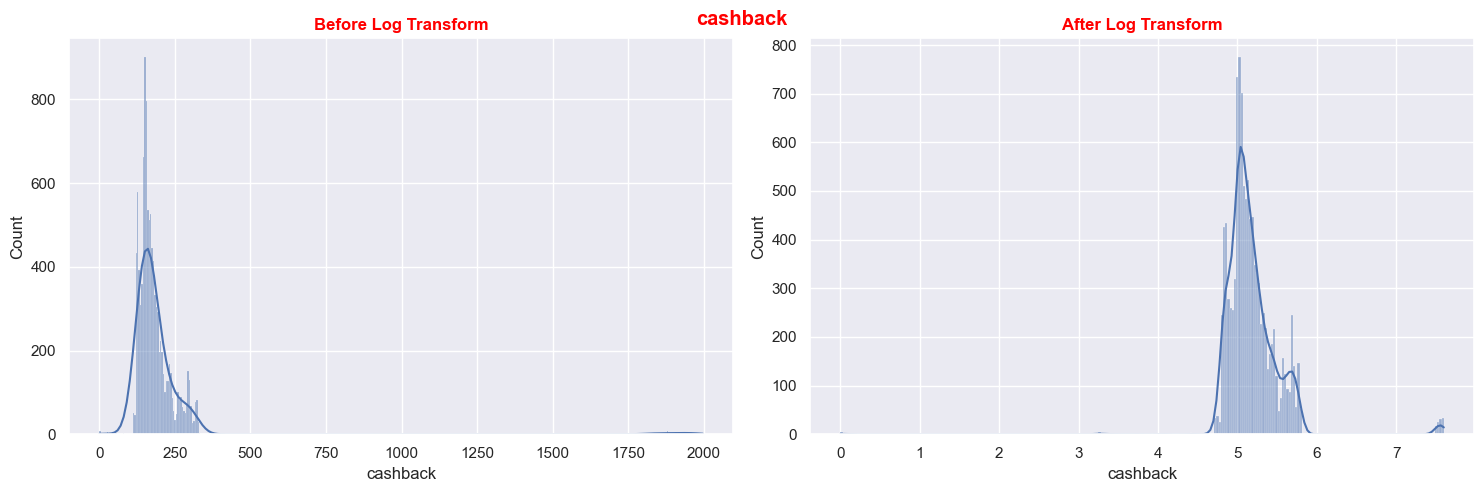

In [108]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.histplot(df,x='cashback',kde=True)
plt.title('Before Log Transform',color='red',fontweight='bold')
plt.tight_layout()
plt.subplot(1,2,2)
sns.histplot(df_log_transform,x='cashback',kde=True)
plt.tight_layout()
plt.title('After Log Transform',color='red',fontweight='bold')
plt.suptitle('cashback',color='red',fontweight='bold',y=0.98)
plt.show()

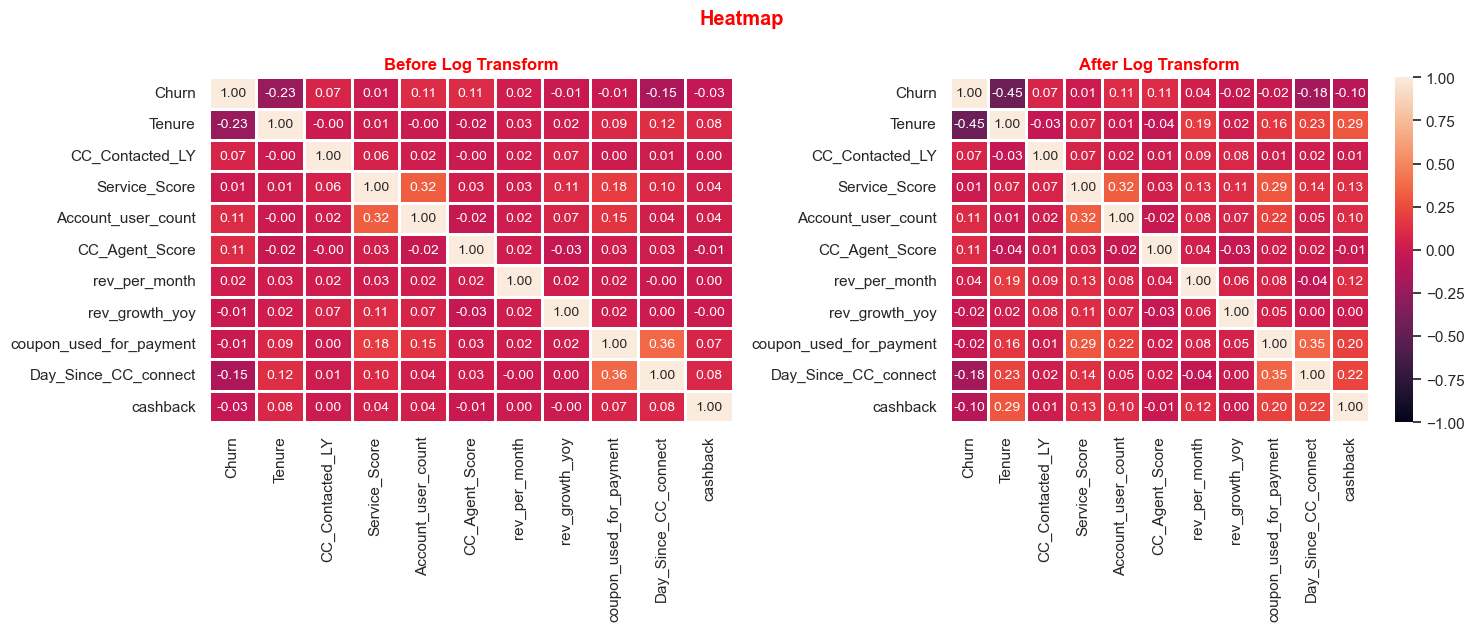

In [109]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
sns.heatmap(df[numeric_columns].corr(),annot=True,linewidths=2,fmt='.2f',annot_kws={"size": 10},vmin=-1,vmax=1,cbar=False)
plt.tight_layout()
plt.title('Before Log Transform',color='red',fontweight='bold')
plt.subplot(1,2,2)
sns.heatmap(df_log_transform[numeric_columns].corr(),annot=True,linewidths=2,fmt='.2f',annot_kws={"size": 10},vmin=-1,vmax=1,cbar=True)
plt.tight_layout()
plt.title('After Log Transform',color='red',fontweight='bold')
plt.suptitle('Heatmap',color='red',fontweight='bold',y=1.05)
plt.show()

### Observation

Applying log transformation enhanced the strength of correlation among the features.

In [110]:
outlier_counts_new = {}
for i in df_log_transform[to_treat].columns:
    lower_whisker,upper_whisker=outliers(df_log_transform[i])
    count = ((df_log_transform[i] < lower_whisker) | (df_log_transform[i] > upper_whisker)).sum()
    outlier_counts_new[i] = (count/df.shape[0])*100

In [111]:
outlier_counts_new

{'Tenure': 0.0,
 'CC_Contacted_LY': 0.035523978685612786,
 'rev_per_month': 0.9680284191829486,
 'coupon_used_for_payment': 27.584369449378332,
 'rev_growth_yoy': 0.02664298401420959,
 'Day_Since_CC_connect': 0.02664298401420959,
 'cashback': 2.6909413854351687}

In [112]:
#lower_whisker,upper_whisker=outliers(df_log_transform['coupon_used_for_payment'])
#df_log_transform.loc[((df_log_transform['coupon_used_for_payment'] < lower_whisker) | (df_log_transform['coupon_used_for_payment'] > upper_whisker)),'coupon_used_for_payment']=np.nan

In [113]:
outlier_counts_new = {}
for i in df_log_transform[to_treat].columns:
    lower_whisker,upper_whisker=outliers(df_log_transform[i])
    count = ((df_log_transform[i] < lower_whisker) | (df_log_transform[i] > upper_whisker)).sum()
    outlier_counts_new[i] = (count/df.shape[0])*100

In [114]:
outlier_counts_new

{'Tenure': 0.0,
 'CC_Contacted_LY': 0.035523978685612786,
 'rev_per_month': 0.9680284191829486,
 'coupon_used_for_payment': 27.584369449378332,
 'rev_growth_yoy': 0.02664298401420959,
 'Day_Since_CC_connect': 0.02664298401420959,
 'cashback': 2.6909413854351687}

In [115]:
df_log_transform.shape

(11260, 18)

## Data Preparation for Model

In [116]:
X=df_log_transform.drop('Churn',axis=1)
y=df_log_transform['Churn']

In [117]:
X.drop(columns=['rev_per_month'],axis=1,inplace=True)

In [118]:
bin_columns=['Gender','Complain_ly']

In [119]:
y.value_counts()

Churn
0    9364
1    1896
Name: count, dtype: int64

In [120]:
y.value_counts(1)*100

Churn
0   83.16
1   16.84
Name: proportion, dtype: float64

The data is imbalanced. We can address this using SMOTE later

### Imputing Others as placeholder in Object Columns

In [121]:
object_columns=['City_Tier', 'Payment', 'account_segment', 'Marital_Status', 'Login_device']

In [122]:
X[object_columns]=X[object_columns].fillna('Others')

In [123]:
X=X.loc[~X[bin_columns].isnull().any(axis=1)]

In [124]:
binary=X[bin_columns].copy()

In [125]:
binary=pd.get_dummies(binary,drop_first=True)

In [126]:
X.drop(['Gender','Complain_ly'],axis=1,inplace=True)

In [127]:
X=pd.get_dummies(X)

In [128]:
X=X.merge(binary, left_index=True, right_index=True)

In [129]:
X=X.astype(float)

In [130]:
others=[]
for i in X.columns:
    if 'Others' in i:
        others.append(i)

In [131]:
y=y.loc[y.index.isin(X.index)]

### Splitting data

In [132]:
X_temp,X_test,y_temp,y_test=train_test_split(X,y,test_size=0.15,random_state=1,stratify=y)
X_train,X_val,y_train,y_val=train_test_split(X_temp,y_temp,test_size=0.18,random_state=1,stratify=y_temp)

In [133]:
for i in others:
    X_train=X_train.drop(i,axis=1)
    X_val=X_val.drop(i,axis=1)
    X_test=X_test.drop(i,axis=1)

In [134]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(7523, 29)
(1652, 29)
(1620, 29)


In [135]:
y_train.value_counts(1)*100

Churn
0   83.18
1   16.82
Name: proportion, dtype: float64

In [136]:
y_val.value_counts(1)*100

Churn
0   83.17
1   16.83
Name: proportion, dtype: float64

In [137]:
y_test.value_counts(1)*100

Churn
0   83.15
1   16.85
Name: proportion, dtype: float64

In [138]:
print('Train size      :',y_train.shape)
print('Validation size :',y_val.shape)
print('Test size       :',y_test.shape)

Train size      : (7523,)
Validation size : (1652,)
Test size       : (1620,)


## Missing Value Treatment

### KNN Imputer

In [139]:
#knn_columns=['Account_user_count','cashback','Tenure','Tenure','Service_Score','CC_Agent_Score']

In [140]:
knn_columns=X_train.select_dtypes(include=np.number).columns

In [141]:
Knn=KNNImputer(n_neighbors=5)

In [142]:
X_train[knn_columns]=Knn.fit_transform(X_train[knn_columns])
X_val[knn_columns]=Knn.transform(X_val[knn_columns])
X_test[knn_columns]=Knn.transform(X_test[knn_columns])

In [143]:
X_train.isnull().sum()[X_train.isnull().sum()>0]

Series([], dtype: int64)

In [144]:
X_val.isnull().sum()[X_val.isnull().sum()>0]


Series([], dtype: int64)

In [145]:
X_test.isnull().sum()[X_test.isnull().sum()>0]

Series([], dtype: int64)

## Scaling Numeric columns

In [146]:
#to_scale=df_log_transform.iloc[:,1:].select_dtypes(include=np.number).columns

In [147]:
to_scale=['Tenure', 'CC_Contacted_LY', 'Service_Score', 'Account_user_count',
       'CC_Agent_Score','rev_growth_yoy',
       'coupon_used_for_payment', 'Day_Since_CC_connect', 'cashback']

In [148]:
sc = StandardScaler()

In [149]:
X_train[to_scale]=sc.fit_transform(X_train[to_scale])
X_val[to_scale]=sc.transform(X_val[to_scale])
X_test[to_scale]=sc.transform(X_test[to_scale])

In [150]:
y_train.value_counts(1)*100

Churn
0   83.18
1   16.82
Name: proportion, dtype: float64

In [151]:
y_val.value_counts(1)*100

Churn
0   83.17
1   16.83
Name: proportion, dtype: float64

In [152]:
y_test.value_counts(1)*100

Churn
0   83.15
1   16.85
Name: proportion, dtype: float64

In [153]:
print(np.round(((X_train.shape[0]+X_val.shape[0]+X_test.shape[0])/data.shape[0])*100),'% of the Data is used for modeling') 

96.0 % of the Data is used for modeling


## Over Sample Data

In [154]:
Os=SMOTE(random_state=1)

In [155]:
X_train_os,y_train_os=Os.fit_resample(X_train,y_train)

In [156]:
y_train_os.value_counts()

Churn
0    6258
1    6258
Name: count, dtype: int64

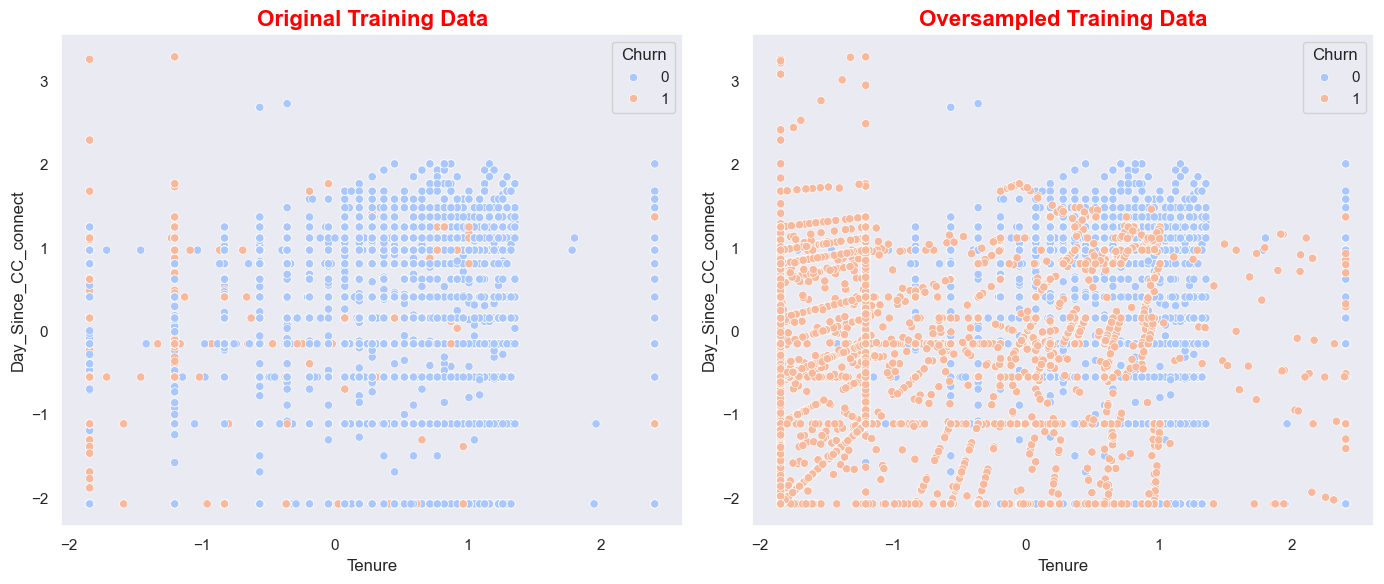

In [157]:
fig,ax=plt.subplots(1,2,figsize=(14, 6))
sns.scatterplot(x=X_train['Tenure'],y=X_train['Day_Since_CC_connect'],hue=y_train,ax=ax[0],palette='coolwarm')
ax[0].grid(False)
ax[0].set_title("Original Training Data",fontweight='bold',color='red',size=16)

sns.scatterplot(x=X_train_os['Tenure'],y=X_train_os['Day_Since_CC_connect'],hue=y_train_os,ax=ax[1],palette='coolwarm')
ax[1].grid(False)
ax[1].set_title("Oversampled Training Data",fontweight='bold',color='red',size=16)

plt.tight_layout()
plt.show()

**Observation**

The original dataset is imbalanced, with significantly fewer churned customers:
- The scatter plot on the left highlights this imbalance, where the representation of class '1' (churn) is noticeably sparse.
- To address this issue, we can apply SMOTE (Synthetic Minority Over-sampling Technique).
- SMOTE tackles class imbalance by generating synthetic examples of the minority class(As illustrated in the scatter plot on the right) through interpolation between existing data points—rather than simply duplicating them which could lead to overfitting.


# Clustering

### Reverse Transforming

In [169]:
X_train_cluster=sc.inverse_transform(X_train.iloc[:,:9])
X_val_cluster=sc.inverse_transform(X_val.iloc[:,:9])
X_test_cluster=sc.inverse_transform(X_test.iloc[:,:9])

In [170]:
X_train_cluster=pd.DataFrame(X_train_cluster,columns=X_train.iloc[:,:9].columns,index=X_train.index)
X_val_cluster=pd.DataFrame(X_val_cluster,columns=X_train.iloc[:,:9].columns,index=X_val.index)
X_test_cluster=pd.DataFrame(X_test_cluster,columns=X_train.iloc[:,:9].columns,index=X_test.index)

In [171]:
to_treat=['Tenure',
 'CC_Contacted_LY',
 'coupon_used_for_payment',
 'rev_growth_yoy',
 'Day_Since_CC_connect',
 'cashback']

In [172]:
for i in to_treat:
    X_train_cluster[i]=np.expm1(X_train_cluster[i])
    X_val_cluster[i]=np.expm1(X_val_cluster[i])
    X_test_cluster[i]=np.expm1(X_test_cluster[i])

In [173]:
og_data=pd.concat([X_train_cluster,X_val_cluster,X_test_cluster])

In [174]:
og_data.head(1)

,Tenure,CC_Contacted_LY,Service_Score,Account_user_count,CC_Agent_Score,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback
4928,14.00,33.00,4.00,4.00,5.00,15.00,4.00,6.00,208.96


In [175]:
data.iloc[4928:4929]

,AccountID,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
4928,24928,0,14.00,3.00,33.00,E wallet,Male,4.00,4.00,Super,5.00,Married,3.00,0.00,15.00,4.00,6.00,208.96,Mobile


both data is same

### Combining X_train , X_val, X_test ,Y_train, y_val, y_test to single data frame for Clustering Analysis

In [182]:
cluster_df=[]

In [183]:
cluster_df=pd.concat([X_train,X_val,X_test])

In [184]:
cluster_df=cluster_df.sort_index()

In [211]:
cluster_df.head()

,Tenure,CC_Contacted_LY,Service_Score,Account_user_count,CC_Agent_Score,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback
0,-0.36,-1.96,0.14,-0.67,-0.78,-1.60,-0.26,0.41,-0.27
1,-1.84,-1.40,0.14,0.30,-0.05,-0.23,-1.47,-2.07,-1.24
2,-1.84,1.34,-1.26,0.30,-0.05,-0.54,-1.47,-0.15,-1.17
3,-1.84,-0.12,-1.26,0.30,1.40,1.70,-1.47,-0.15,-0.88
4,-1.84,-0.58,-1.26,-0.67,1.40,-1.60,-0.26,-0.15,-1.00


- filtering only the actual numeric columns in Cluster_df for clusters

In [185]:
cluster_df=cluster_df.iloc[:,:9].copy()

- cluster_df_cat contains the categorical columns in the same form as they appeared during the df_log_transform step.

In [188]:
cluster_df_cat=df_log_transform.select_dtypes(exclude=np.number).copy()

- Using the placeholder "Others" may be acceptable in modeling but is not ideal for clustering. Hence, null values are replaced with the mode to preserve clustering accuracy.

In [189]:
for i in cluster_df_cat.columns:
    cluster_df_cat[i]=cluster_df_cat[i].fillna(cluster_df_cat[i].mode()[0])

In [218]:
cluster_df_cat=cluster_df_cat[cluster_df_cat.index.isin(cluster_df.index)]

In [190]:
complete_cluster_df=cluster_df_cat.join(cluster_df)

In [217]:
complete_cluster_df=complete_cluster_df[complete_cluster_df.index.isin(cluster_df.index)]

- complete_cluster_df contains scaled numerical features and categorical variables with missing values imputed using their respective modes.

### Elbow method to find K-value

In [191]:
cluster_K=range(1,11)

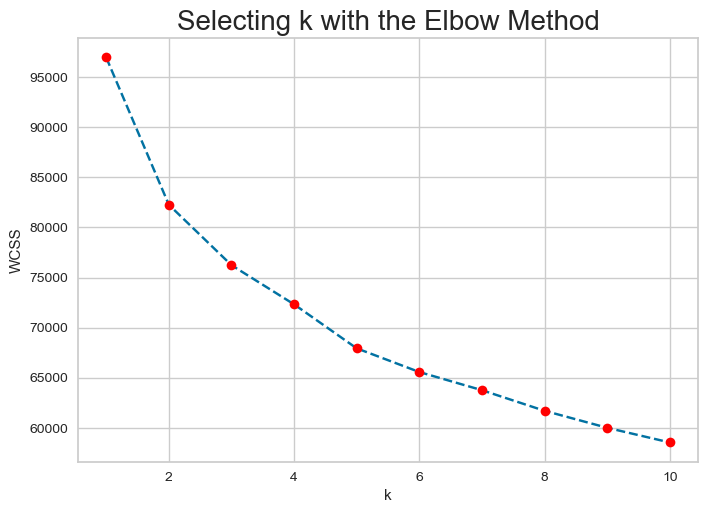

In [194]:
wcss=[]
for k in cluster_K:
    model=KMeans(n_clusters=k,random_state=1)
    model.fit(cluster_df)
    wcss.append(model.inertia_)

plt.plot(cluster_K,wcss,'o--',mfc='red')
plt.xlabel("k")
plt.ylabel("WCSS")
plt.title("Selecting k with the Elbow Method", fontsize=20)
plt.show()

- The Elbow method suggests potential cluster counts between K = 2 and K = 6, further analysis can be conducted to evaluate the most suitable number of clusters.

### Silhouette Score

For n_clusters = 2, silhouette score is 0.14316375480324223
For n_clusters = 3, silhouette score is 0.10646311018029174
For n_clusters = 4, silhouette score is 0.09808617465891603
For n_clusters = 5, silhouette score is 0.1012679798189709
For n_clusters = 6, silhouette score is 0.09916755017070114
For n_clusters = 7, silhouette score is 0.09472935966545946
For n_clusters = 8, silhouette score is 0.0946466730954685
For n_clusters = 9, silhouette score is 0.09389873387595651
For n_clusters = 10, silhouette score is 0.09285628293531414


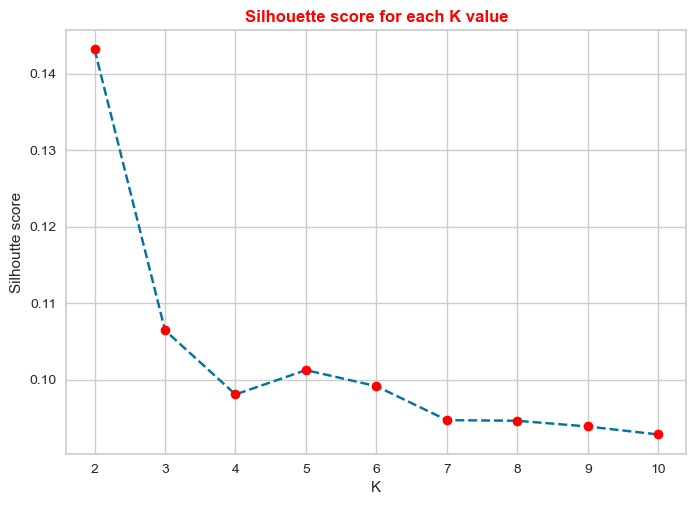

In [195]:
sil_score=[]
cluster_K=range(2,11)
for k in cluster_K:
    model1=KMeans(n_clusters=k,random_state=1)
    pred=model1.fit_predict(cluster_df)
    score=silhouette_score(cluster_df,pred)
    sil_score.append(score)
    print("For n_clusters = {}, silhouette score is {}".format(k, score))

plt.plot(cluster_K, sil_score,'o--',mfc='red')
plt.title('Silhouette score for each K value',color='red',fontweight='bold')
plt.xlabel('K')
plt.ylabel('Silhoutte score')
plt.show()

# Key Observations
- The highest silhouette score is at K = 2, but even that is relatively low.
- Scores gradually decrease up to K=6, then slightly fluctuate.
- Scores around 0.09–0.13 typically indicates the clusters may not be well-separated.

### silhouette visualization for k values between 2 and 6

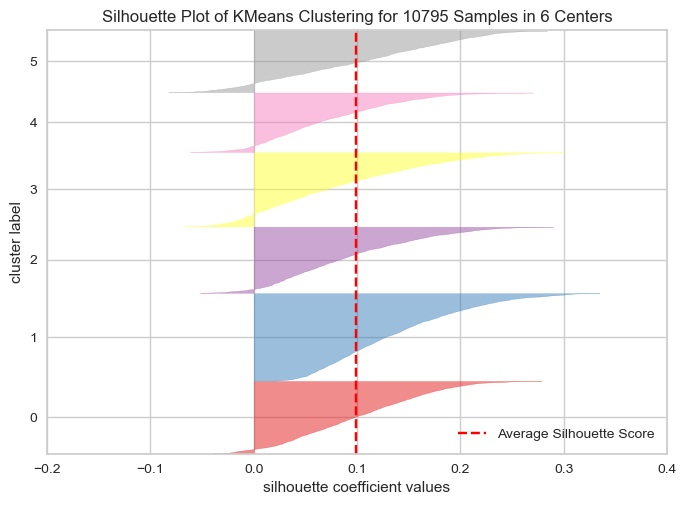

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 10795 Samples in 6 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [196]:
# finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(6, random_state=1))
visualizer.fit(cluster_df)
visualizer.show()

- Several data points fall on the negative side of the silhouette scale, indicating they were likely misclassified and do not align well with their assigned clusters.


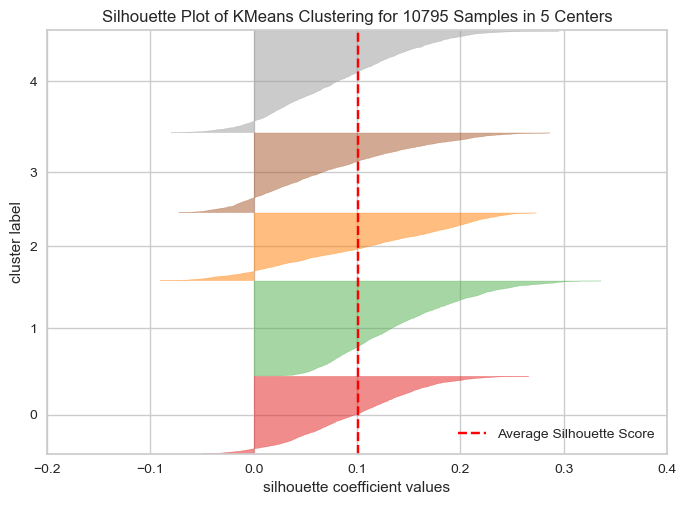

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 10795 Samples in 5 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [197]:
# finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(5, random_state=1))
visualizer.fit(cluster_df)
visualizer.show()

- Several data points fall on the negative side of the silhouette scale, indicating they were likely misclassified and do not align well with their assigned clusters.


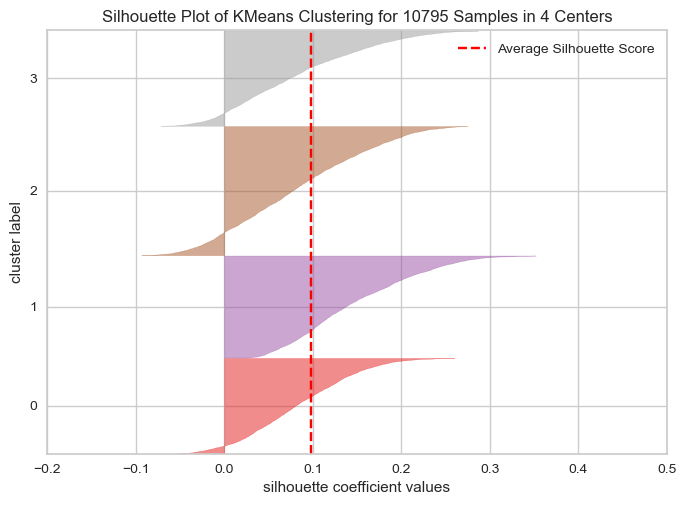

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 10795 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [198]:
# finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(4, random_state=1))
visualizer.fit(cluster_df)
visualizer.show()

- While K = 4 yields a slightly better silhouette score than K = 5 or 6, several data points still exhibit negative values—suggesting potential misclassification and weak alignment with their assigned clusters.

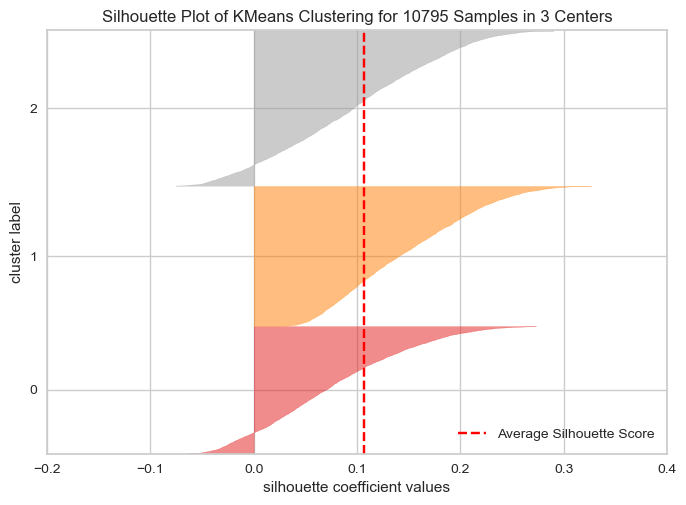

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 10795 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [199]:
# finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(3, random_state=1))
visualizer.fit(cluster_df)
visualizer.show()

- K = 3 yields a slightly better silhouette score than K = 4 or 5 or 6, several data points still exhibit negative values—suggesting potential misclassification and weak alignment with their assigned clusters.

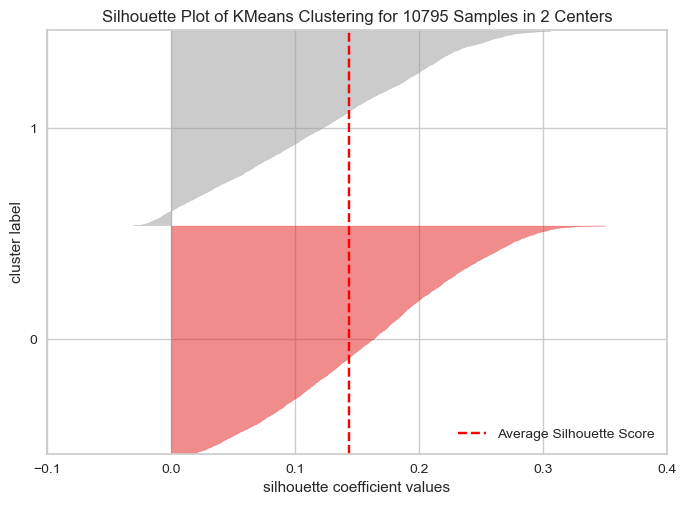

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 10795 Samples in 2 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [200]:
# finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(2, random_state=1))
visualizer.fit(cluster_df)
visualizer.show()

- K = 2 achieves the best silhouette score among the tested values, a few data points still fall below zero, hinting at minor misclassifications but generally well-separated clusters.

# K - Means Algorithm

In [201]:
kmeans = KMeans(n_clusters=2, random_state=1)
kmeans.fit(cluster_df)

KMeans(n_clusters=2, random_state=1)

In [219]:
# Original Data scale is used to profile the cluster
final_cluster=cluster_df_cat.join(og_data)

In [220]:
# adding kmeans cluster labels to the original dataframe
final_cluster["K_means_segments"] = kmeans.labels_

In [221]:
cluster_profile = np.ceil(final_cluster.groupby("K_means_segments").mean(numeric_only = True))

In [222]:
cluster_profile["count_in_each_segment"] = (
    final_cluster.groupby("K_means_segments")['Tenure'].count().values)

In [223]:
# let's display cluster profiles
cluster_profile.T.style.highlight_max(color="green", axis=1)

K_means_segments,0,1
Tenure,14.000000,9.000000
CC_Contacted_LY,19.000000,18.000000
Service_Score,4.000000,3.000000
Account_user_count,5.000000,4.000000
CC_Agent_Score,4.000000,4.000000
rev_growth_yoy,17.000000,16.000000
coupon_used_for_payment,3.000000,1.000000
Day_Since_CC_connect,6.000000,4.000000
cashback,200.000000,155.000000
count_in_each_segment,5823.000000,4972.000000


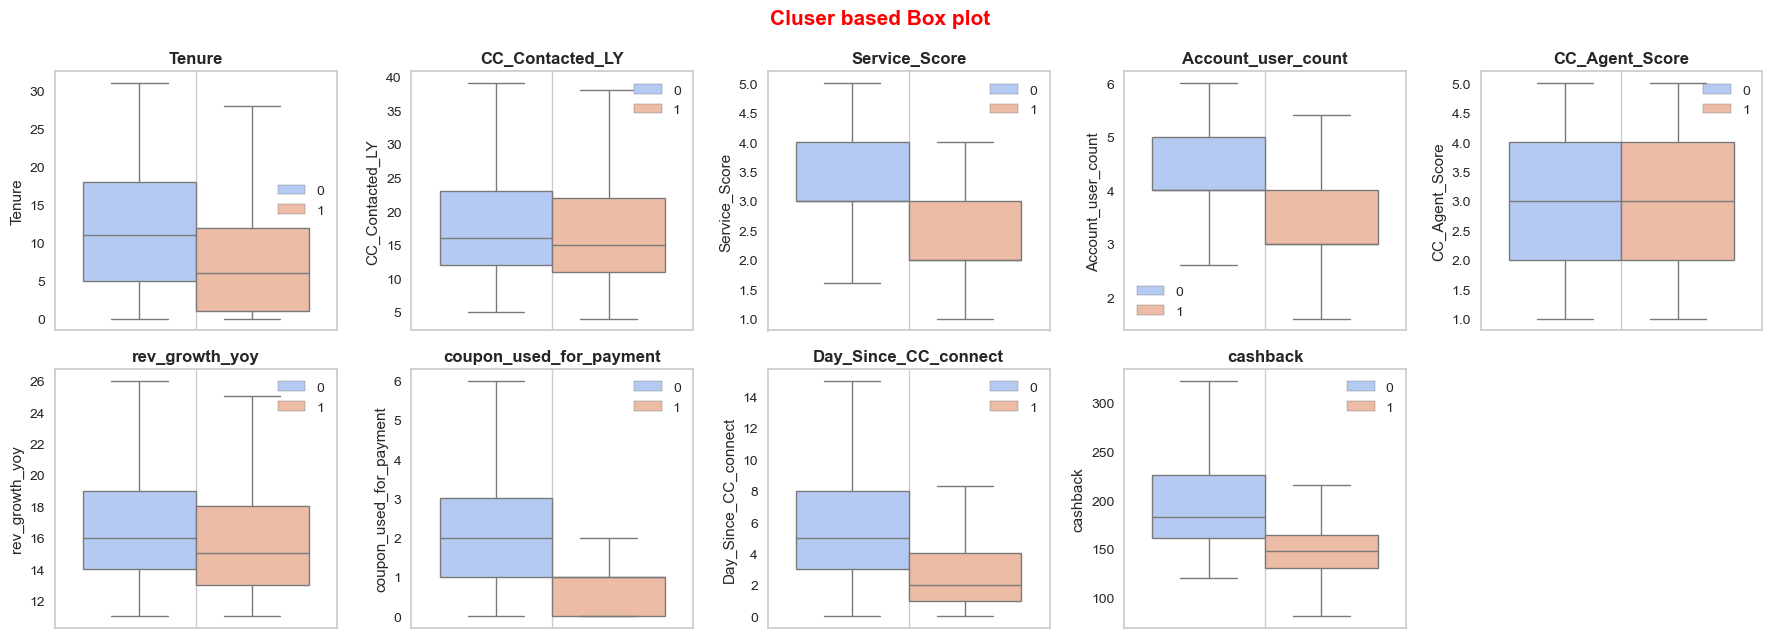

In [224]:
plt.figure(figsize=(18,6.5))
for i,value in enumerate (final_cluster.iloc[:,:-1].select_dtypes(include=np.number).columns):
    plt.subplot(2,5,i+1)
    sns.boxplot(data=final_cluster.iloc[:,:-1],y=value,hue=final_cluster.K_means_segments,showfliers=False,palette='coolwarm')
    plt.legend(loc=0)
    plt.grid(None)
    plt.title(value,fontweight='bold')
plt.suptitle("Cluser based Box plot", fontsize=15,color='red',fontweight='bold')
plt.tight_layout()
plt.show()

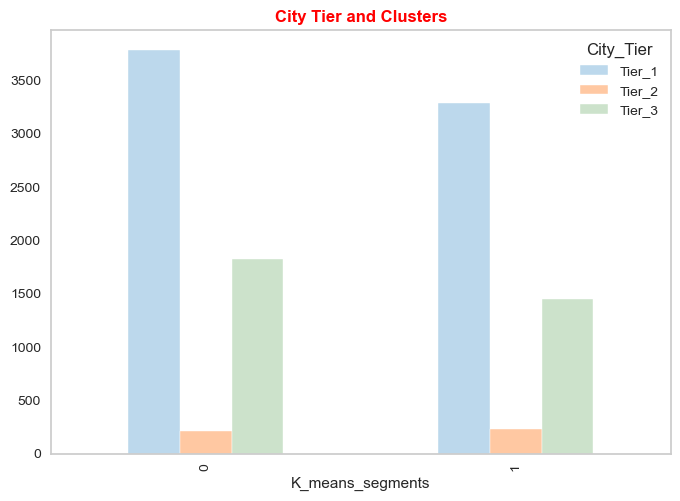

In [225]:
pd.crosstab(final_cluster.K_means_segments, final_cluster.City_Tier).plot(kind='bar',color=['#BCD8EC','#FFC8A2','#CCE2CB'])
plt.title("City Tier and Clusters",color='red',fontweight='bold')
plt.grid(None)
plt.show()

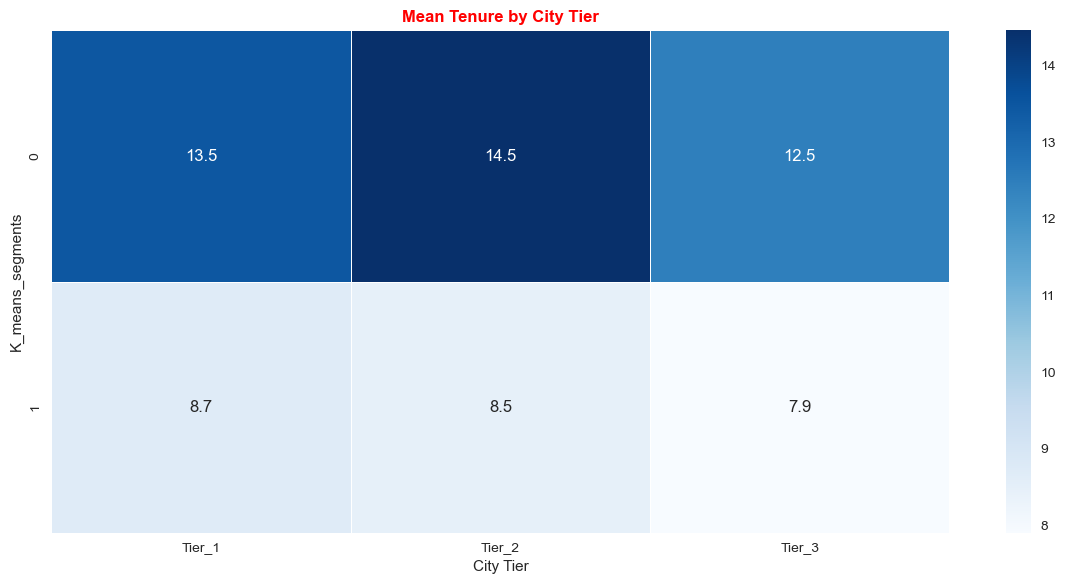

In [226]:
final_cluster_df = final_cluster.groupby(['K_means_segments', 'City_Tier'])['Tenure'].mean().reset_index() \
    .pivot_table(index=[ 'K_means_segments'], columns=['City_Tier'], values='Tenure').fillna(0)

# Plot as heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(final_cluster_df, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5)
plt.title("Mean Tenure by City Tier",color='red',fontweight='bold')
plt.xlabel("City Tier")
plt.ylabel("K_means_segments")
plt.tight_layout()
plt.show()

Observation:

Across both clusters, Tier 1 cities have the highest customer count, followed by Tier 3.
However, when looking at average tenure, a different pattern emerges:
- In Cluster 0, customers from Tier 2 cities have the longest tenure, averaging 14.5 months, followed by those in Tier 1 and Tier 3.
- In Cluster 1, Tier 3 city customers show the shortest tenure, averaging 7.9 months, with Tier 1 and Tier 2 following behind.


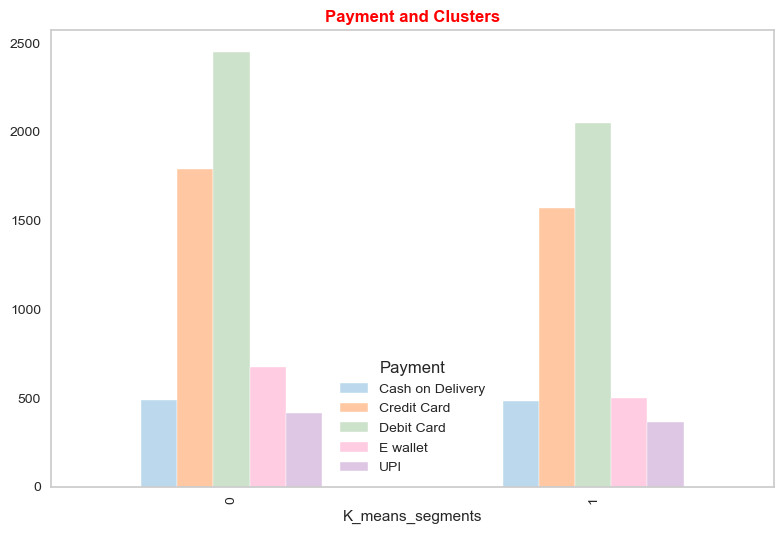

In [227]:
pd.crosstab(final_cluster.K_means_segments, final_cluster.Payment).plot(kind='bar',color=['#BCD8EC','#FFC8A2','#CCE2CB','#FFCCE1','#DEC7E5'])
plt.title("Payment and Clusters",color='red',fontweight='bold')
plt.grid(None)
plt.tight_layout()
plt.show()

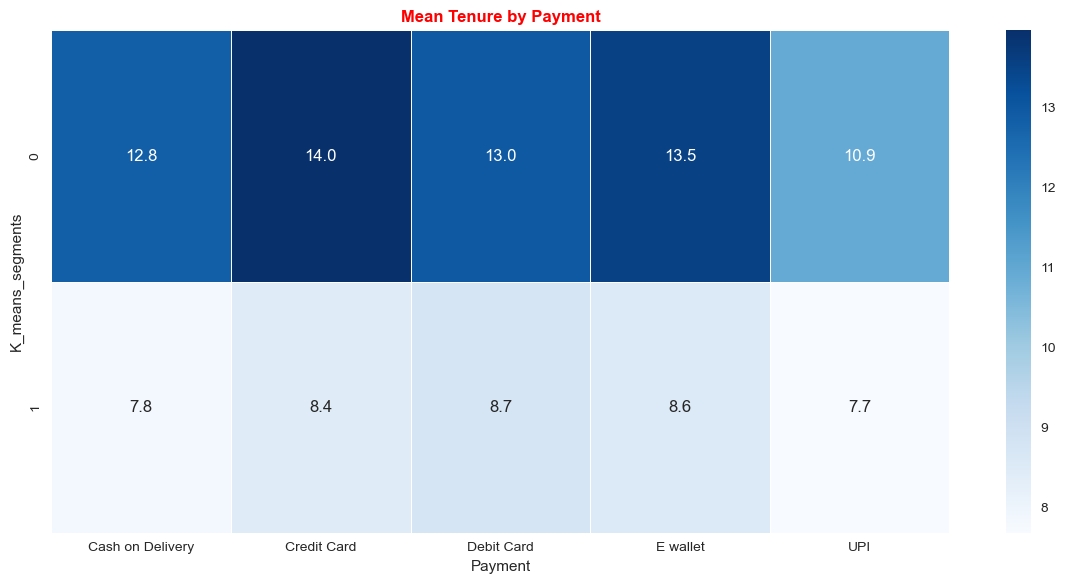

In [228]:
final_cluster_df = final_cluster.groupby(['K_means_segments', 'Payment'])['Tenure'].mean().reset_index() \
    .pivot_table(index=[ 'K_means_segments'], columns=['Payment'], values='Tenure').fillna(0)

# Plot as heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(final_cluster_df, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5)
plt.title("Mean Tenure by Payment",color='red',fontweight='bold')
plt.xlabel("Payment")
plt.ylabel("K_means_segments")
plt.tight_layout()
plt.show()

Observation:

- Debit card is the most common payment method across both clusters in terms of customer count.
- In Cluster 0, customers using Credit Cards and E-wallets tend to have the longest tenures, averaging over 14 months. This is followed by those using Cash on Delivery and Debit cards, while UPI users show the shortest tenure.
- In Cluster 1, customers opting for Cash on Delivery exhibit the lowest average tenure at 7.8 months, followed by UPI users at 7.7 months. All other payment modes record tenure averages above 8 months.


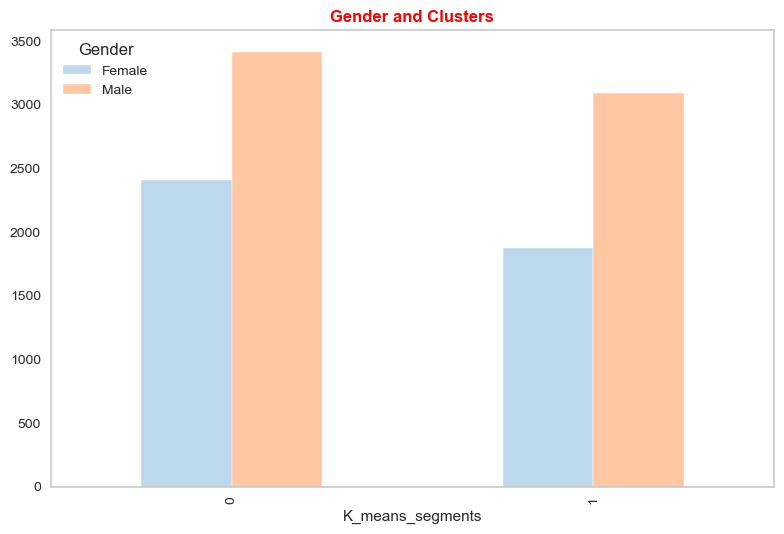

In [229]:
pd.crosstab(final_cluster.K_means_segments, final_cluster.Gender).plot(kind='bar',color=['#BCD8EC','#FFC8A2','#CCE2CB','#FFCCE1','#DEC7E5'])
plt.title("Gender and Clusters",color='red',fontweight='bold')
plt.grid(None)
plt.tight_layout()
plt.show()

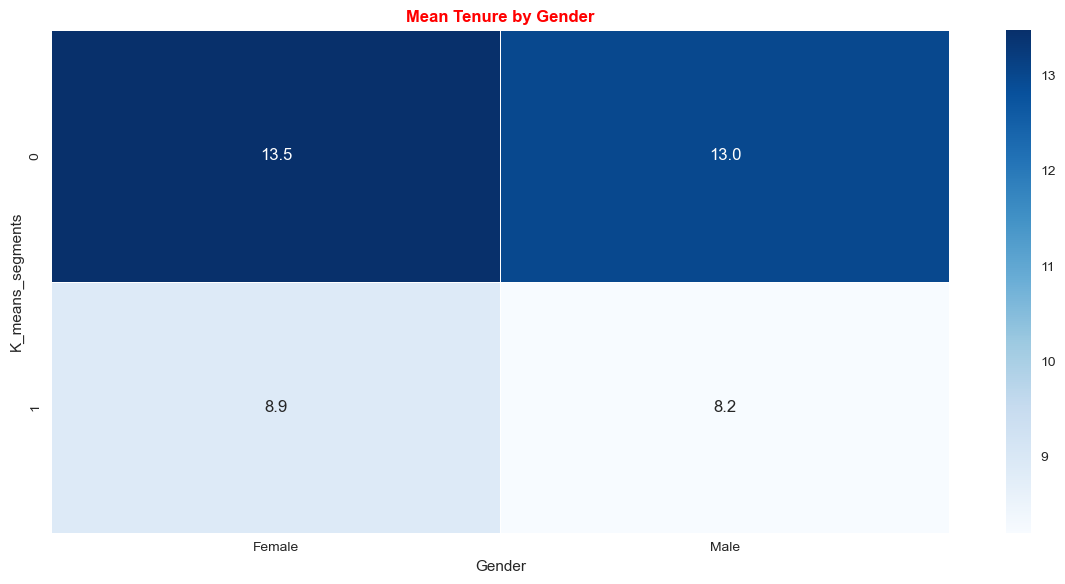

In [230]:
final_cluster_df = final_cluster.groupby(['K_means_segments', 'Gender'])['Tenure'].mean().reset_index() \
    .pivot_table(index=[ 'K_means_segments'], columns=['Gender'], values='Tenure').fillna(0)

# Plot as heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(final_cluster_df, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5)
plt.title("Mean Tenure by Gender",color='red',fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("K_means_segments")
plt.tight_layout()
plt.show()


**Observation:**

While male customers outnumber females in both clusters, it's the female customers who tend to stay longer. On average, female users have a higher tenure in both Cluster 0 and Cluster 1, suggesting stronger retention among women despite lower overall representation.


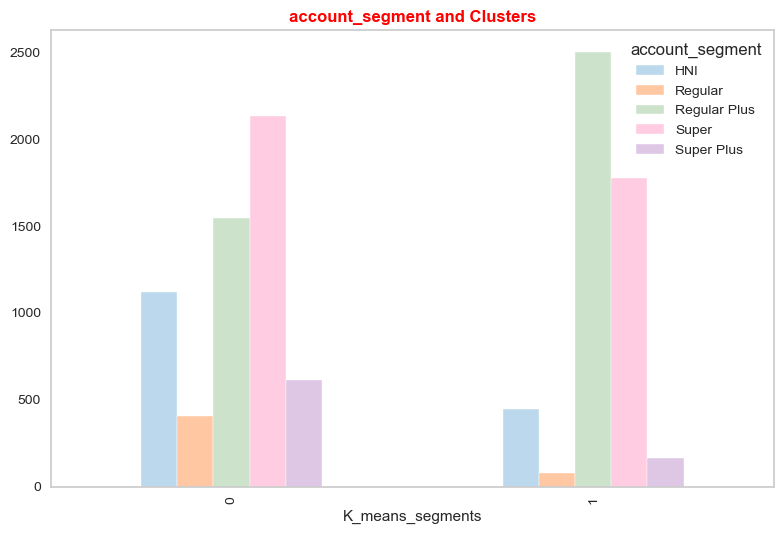

In [231]:
pd.crosstab(final_cluster.K_means_segments, final_cluster.account_segment).plot(kind='bar',color=['#BCD8EC','#FFC8A2','#CCE2CB','#FFCCE1','#DEC7E5'])
plt.title("account_segment and Clusters",color='red',fontweight='bold')
plt.grid(None)
plt.tight_layout()
plt.show()

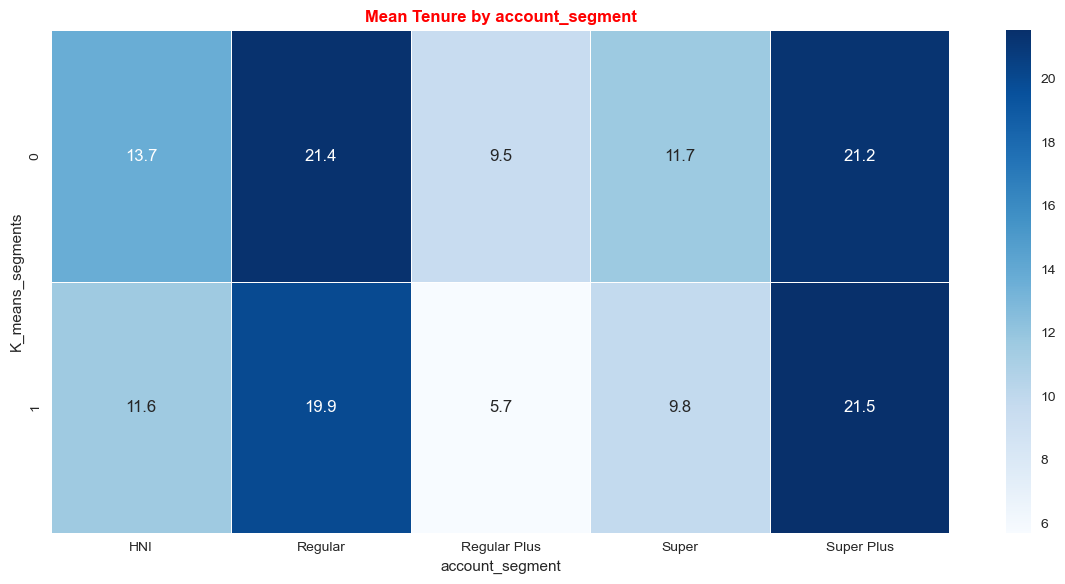

In [232]:
final_cluster_df = final_cluster.groupby(['K_means_segments', 'account_segment'])['Tenure'].mean().reset_index() \
    .pivot_table(index=[ 'K_means_segments'], columns=['account_segment'], values='Tenure').fillna(0)

# Plot as heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(final_cluster_df, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5)
plt.title("Mean Tenure by account_segment",color='red',fontweight='bold')
plt.xlabel("account_segment")
plt.ylabel("K_means_segments")
plt.tight_layout()
plt.show()


**Observations:**

- Although Cluster 0 is dominated by Super segment customers, the longest-staying individuals actually come from the Regular and Super Plus segments—followed by HNI and then Super.
- In contrast, Cluster 1 has more Regular Plus customers overall, but again, the Regular and Super Plus users show higher tenure. HNI and Super follow behind.
- Notably, Regular Plus customers have the shortest tenure across both clusters, despite being the largest group in Cluster 1.



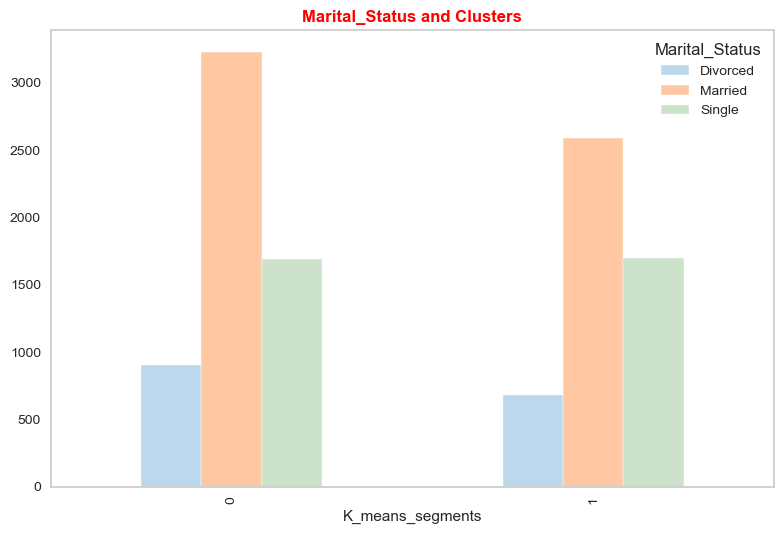

In [233]:
pd.crosstab(final_cluster.K_means_segments, final_cluster.Marital_Status).plot(kind='bar',color=['#BCD8EC','#FFC8A2','#CCE2CB','#FFCCE1','#DEC7E5'])
plt.title("Marital_Status and Clusters",color='red',fontweight='bold')
plt.grid(None)
plt.tight_layout()
plt.show()

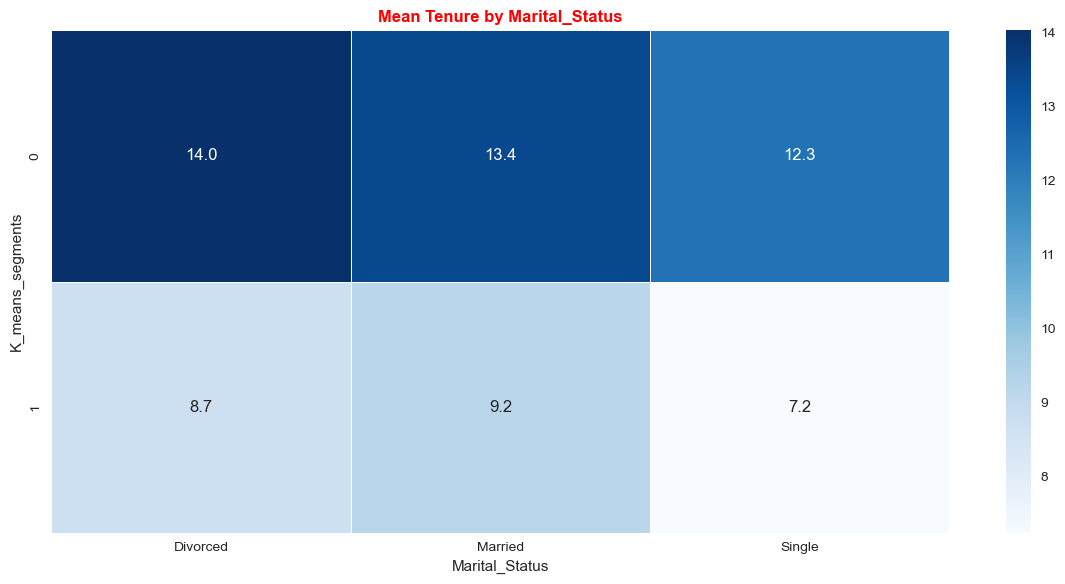

In [234]:
final_cluster_df = final_cluster.groupby(['K_means_segments', 'Marital_Status'])['Tenure'].mean().reset_index() \
    .pivot_table(index=[ 'K_means_segments'], columns=['Marital_Status'], values='Tenure').fillna(0)

# Plot as heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(final_cluster_df, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5)
plt.title("Mean Tenure by Marital_Status",color='red',fontweight='bold')
plt.xlabel("Marital_Status")
plt.ylabel("K_means_segments")
plt.tight_layout()
plt.show()


**Observation:**

Married customers make up the majority in both clusters, and their average tenure is fairly similar across the board. However, a notable difference appears with single customers:
- In Cluster 0, single individuals tend to stay longer, averaging around 12.3 months.
- In Cluster 1, their tenure drops significantly to 7.2 months, suggesting lower retention among singles in that group.

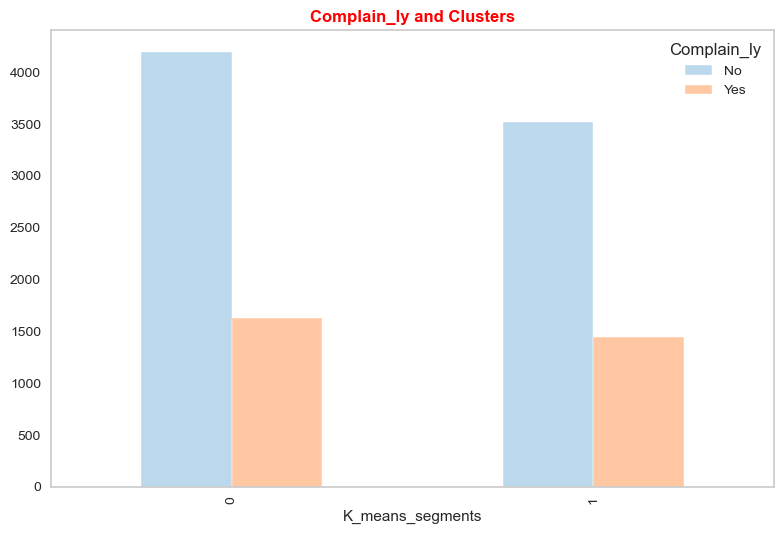

In [235]:
pd.crosstab(final_cluster.K_means_segments, final_cluster.Complain_ly).plot(kind='bar',color=['#BCD8EC','#FFC8A2','#CCE2CB','#FFCCE1','#DEC7E5'])
plt.title("Complain_ly and Clusters",color='red',fontweight='bold')
plt.grid(None)
plt.tight_layout()
plt.show()

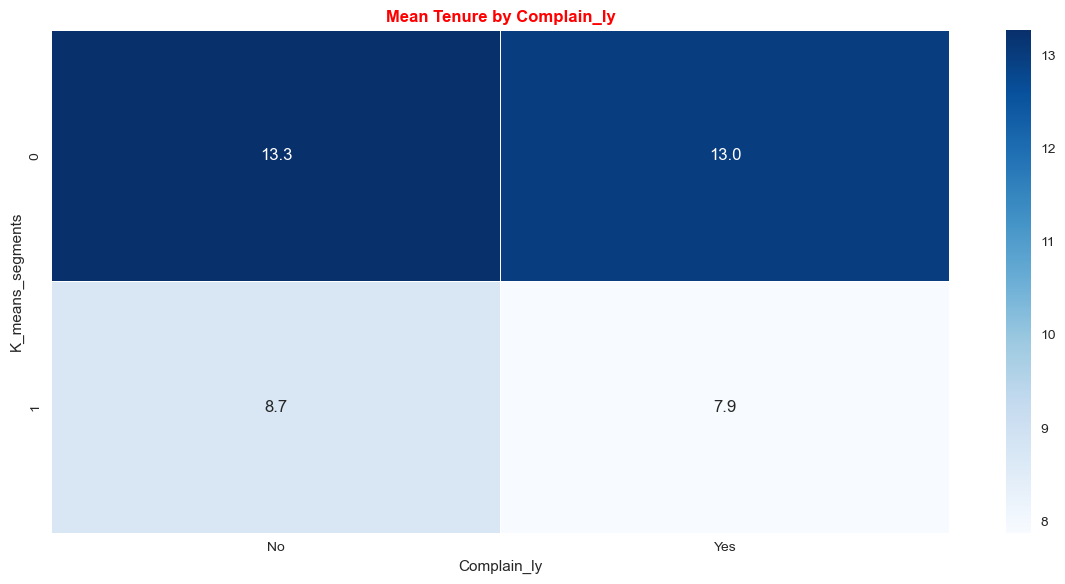

In [236]:
final_cluster_df = final_cluster.groupby(['K_means_segments', 'Complain_ly'])['Tenure'].mean().reset_index() \
    .pivot_table(index=[ 'K_means_segments'], columns=['Complain_ly'], values='Tenure').fillna(0)

# Plot as heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(final_cluster_df, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5)
plt.title("Mean Tenure by Complain_ly",color='red',fontweight='bold')
plt.xlabel("Complain_ly")
plt.ylabel("K_means_segments")
plt.tight_layout()
plt.show()


**Observation:**

Customers who did not raise any complaints in the past year tend to have a slightly longer tenure than those who did, in both clusters. This suggests a link between complaint-free experience and customer retention.


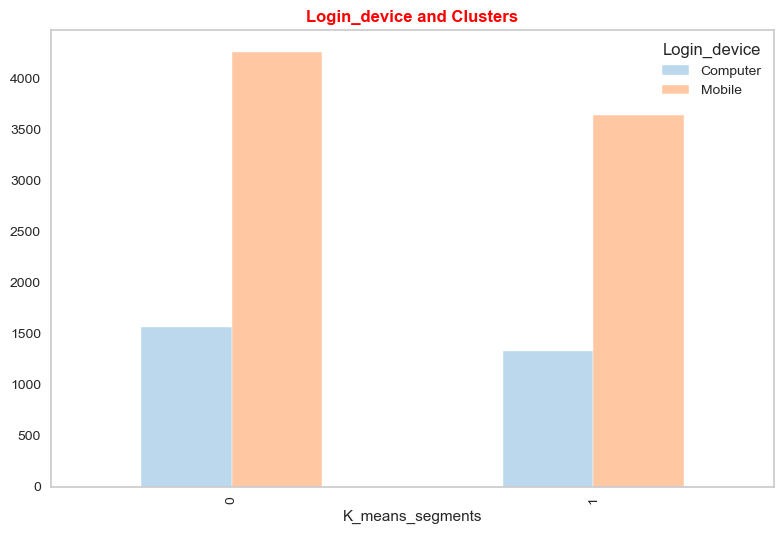

In [237]:
pd.crosstab(final_cluster.K_means_segments, final_cluster.Login_device).plot(kind='bar',color=['#BCD8EC','#FFC8A2','#CCE2CB','#FFCCE1','#DEC7E5'])
plt.title("Login_device and Clusters",color='red',fontweight='bold')
plt.grid(None)
plt.tight_layout()
plt.show()

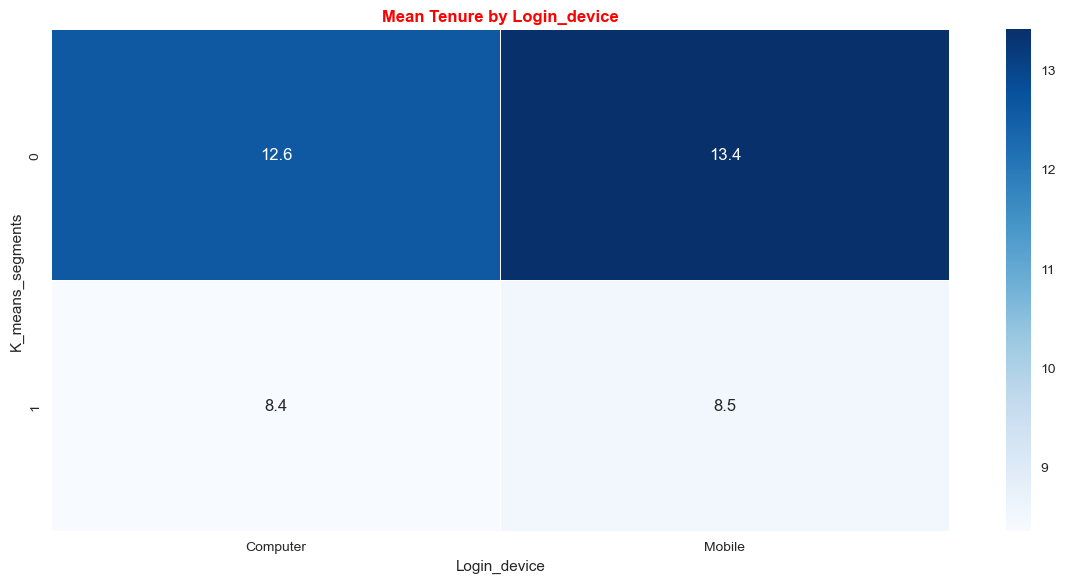

In [238]:
final_cluster_df = final_cluster.groupby(['K_means_segments', 'Login_device'])['Tenure'].mean().reset_index() \
    .pivot_table(index=[ 'K_means_segments'], columns=['Login_device'], values='Tenure').fillna(0)

# Plot as heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(final_cluster_df, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5)
plt.title("Mean Tenure by Login_device",color='red',fontweight='bold')
plt.xlabel("Login_device")
plt.ylabel("K_means_segments")
plt.tight_layout()
plt.show()


**Observation:**

- In Cluster 1, customers who log in using either computer or mobile have similar tenure values, though both are lower compared to customers in Cluster 0.
- In Cluster 0, customers using mobile devices for login tend to have the longest tenure, indicating stronger retention within that group.


**Overall Observation:**

We’ve segmented the customer base into two distinct clusters:

**Cluster 0 Overview — High-Value, Loyal Customers (6,119 individuals)**

This segment consists of customers who consistently deliver long-term value to the company and show strong signs of retention. On average, their tenure spans **14 months**, indicating a deep and ongoing engagement.

Key attributes include:
- **Service Satisfaction**: High satisfaction levels reflected in average service and CC agent scores of **4**.
- **Account Engagement**: Each account typically serves **5 users**, showcasing active usage.
- **Coupon & Cashback Behavior**: These customers frequently use **coupons** and receive **significant cashback rewards**.
- **Customer Care Interaction**: Due to the large volume, their **CC_contacted_LY** metric is slightly elevated, though their **Day_Since_CC_Connect** is high—implying few recent escalations.
- **Location Profile**: Predominantly from **Tier 1 cities**, followed by Tier 3.
- **Payment Preference**: They favor **debit cards** for transactions.
- **Demographics**: Mostly **male and married**, indicating a more settled customer profile.
- **Account Segment Preference**: Strong inclination toward **Super accounts**, with **Regular Plus** as the secondary choice.
- **Complaint Behavior**: A notable **73%** did not lodge any complaints in the past year.
- **Login Channel**: Prefer using **mobile devices** for access.

---

**Cluster 1 – Short-Term, Revenue-Driven Customers (5,141 total)**

This segment contributes meaningfully to revenue but tends to have **shorter engagement** and a **higher churn rate**. On average, customers in this group stay for **9 months**.

**Key traits:**
- Their **CC_contacted_LY** is comparable to Cluster 0, despite having fewer customers.
- **Service scores** average **3**, with **agent scores at 4**, indicating moderate satisfaction.
- Accounts support an average of **4 users**.
- They use **fewer coupons** and receive **minimal cashback**.
- **Day_Since_CC_Connect** is low, showing **recent customer care contact**.
- Majority are from **Tier 1 cities**, followed by Tier 3.
- Prefer **debit cards** for transactions and **mobile devices** for login.
- **Male** and **married** customers dominate this cluster.
- Most belong to the **Regular Plus** segment, followed by **Super** accounts.
- **72%** didn’t file any complaints last year.
---

**City Tier & Tenure Patterns**
- **Tier 1 cities** have the largest customer base across both clusters.
- In **Cluster 0**, **Tier 2** customers have the longest tenure (**14.3 months**) ahead of Tier 1 and Tier 3.
- In **Cluster 1**, **Tier 3** customers have the shortest tenure (**7.9 months**), followed by Tier 1 and Tier 2.

---

**Payment Mode vs. Tenure**
- **Debit card** is the most commonly used method.
- In **Cluster 0**, customers using **credit cards** and **e-wallets** have the **longest tenure** (14+ months), followed by those using **cash on delivery**, **debit cards**, and finally **UPI** with the shortest duration.
- In **Cluster 1**, **cash on delivery** users stay the shortest (**7.6 months**), followed by **UPI** (**7.8 months**), while other methods record slightly higher tenures (above 8 months).

---

**Gender & Retention**
- Though **male customers dominate numerically**, **female customers consistently show longer tenure** in both clusters, suggesting stronger retention among women.

---

**Account Segment Comparison**
- Although Cluster 0 is dominated by Super segment customers, the longest-staying individuals actually come from the Regular and Super Plus segments—followed by HNI and then Super.
- In contrast, Cluster 1 has more Regular Plus customers overall, but again, the Regular and Super Plus users show higher tenure. HNI and Super follow behind.
- Notably, Regular Plus customers have the shortest tenure across both clusters, despite being the largest group in Cluster 1.


---

**Marital Status & Tenure**
- **Married customers** are the majority in both clusters, with similar tenure levels.
- **Single customers** show a stronger contrast:
  - In **Cluster 0**, they average **12 months**.
  - In **Cluster 1**, their average drops to **7.2 months**, indicating lower retention.

---

**Complaint Impact on Retention**
- Customers who **did not complain** in the past year tend to stay **slightly longer** across both clusters, hinting at the role of frictionless service in driving retention.

---

**Login Behavior & Tenure**
- In **Cluster 1**, tenure is similar regardless of login method (mobile or computer) but remains lower than Cluster 0.
- In **Cluster 0**, customers logging in via **mobile devices** enjoy the **longest tenure**, indicating a more engaged digital experience.

# Model Building

**Model can make wrong predictions as:**
- False Positive: The model predicts the customer will churn, but in reality, customer does not.
- False Negative: The model predicts the customer will not churn, but in reality, customer does.


**Which case is more important?**
* Predicting a customer wont churn,but actually customer does.

**How to reduce this loss ?**
* We would want Recall-score to be maximized.

# Model Types:

## Parametric Models
These model has some assumptions about the data.

- Logistic Regression: Assumes the data has a linear pattern, features aren’t too closely related (no multicollinearity), and sometimes expects errors to follow a normal distribution.
- Naive Bayes: Assumes all features are independent from each other once the class label is known.

Both logistic regression and Naive Bayes models can be impacted by outliers, multicollinearity, and irrelevant features:
- Outliers can skew predictions, especially in logistic regression where they distort the decision boundary.
- Multicollinearity affects logistic regression by making coefficient estimates unstable, while it breaks Naive Bayes' assumption of feature independence.
- Non-significant (irrelevant) features reduce model clarity and may lower accuracy in both models unless filtered or regularized

## Non Parametric Models.
These model are robust in nature and doesn't make assumptions.

- KNNClassifier
- DecisionTree
- BaggingClassifier
- RandomForest
- AdaboostClasstifier
- GBMClassifier
- XGBClassifier


# Functions for models

In [249]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def lr_performance_classification(model, predictors, target, threshold = 0.5):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    prob_pred = model.predict(predictors)
    class_pred = [1 if i >= threshold else 0 for i in prob_pred]

    acc = accuracy_score(target, class_pred)*100  # to compute Accuracy
    recall = recall_score(target, class_pred)*100  # to compute Recall
    precision = precision_score(target, class_pred)*100  # to compute Precision
    f1 = f1_score(target, class_pred)*100  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [250]:
def lr_confusion_matrix(model, predictors, target, threshold = 0.5):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    prob_pred = model.predict(predictors)
    class_pred = [1 if i >= threshold else 0 for i in prob_pred]
    cm = confusion_matrix(target, class_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.title(model)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.show()

In [251]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred) *100 # to compute Accuracy
    recall = recall_score(target, pred)*100  # to compute Recall
    precision = precision_score(target, pred)*100  # to compute Precision
    f1 = f1_score(target, pred)*100  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [252]:
def model_confusion_matrix(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = np.round(model.predict(predictors),0)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.show()

In [253]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

# Models on Actual data

## Parametric Models

### 1 Logistic Regression

In [254]:
model1=LogisticRegression()

In [255]:
model1=model1.fit(X_train,y_train)

#### Train Performance

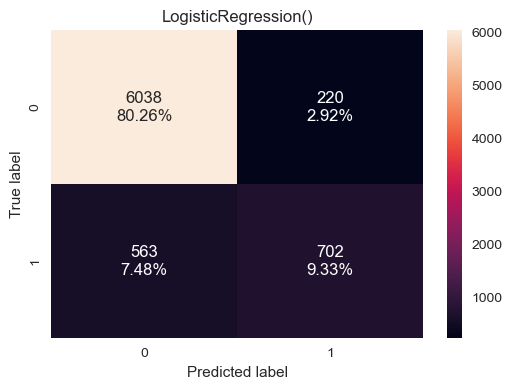

In [256]:
lr_confusion_matrix(model1,X_train,y_train)
plt.show()

In [257]:
LR_model1_train_performance=lr_performance_classification(model1,X_train,y_train,threshold=0.5)
LR_model1_train_performance

,Accuracy,Recall,Precision,F1
0,89.59,55.49,76.14,64.20


#### validation performance

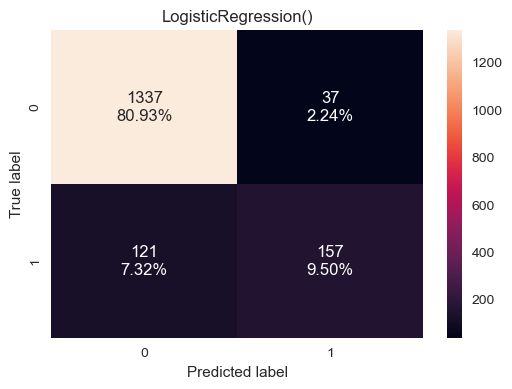

In [258]:
lr_confusion_matrix(model1,X_val,y_val)
plt.show()

In [259]:
LR_model1_validatiion_performance=lr_performance_classification(model1,X_val,y_val,threshold=0.5)
LR_model1_validatiion_performance

,Accuracy,Recall,Precision,F1
0,90.44,56.47,80.93,66.53


In [260]:
Logistic_actual_data=pd.concat([LR_model1_train_performance,LR_model1_validatiion_performance]).T
Logistic_actual_data.columns=['LR_Train','LR_Validation']
Logistic_actual_data

,LR_Train,LR_Validation
Accuracy,89.59,90.44
Recall,55.49,56.47
Precision,76.14,80.93
F1,64.20,66.53


#### ROC AUC

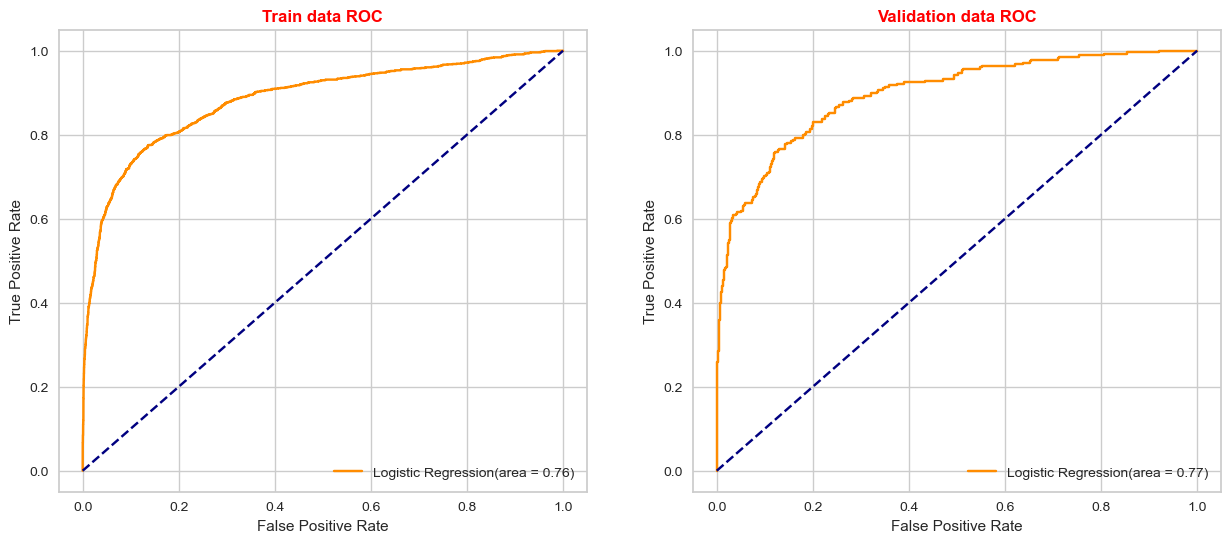

In [261]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))

train_roc = roc_auc_score(y_train, model1.predict(X_train))
fpr, tpr, thresholds = roc_curve(y_train, model1.predict_proba(X_train)[:, 1])

ax1.plot(fpr, tpr, color='darkorange',label="Logistic Regression(area = %0.2f)" % train_roc)
ax1.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Train data ROC",fontweight='bold',color='red')
ax1.legend(loc="lower right")


val_roc = roc_auc_score(y_val, model1.predict(X_val))
fpr, tpr, thresholds = roc_curve(y_val, model1.predict_proba(X_val)[:, 1])

ax2.plot(fpr, tpr, color='darkorange',label="Logistic Regression(area = %0.2f)" % val_roc)
ax2.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Validation data ROC",fontweight='bold',color='red')
ax2.legend(loc="lower right")

plt.show()

#### Cross validation

In [262]:
scores = cross_validate(model1, X_train, y_train, scoring=['accuracy','precision', 'recall', 'f1'], cv=skf)
cv_score=pd.DataFrame(scores).iloc[:,2:]
cv_score.mean()

test_accuracy    0.90
test_precision   0.76
test_recall      0.56
test_f1          0.64
dtype: float64

In [263]:
Logistic_actual_data

,LR_Train,LR_Validation
Accuracy,89.59,90.44
Recall,55.49,56.47
Precision,76.14,80.93
F1,64.20,66.53


### 2 Naive Bayes

In [264]:
model2=GaussianNB()

In [265]:
model2=model2.fit(X_train,y_train)

#### Train Performance

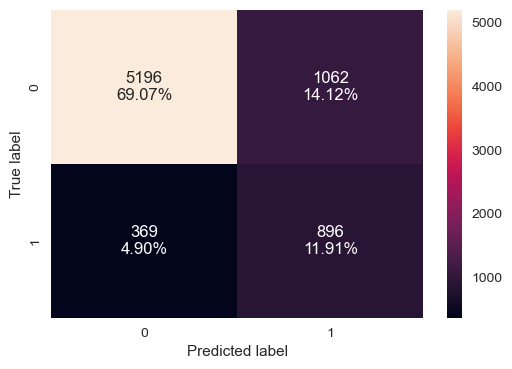

In [266]:
model_confusion_matrix(model2,X_train,y_train)
plt.show()

In [267]:
NB_model_train_performance=model_performance_classification(model2,X_train,y_train)
NB_model_train_performance

,Accuracy,Recall,Precision,F1
0,80.98,70.83,45.76,55.60


#### validation performance

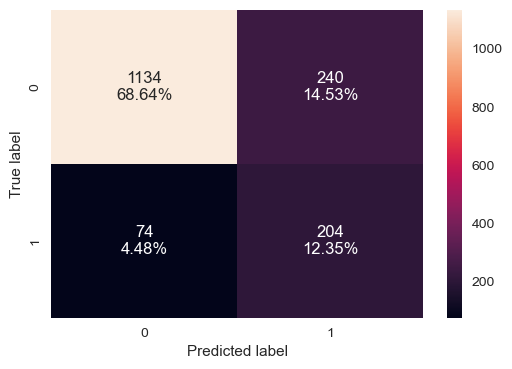

In [268]:
model_confusion_matrix(model2,X_val,y_val)
plt.show()

In [269]:
NB_model_validatiion_performance=model_performance_classification(model2,X_val,y_val)
NB_model_validatiion_performance

,Accuracy,Recall,Precision,F1
0,80.99,73.38,45.95,56.51


In [270]:
NB_actual_data=pd.concat([NB_model_train_performance,NB_model_validatiion_performance]).T
NB_actual_data.columns=['NB_Train','NB_Validation']
NB_actual_data

,NB_Train,NB_Validation
Accuracy,80.98,80.99
Recall,70.83,73.38
Precision,45.76,45.95
F1,55.60,56.51


#### ROC AUC

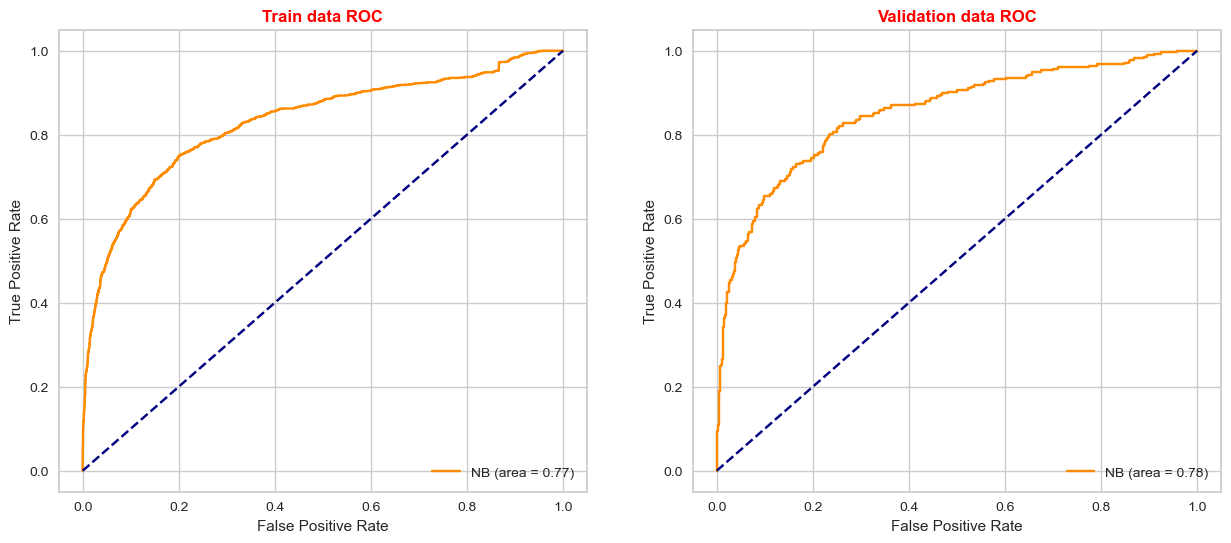

In [271]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))

train_roc = roc_auc_score(y_train, model2.predict(X_train))
fpr, tpr, thresholds = roc_curve(y_train, model2.predict_proba(X_train)[:, 1])

ax1.plot(fpr, tpr, color='darkorange',label="NB (area = %0.2f)" % train_roc)
ax1.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Train data ROC",fontweight='bold',color='red')
ax1.legend(loc="lower right")


val_roc = roc_auc_score(y_val, model2.predict(X_val))
fpr, tpr, thresholds = roc_curve(y_val, model2.predict_proba(X_val)[:, 1])

ax2.plot(fpr, tpr, color='darkorange',label="NB (area = %0.2f)" % val_roc)
ax2.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Validation data ROC",fontweight='bold',color='red')
ax2.legend(loc="lower right")

plt.show()

#### Cross validation

In [272]:
scores = cross_validate(model2, X_train, y_train, scoring=['accuracy','precision', 'recall', 'f1'], cv=skf)
cv_score=pd.DataFrame(scores).iloc[:,2:]
cv_score.mean()

test_accuracy    0.81
test_precision   0.45
test_recall      0.71
test_f1          0.55
dtype: float64

In [273]:
NB_actual_data

,NB_Train,NB_Validation
Accuracy,80.98,80.99
Recall,70.83,73.38
Precision,45.76,45.95
F1,55.60,56.51


### 3 LDA

In [274]:
model3=LinearDiscriminantAnalysis()

In [275]:
model3=model3.fit(X_train,y_train)

#### Train Performance

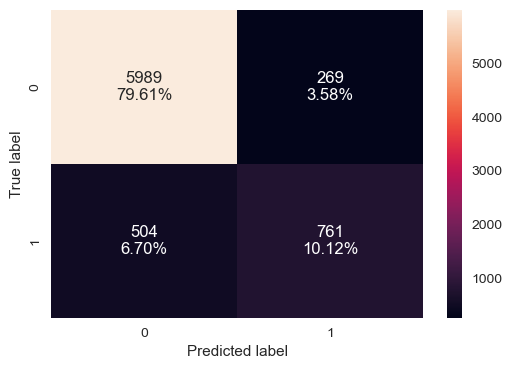

In [276]:
model_confusion_matrix(model3,X_train,y_train)
plt.show()

In [277]:
LDA_model_train_performance=model_performance_classification(model3,X_train,y_train)
LDA_model_train_performance

,Accuracy,Recall,Precision,F1
0,89.72,60.16,73.88,66.32


#### validation performance

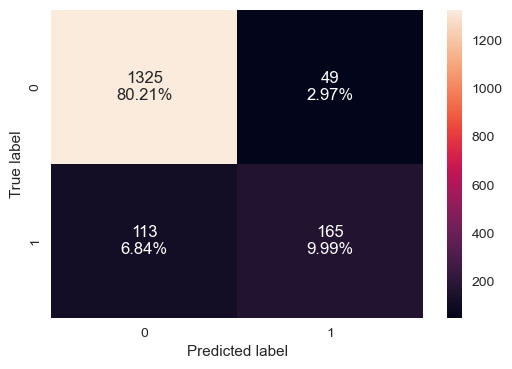

In [278]:
model_confusion_matrix(model3,X_val,y_val)
plt.show()

In [279]:
LDA_model_validatiion_performance=model_performance_classification(model3,X_val,y_val)
LDA_model_validatiion_performance

,Accuracy,Recall,Precision,F1
0,90.19,59.35,77.10,67.07


In [280]:
LDA_actual_data=pd.concat([LDA_model_train_performance,LDA_model_validatiion_performance]).T
LDA_actual_data.columns=['LDA_Train','LDA_Validation']
LDA_actual_data

,LDA_Train,LDA_Validation
Accuracy,89.72,90.19
Recall,60.16,59.35
Precision,73.88,77.10
F1,66.32,67.07


#### ROC AUC

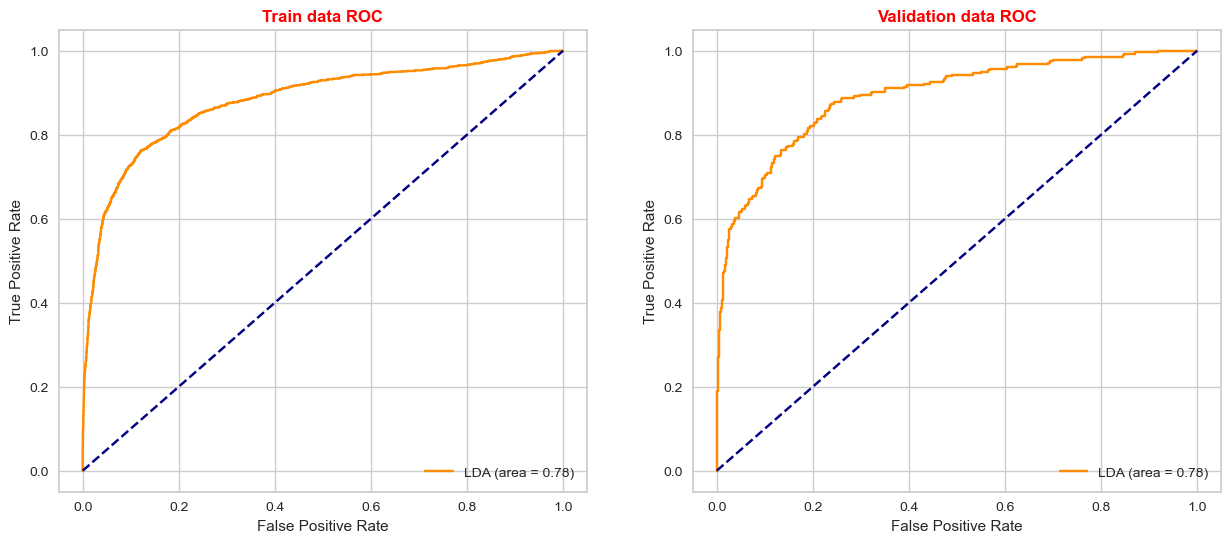

In [281]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))

train_roc = roc_auc_score(y_train, model3.predict(X_train))
fpr, tpr, thresholds = roc_curve(y_train, model3.predict_proba(X_train)[:, 1])

ax1.plot(fpr, tpr, color='darkorange',label="LDA (area = %0.2f)" % train_roc)
ax1.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Train data ROC",fontweight='bold',color='red')
ax1.legend(loc="lower right")


val_roc = roc_auc_score(y_val, model3.predict(X_val))
fpr, tpr, thresholds = roc_curve(y_val, model3.predict_proba(X_val)[:, 1])

ax2.plot(fpr, tpr, color='darkorange',label="LDA (area = %0.2f)" % val_roc)
ax2.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Validation data ROC",fontweight='bold',color='red')
ax2.legend(loc="lower right")

plt.show()

#### Cross validation

In [282]:
scores = cross_validate(model3, X_train, y_train, scoring=['accuracy','precision', 'recall', 'f1'], cv=skf)
cv_score=pd.DataFrame(scores).iloc[:,2:]
cv_score.mean()

test_accuracy    0.90
test_precision   0.73
test_recall      0.60
test_f1          0.66
dtype: float64

In [283]:
LDA_actual_data

,LDA_Train,LDA_Validation
Accuracy,89.72,90.19
Recall,60.16,59.35
Precision,73.88,77.10
F1,66.32,67.07


## Non-Parametric Models

### 4 KNN Classifier

In [284]:
model4=KNeighborsClassifier(n_neighbors=5)

In [285]:
model4=model4.fit(X_train,y_train)

#### Train Performance

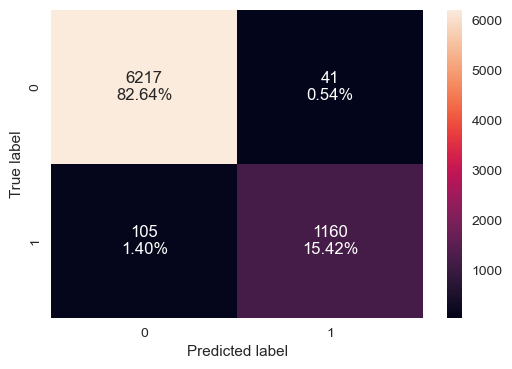

In [286]:
model_confusion_matrix(model4,X_train,y_train)
plt.show()

In [287]:
KNN_model_train_performance=model_performance_classification(model4,X_train,y_train)
KNN_model_train_performance

,Accuracy,Recall,Precision,F1
0,98.06,91.70,96.59,94.08


#### validation performance

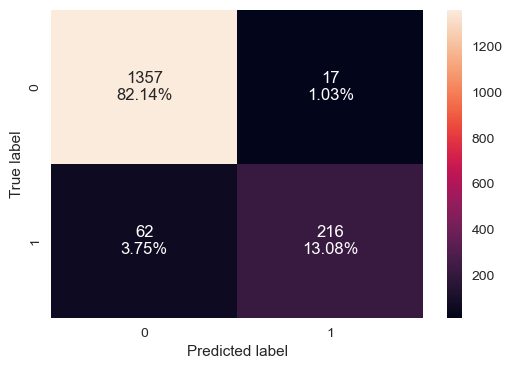

In [288]:
model_confusion_matrix(model4,X_val,y_val)
plt.show()

In [289]:
KNN_model_validatiion_performance=model_performance_classification(model4,X_val,y_val)
KNN_model_validatiion_performance

,Accuracy,Recall,Precision,F1
0,95.22,77.70,92.70,84.54


In [290]:
KNN_actual_data=pd.concat([KNN_model_train_performance,KNN_model_validatiion_performance]).T
KNN_actual_data.columns=['KNN_Train','KNN_Validation']
KNN_actual_data

,KNN_Train,KNN_Validation
Accuracy,98.06,95.22
Recall,91.70,77.70
Precision,96.59,92.70
F1,94.08,84.54


#### ROC AUC

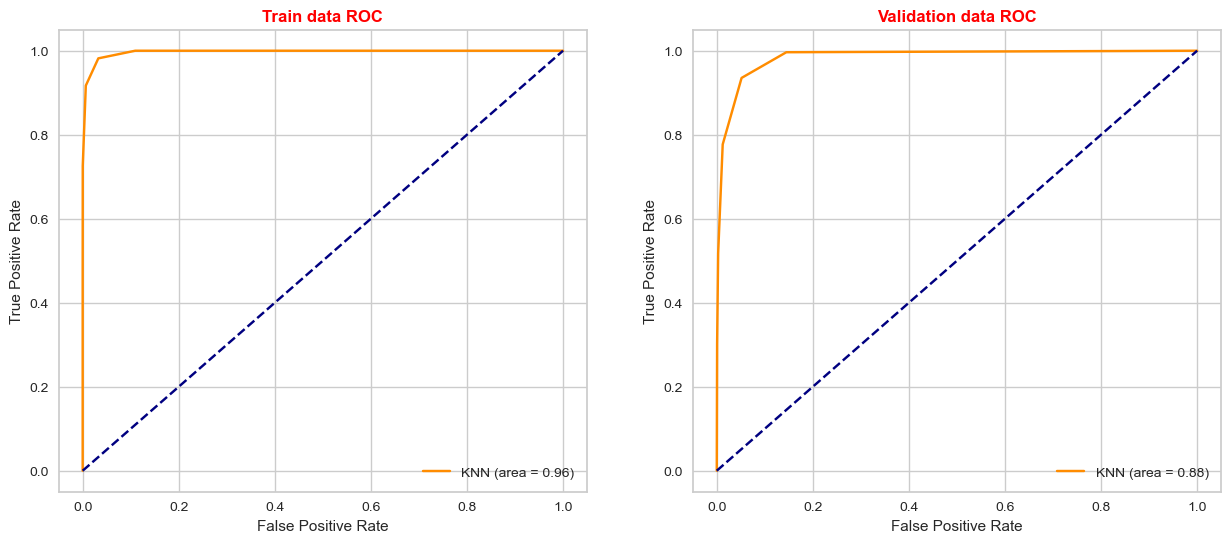

In [291]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))

train_roc = roc_auc_score(y_train, model4.predict(X_train))
fpr, tpr, thresholds = roc_curve(y_train, model4.predict_proba(X_train)[:, 1])

ax1.plot(fpr, tpr, color='darkorange',label="KNN (area = %0.2f)" % train_roc)
ax1.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Train data ROC",fontweight='bold',color='red')
ax1.legend(loc="lower right")


val_roc = roc_auc_score(y_val, model4.predict(X_val))
fpr, tpr, thresholds = roc_curve(y_val, model4.predict_proba(X_val)[:, 1])

ax2.plot(fpr, tpr, color='darkorange',label="KNN (area = %0.2f)" % val_roc)
ax2.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Validation data ROC",fontweight='bold',color='red')
ax2.legend(loc="lower right")

plt.show()

#### Cross validation

In [292]:
scores = cross_validate(model4, X_train, y_train, scoring=['accuracy','precision', 'recall', 'f1'], cv=skf)
cv_score=pd.DataFrame(scores).iloc[:,2:]
cv_score.mean()

test_accuracy    0.94
test_precision   0.90
test_recall      0.73
test_f1          0.81
dtype: float64

In [293]:
KNN_actual_data

,KNN_Train,KNN_Validation
Accuracy,98.06,95.22
Recall,91.70,77.70
Precision,96.59,92.70
F1,94.08,84.54


### 5 Decision Tree Classifier

In [294]:
model5=DecisionTreeClassifier(random_state=1)

In [295]:
model5=model5.fit(X_train,y_train)

#### Train Performance

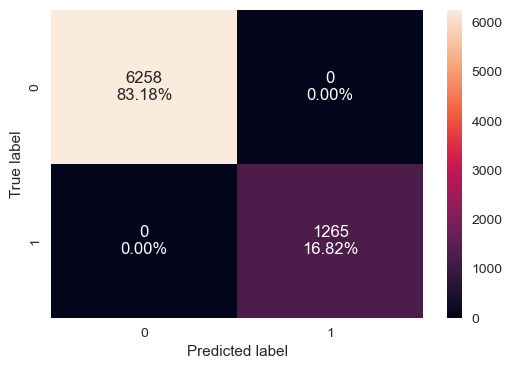

In [296]:
model_confusion_matrix(model5,X_train,y_train)
plt.show()

In [297]:
DT_model_train_performance=model_performance_classification(model5,X_train,y_train)
DT_model_train_performance

,Accuracy,Recall,Precision,F1
0,100.00,100.00,100.00,100.00


#### validation performance

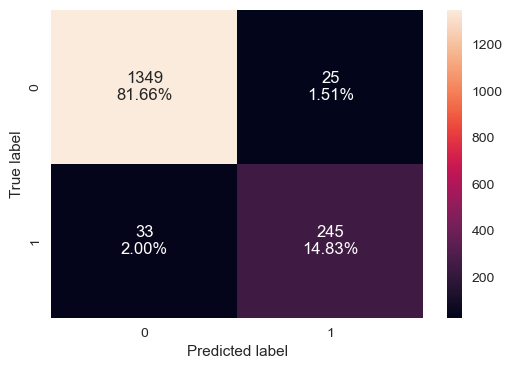

In [298]:
model_confusion_matrix(model5,X_val,y_val)
plt.show()

In [299]:
DT_model_validatiion_performance=model_performance_classification(model5,X_val,y_val)
DT_model_validatiion_performance

,Accuracy,Recall,Precision,F1
0,96.49,88.13,90.74,89.42


In [300]:
DT_actual_data=pd.concat([DT_model_train_performance,DT_model_validatiion_performance]).T
DT_actual_data.columns=['DT_Train','DT_Validation']
DT_actual_data

,DT_Train,DT_Validation
Accuracy,100.00,96.49
Recall,100.00,88.13
Precision,100.00,90.74
F1,100.00,89.42


#### ROC AUC

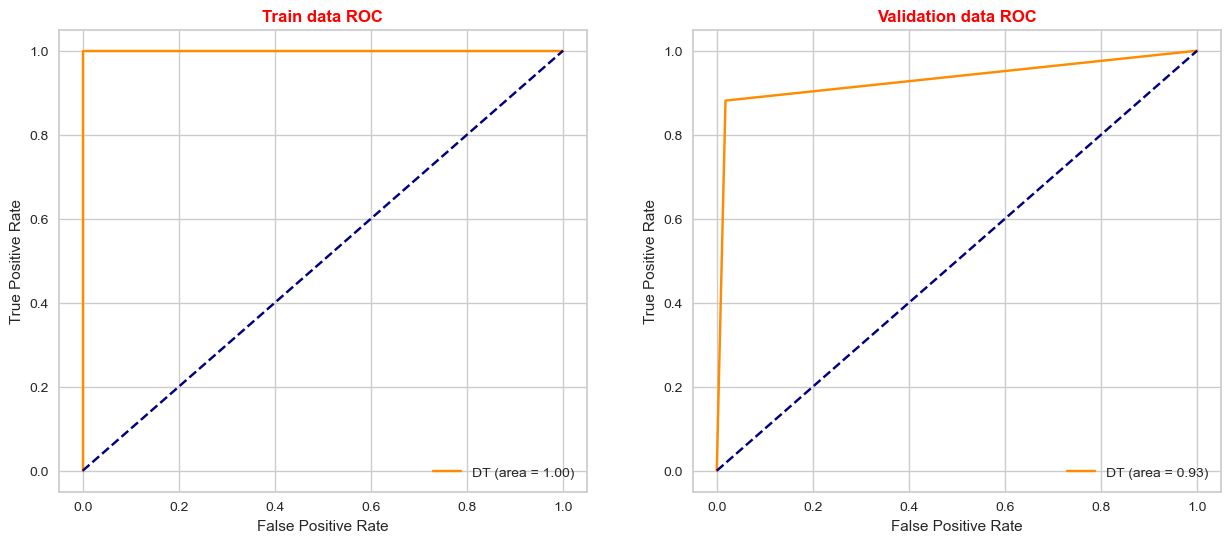

In [301]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))

train_roc = roc_auc_score(y_train, model5.predict(X_train))
fpr, tpr, thresholds = roc_curve(y_train, model5.predict_proba(X_train)[:, 1])

ax1.plot(fpr, tpr, color='darkorange',label="DT (area = %0.2f)" % train_roc)
ax1.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Train data ROC",fontweight='bold',color='red')
ax1.legend(loc="lower right")


val_roc = roc_auc_score(y_val, model5.predict(X_val))
fpr, tpr, thresholds = roc_curve(y_val, model5.predict_proba(X_val)[:, 1])

ax2.plot(fpr, tpr, color='darkorange',label="DT (area = %0.2f)" % val_roc)
ax2.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Validation data ROC",fontweight='bold',color='red')
ax2.legend(loc="lower right")

plt.show()

#### Cross validation

In [302]:
scores = cross_validate(model5, X_train, y_train, scoring=['accuracy','precision', 'recall', 'f1'], cv=skf)
cv_score=pd.DataFrame(scores).iloc[:,2:]
cv_score.mean()

test_accuracy    0.95
test_precision   0.86
test_recall      0.86
test_f1          0.86
dtype: float64

In [303]:
DT_actual_data

,DT_Train,DT_Validation
Accuracy,100.00,96.49
Recall,100.00,88.13
Precision,100.00,90.74
F1,100.00,89.42


### 6 Bagging Classifier

In [304]:
model6=BaggingClassifier(random_state=1)

In [305]:
model6=model6.fit(X_train,y_train)

#### Train Performance

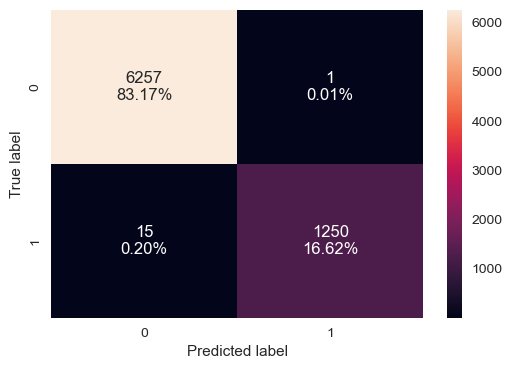

In [306]:
model_confusion_matrix(model6,X_train,y_train)
plt.show()

In [307]:
Bag_model_train_performance=model_performance_classification(model6,X_train,y_train)
Bag_model_train_performance

,Accuracy,Recall,Precision,F1
0,99.79,98.81,99.92,99.36


#### validation performance

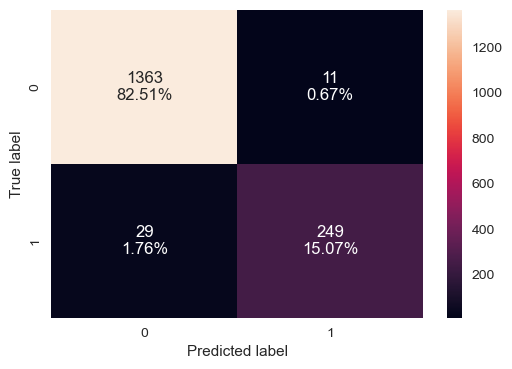

In [308]:
model_confusion_matrix(model6,X_val,y_val)
plt.show()

In [309]:
Bag_model_validatiion_performance=model_performance_classification(model6,X_val,y_val)
Bag_model_validatiion_performance

,Accuracy,Recall,Precision,F1
0,97.58,89.57,95.77,92.57


In [310]:
Bag_actual_data=pd.concat([Bag_model_train_performance,Bag_model_validatiion_performance]).T
Bag_actual_data.columns=['Bag_Train','Bag_Validation']
Bag_actual_data

,Bag_Train,Bag_Validation
Accuracy,99.79,97.58
Recall,98.81,89.57
Precision,99.92,95.77
F1,99.36,92.57


#### ROC AUC

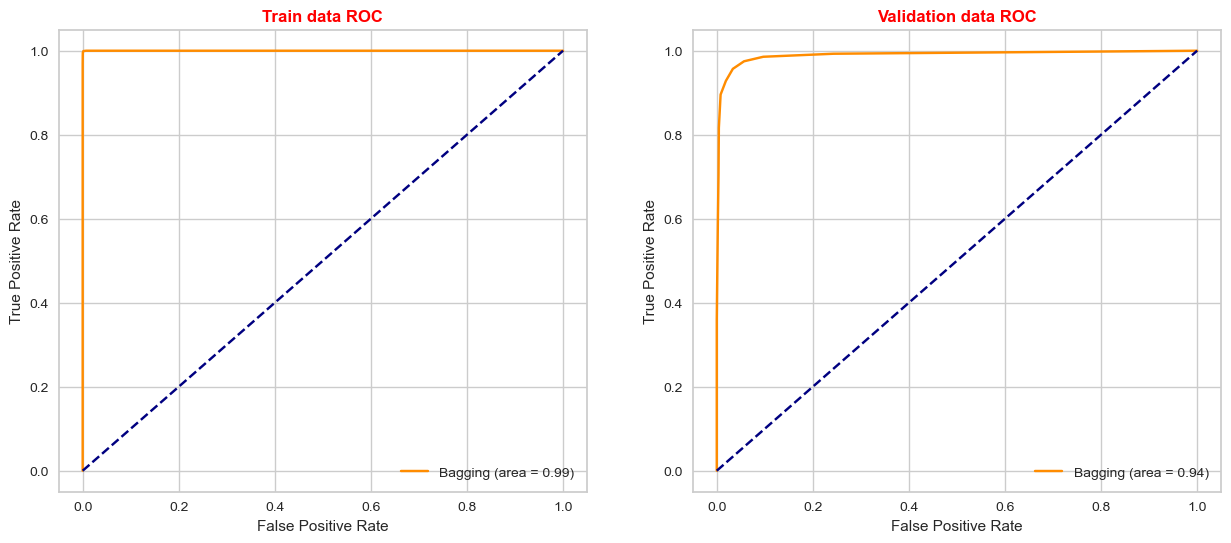

In [311]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))

train_roc = roc_auc_score(y_train, model6.predict(X_train))
fpr, tpr, thresholds = roc_curve(y_train, model6.predict_proba(X_train)[:, 1])

ax1.plot(fpr, tpr, color='darkorange',label="Bagging (area = %0.2f)" % train_roc)
ax1.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Train data ROC",fontweight='bold',color='red')
ax1.legend(loc="lower right")


val_roc = roc_auc_score(y_val, model6.predict(X_val))
fpr, tpr, thresholds = roc_curve(y_val, model6.predict_proba(X_val)[:, 1])

ax2.plot(fpr, tpr, color='darkorange',label="Bagging (area = %0.2f)" % val_roc)
ax2.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Validation data ROC",fontweight='bold',color='red')
ax2.legend(loc="lower right")

plt.show()

#### Cross validation

In [312]:
scores = cross_validate(model6, X_train, y_train, scoring=['accuracy','precision', 'recall', 'f1'], cv=skf)
cv_score=pd.DataFrame(scores).iloc[:,2:]
cv_score.mean()

test_accuracy    0.96
test_precision   0.94
test_recall      0.82
test_f1          0.88
dtype: float64

In [313]:
Bag_actual_data

,Bag_Train,Bag_Validation
Accuracy,99.79,97.58
Recall,98.81,89.57
Precision,99.92,95.77
F1,99.36,92.57


### 7 Random Forest Classifier

In [314]:
model7=RandomForestClassifier(random_state=1)

In [315]:
model7=model7.fit(X_train,y_train)

#### Train Performance

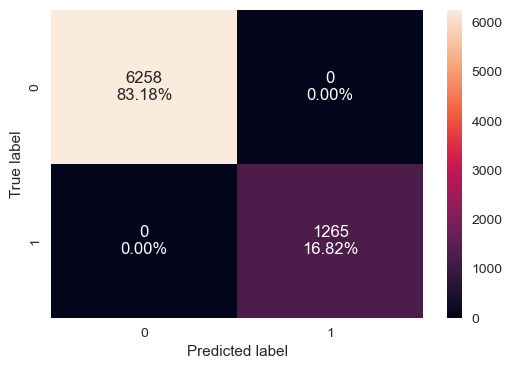

In [316]:
model_confusion_matrix(model7,X_train,y_train)
plt.show()

In [317]:
RF_model_train_performance=model_performance_classification(model7,X_train,y_train)
RF_model_train_performance

,Accuracy,Recall,Precision,F1
0,100.00,100.00,100.00,100.00


#### validation performance

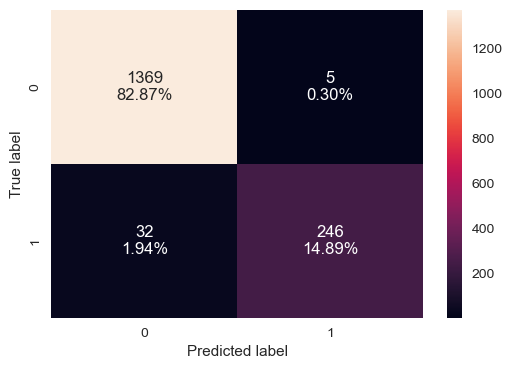

In [318]:
model_confusion_matrix(model7,X_val,y_val)
plt.show()

In [319]:
RF_model_validatiion_performance=model_performance_classification(model7,X_val,y_val)
RF_model_validatiion_performance

,Accuracy,Recall,Precision,F1
0,97.76,88.49,98.01,93.01


In [320]:
RF_actual_data=pd.concat([RF_model_train_performance,RF_model_validatiion_performance]).T
RF_actual_data.columns=['RF_Train','RF_Validation']
RF_actual_data

,RF_Train,RF_Validation
Accuracy,100.00,97.76
Recall,100.00,88.49
Precision,100.00,98.01
F1,100.00,93.01


#### ROC AUC

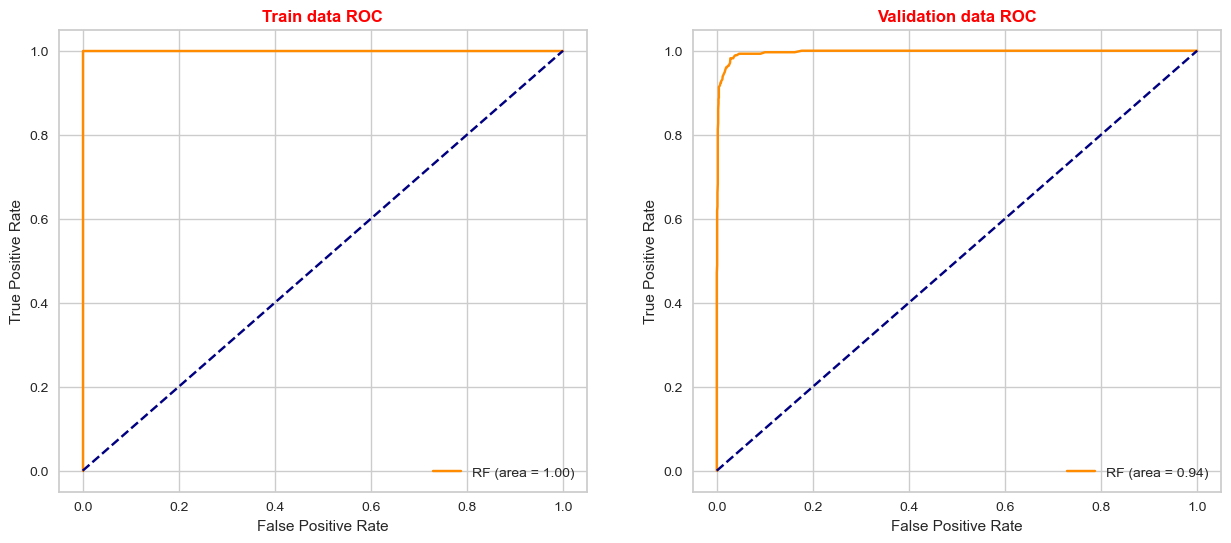

In [321]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))

train_roc = roc_auc_score(y_train, model7.predict(X_train))
fpr, tpr, thresholds = roc_curve(y_train, model7.predict_proba(X_train)[:, 1])

ax1.plot(fpr, tpr, color='darkorange',label="RF (area = %0.2f)" % train_roc)
ax1.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Train data ROC",fontweight='bold',color='red')
ax1.legend(loc="lower right")


val_roc = roc_auc_score(y_val, model7.predict(X_val))
fpr, tpr, thresholds = roc_curve(y_val, model7.predict_proba(X_val)[:, 1])

ax2.plot(fpr, tpr, color='darkorange',label="RF (area = %0.2f)" % val_roc)
ax2.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Validation data ROC",fontweight='bold',color='red')
ax2.legend(loc="lower right")

plt.show()

#### Cross validation

In [322]:
scores = cross_validate(model7, X_train, y_train, scoring=['accuracy','precision', 'recall', 'f1'], cv=skf)
cv_score=pd.DataFrame(scores).iloc[:,2:]
cv_score.mean()

test_accuracy    0.97
test_precision   0.96
test_recall      0.83
test_f1          0.89
dtype: float64

In [323]:
RF_actual_data

,RF_Train,RF_Validation
Accuracy,100.00,97.76
Recall,100.00,88.49
Precision,100.00,98.01
F1,100.00,93.01


### 8 AdaBoost Classifier

In [324]:
model8=AdaBoostClassifier(random_state=1)

In [325]:
model8=model8.fit(X_train,y_train)

#### Train Performance

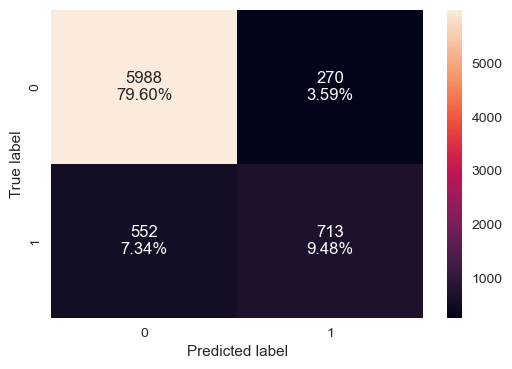

In [326]:
model_confusion_matrix(model8,X_train,y_train)
plt.show()

In [327]:
AB_model_train_performance=model_performance_classification(model8,X_train,y_train)
AB_model_train_performance

,Accuracy,Recall,Precision,F1
0,89.07,56.36,72.53,63.43


#### validation performance

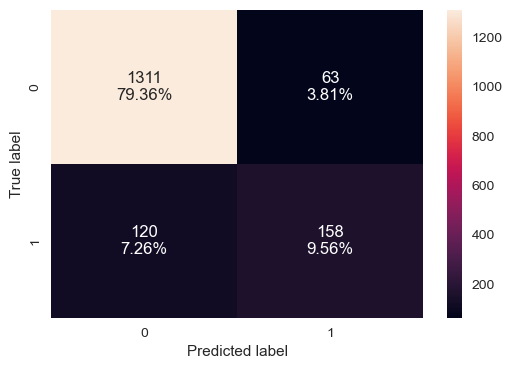

In [328]:
model_confusion_matrix(model8,X_val,y_val)
plt.show()

In [329]:
AB_model_validatiion_performance=model_performance_classification(model8,X_val,y_val)
AB_model_validatiion_performance

,Accuracy,Recall,Precision,F1
0,88.92,56.83,71.49,63.33


In [330]:
AB_actual_data=pd.concat([AB_model_train_performance,AB_model_validatiion_performance]).T
AB_actual_data.columns=['AB_Train','AB_Validation']
AB_actual_data

,AB_Train,AB_Validation
Accuracy,89.07,88.92
Recall,56.36,56.83
Precision,72.53,71.49
F1,63.43,63.33


#### ROC AUC

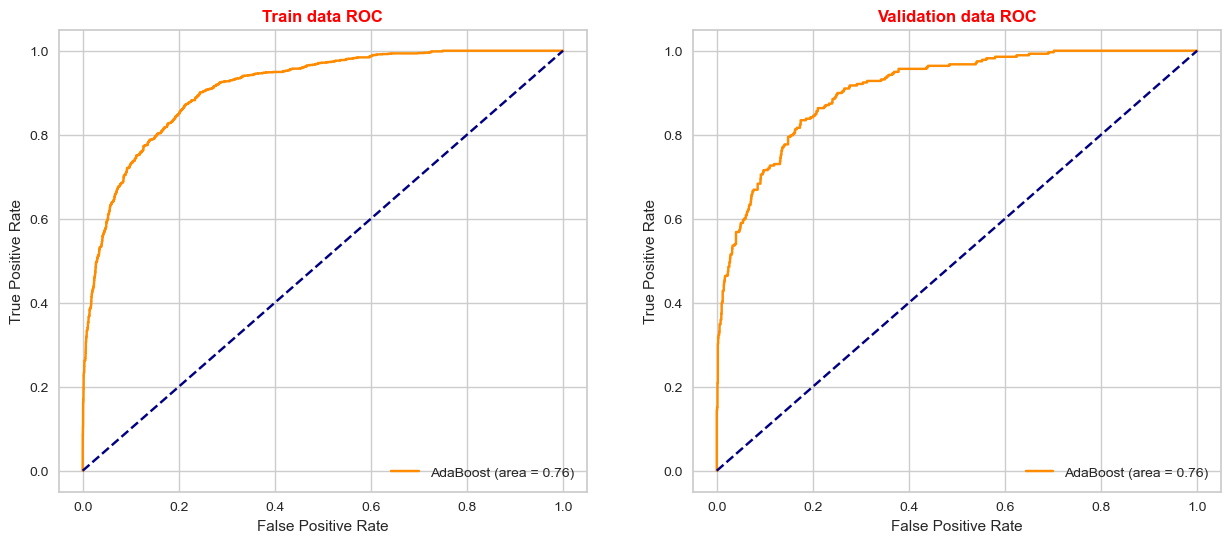

In [331]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))

train_roc = roc_auc_score(y_train, model8.predict(X_train))
fpr, tpr, thresholds = roc_curve(y_train, model8.predict_proba(X_train)[:, 1])

ax1.plot(fpr, tpr, color='darkorange',label="AdaBoost (area = %0.2f)" % train_roc)
ax1.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Train data ROC",fontweight='bold',color='red')
ax1.legend(loc="lower right")


val_roc = roc_auc_score(y_val, model8.predict(X_val))
fpr, tpr, thresholds = roc_curve(y_val, model8.predict_proba(X_val)[:, 1])

ax2.plot(fpr, tpr, color='darkorange',label="AdaBoost (area = %0.2f)" % val_roc)
ax2.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Validation data ROC",fontweight='bold',color='red')
ax2.legend(loc="lower right")

plt.show()

#### Cross validation

In [332]:
scores = cross_validate(model8, X_train, y_train, scoring=['accuracy','precision', 'recall', 'f1'], cv=skf)
cv_score=pd.DataFrame(scores).iloc[:,2:]
cv_score.mean()

test_accuracy    0.89
test_precision   0.71
test_recall      0.56
test_f1          0.63
dtype: float64

In [333]:
AB_actual_data

,AB_Train,AB_Validation
Accuracy,89.07,88.92
Recall,56.36,56.83
Precision,72.53,71.49
F1,63.43,63.33


### 9 Gradient Boosting Classifier

In [334]:
model9=GradientBoostingClassifier(random_state=1)

In [335]:
model9=model9.fit(X_train,y_train)

#### Train Performance

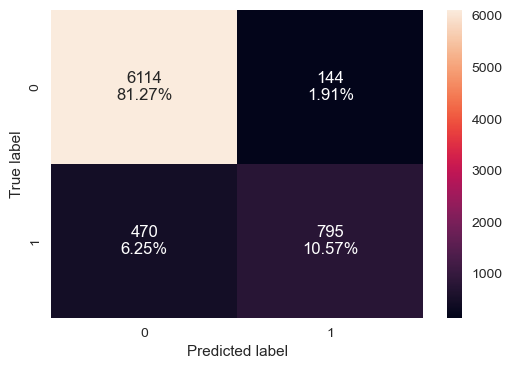

In [336]:
model_confusion_matrix(model9,X_train,y_train)
plt.show()

In [337]:
GB_model_train_performance=model_performance_classification(model9,X_train,y_train)
GB_model_train_performance

,Accuracy,Recall,Precision,F1
0,91.84,62.85,84.66,72.14


#### validation performance

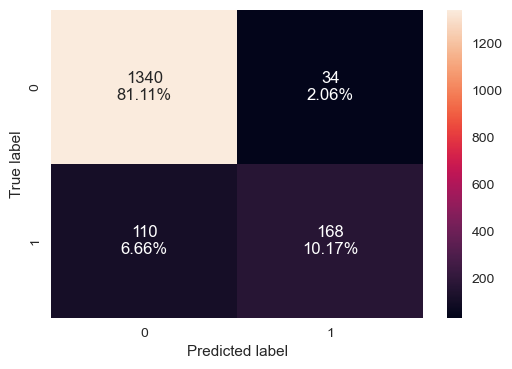

In [338]:
model_confusion_matrix(model9,X_val,y_val)
plt.show()

In [339]:
GB_model_validatiion_performance=model_performance_classification(model9,X_val,y_val)
GB_model_validatiion_performance

,Accuracy,Recall,Precision,F1
0,91.28,60.43,83.17,70.00


In [340]:
GB_actual_data=pd.concat([GB_model_train_performance,GB_model_validatiion_performance]).T
GB_actual_data.columns=['GB_Train','GB_Validation']
GB_actual_data

,GB_Train,GB_Validation
Accuracy,91.84,91.28
Recall,62.85,60.43
Precision,84.66,83.17
F1,72.14,70.00


#### ROC AUC

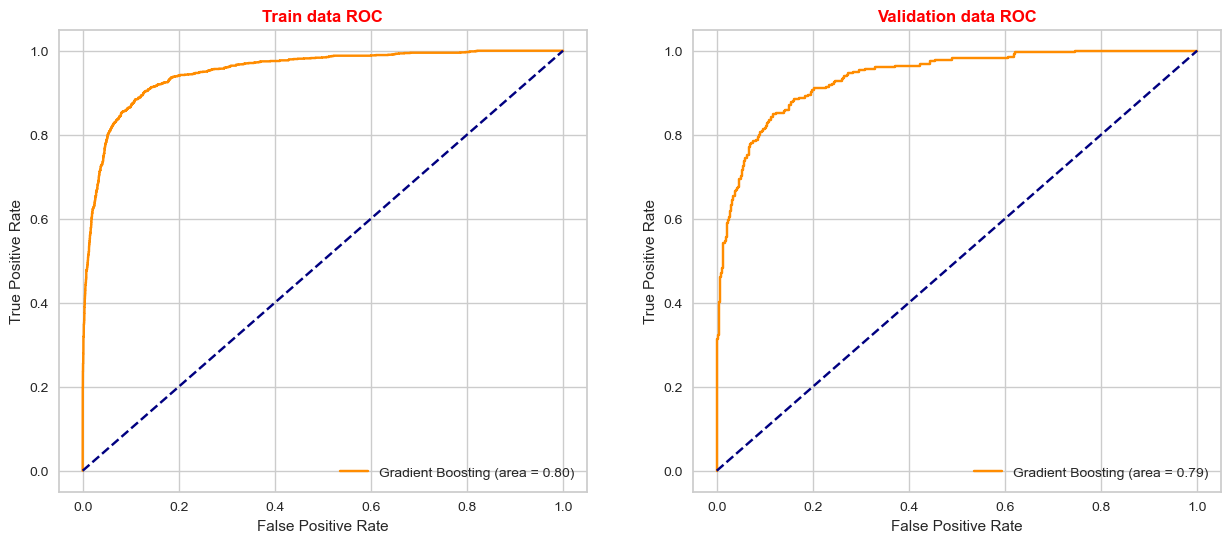

In [341]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))

train_roc = roc_auc_score(y_train, model9.predict(X_train))
fpr, tpr, thresholds = roc_curve(y_train, model9.predict_proba(X_train)[:, 1])

ax1.plot(fpr, tpr, color='darkorange',label="Gradient Boosting (area = %0.2f)" % train_roc)
ax1.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Train data ROC",fontweight='bold',color='red')
ax1.legend(loc="lower right")


val_roc = roc_auc_score(y_val, model9.predict(X_val))
fpr, tpr, thresholds = roc_curve(y_val, model9.predict_proba(X_val)[:, 1])

ax2.plot(fpr, tpr, color='darkorange',label="Gradient Boosting (area = %0.2f)" % val_roc)
ax2.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Validation data ROC",fontweight='bold',color='red')
ax2.legend(loc="lower right")

plt.show()

#### Cross validation

In [342]:
scores = cross_validate(model9, X_train, y_train, scoring=['accuracy','precision', 'recall', 'f1'], cv=skf)
cv_score=pd.DataFrame(scores).iloc[:,2:]
cv_score.mean()

test_accuracy    0.91
test_precision   0.80
test_recall      0.60
test_f1          0.68
dtype: float64

In [343]:
GB_actual_data

,GB_Train,GB_Validation
Accuracy,91.84,91.28
Recall,62.85,60.43
Precision,84.66,83.17
F1,72.14,70.00


### 10 XGBoost Classifier

In [344]:
model10=XGBClassifier(random_state=1)

In [345]:
model10=model10.fit(X_train,y_train)

#### Train Performance

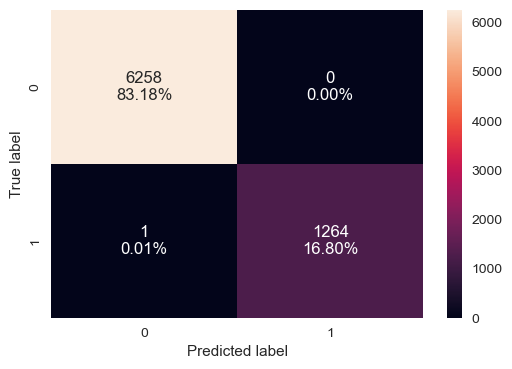

In [346]:
model_confusion_matrix(model10,X_train,y_train)
plt.show()

In [347]:
XGB_model_train_performance=model_performance_classification(model10,X_train,y_train)
XGB_model_train_performance

,Accuracy,Recall,Precision,F1
0,99.99,99.92,100.00,99.96


#### validation performance

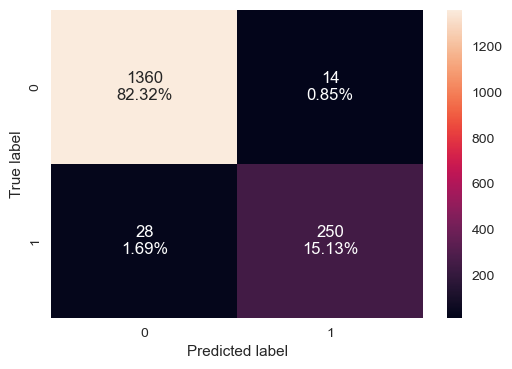

In [348]:
model_confusion_matrix(model10,X_val,y_val)
plt.show()

In [349]:
XGB_model_validatiion_performance=model_performance_classification(model10,X_val,y_val)
XGB_model_validatiion_performance

,Accuracy,Recall,Precision,F1
0,97.46,89.93,94.70,92.25


In [350]:
XGB_actual_data=pd.concat([XGB_model_train_performance,XGB_model_validatiion_performance]).T
XGB_actual_data.columns=['XGB_Train','XGB_Validation']
XGB_actual_data

,XGB_Train,XGB_Validation
Accuracy,99.99,97.46
Recall,99.92,89.93
Precision,100.00,94.70
F1,99.96,92.25


#### ROC AUC

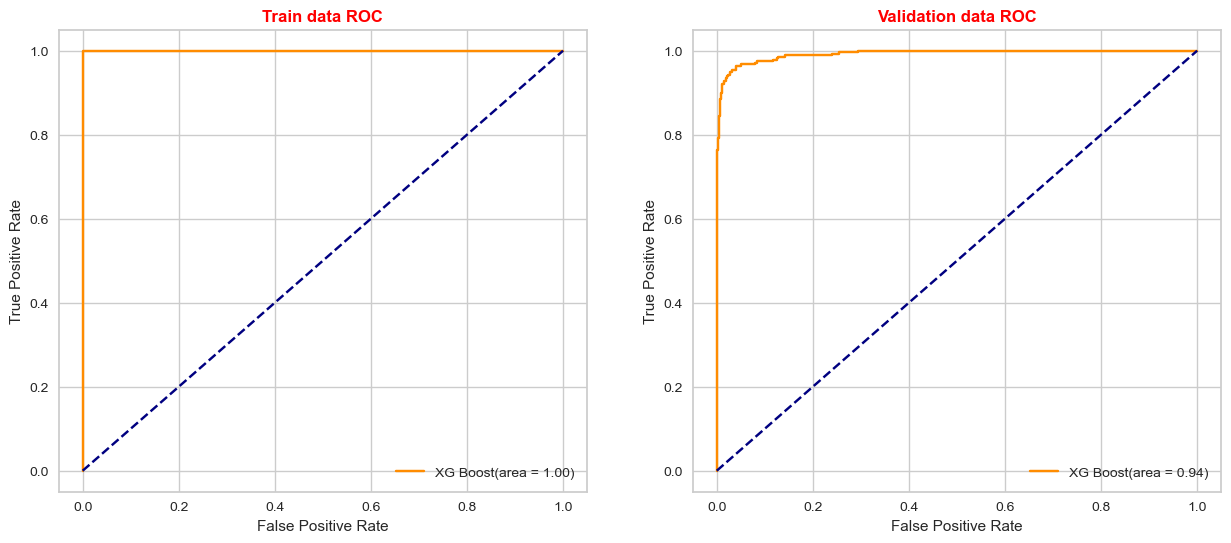

In [351]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))

train_roc = roc_auc_score(y_train, model10.predict(X_train))
fpr, tpr, thresholds = roc_curve(y_train, model10.predict_proba(X_train)[:, 1])

ax1.plot(fpr, tpr, color='darkorange',label="XG Boost(area = %0.2f)" % train_roc)
ax1.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Train data ROC",fontweight='bold',color='red')
ax1.legend(loc="lower right")


val_roc = roc_auc_score(y_val, model10.predict(X_val))
fpr, tpr, thresholds = roc_curve(y_val, model10.predict_proba(X_val)[:, 1])

ax2.plot(fpr, tpr, color='darkorange',label="XG Boost(area = %0.2f)" % val_roc)
ax2.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Validation data ROC",fontweight='bold',color='red')
ax2.legend(loc="lower right")

plt.show()

#### Cross validation

In [352]:
scores = cross_validate(model10, X_train, y_train, scoring=['accuracy','precision', 'recall', 'f1'], cv=skf)
cv_score=pd.DataFrame(scores).iloc[:,2:]
cv_score.mean()

test_accuracy    0.97
test_precision   0.93
test_recall      0.86
test_f1          0.89
dtype: float64

In [353]:
XGB_actual_data

,XGB_Train,XGB_Validation
Accuracy,99.99,97.46
Recall,99.92,89.93
Precision,100.00,94.70
F1,99.96,92.25


### Comparison

In [354]:
Actual_data_performance=Logistic_actual_data.join(NB_actual_data).join(LDA_actual_data).join(KNN_actual_data).join(DT_actual_data).join(Bag_actual_data).join(RF_actual_data).\
join(AB_actual_data).join(GB_actual_data).join(XGB_actual_data)

In [355]:
Actual_data_performance.T

,Accuracy,Recall,Precision,F1
LR_Train,89.59,55.49,76.14,64.20
LR_Validation,90.44,56.47,80.93,66.53
NB_Train,80.98,70.83,45.76,55.60
NB_Validation,80.99,73.38,45.95,56.51
LDA_Train,89.72,60.16,73.88,66.32
LDA_Validation,90.19,59.35,77.10,67.07
KNN_Train,98.06,91.70,96.59,94.08
KNN_Validation,95.22,77.70,92.70,84.54
DT_Train,100.00,100.00,100.00,100.00
DT_Validation,96.49,88.13,90.74,89.42


In [356]:
validation=[]
for i in Actual_data_performance.columns:
    if 'Validation' in i:
        validation.append(i)

In [357]:
Train=[]
for i in Actual_data_performance.columns:
    if 'Train' in i:
        Train.append(i)

In [358]:
Actual_train_perf=Actual_data_performance[Train].T

In [359]:
Actual_train_perf[['Recall']]

,Recall
LR_Train,55.49
NB_Train,70.83
LDA_Train,60.16
KNN_Train,91.70
DT_Train,100.00
Bag_Train,98.81
RF_Train,100.00
AB_Train,56.36
GB_Train,62.85
XGB_Train,99.92


In [360]:
Actual_val_perf=Actual_data_performance[validation].T

# Models on Oversampled Data

## Parametric Models

### 11 Logistic Regression

In [361]:
model11=LogisticRegression()

In [362]:
model11=model11.fit(X_train_os,y_train_os)

#### Train Performance

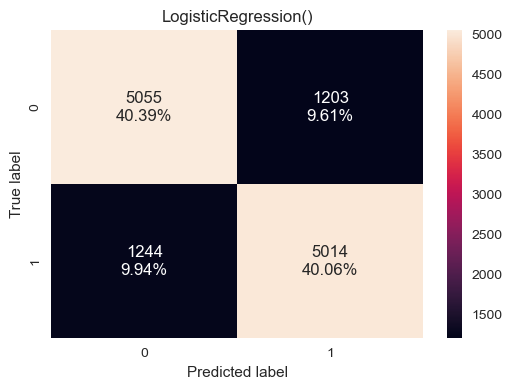

In [363]:
lr_confusion_matrix(model11,X_train_os,y_train_os)
plt.show()

In [364]:
LR_oversampmodel_train_performance=lr_performance_classification(model11,X_train_os,y_train_os,threshold=0.5)
LR_oversampmodel_train_performance

,Accuracy,Recall,Precision,F1
0,80.45,80.12,80.65,80.38


#### validation performance

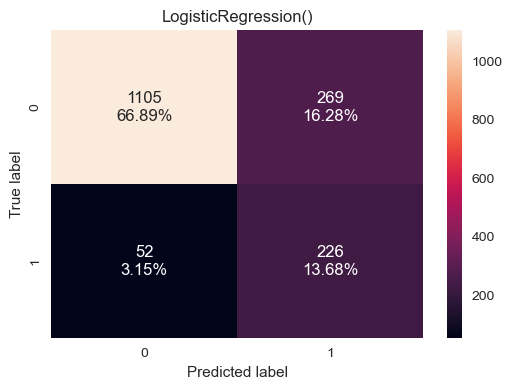

In [365]:
lr_confusion_matrix(model11,X_val,y_val)
plt.show()

In [366]:
LR_oversampmodel_validatiion_performance=lr_performance_classification(model11,X_val,y_val,threshold=0.5)
LR_oversampmodel_validatiion_performance

,Accuracy,Recall,Precision,F1
0,80.57,81.29,45.66,58.47


In [367]:
Logistic_oversamp_data=pd.concat([LR_oversampmodel_train_performance,LR_oversampmodel_validatiion_performance]).T
Logistic_oversamp_data.columns=['LR_oversamp_Train','LR_oversamp_Validation']
Logistic_oversamp_data

,LR_oversamp_Train,LR_oversamp_Validation
Accuracy,80.45,80.57
Recall,80.12,81.29
Precision,80.65,45.66
F1,80.38,58.47


#### ROC AUC

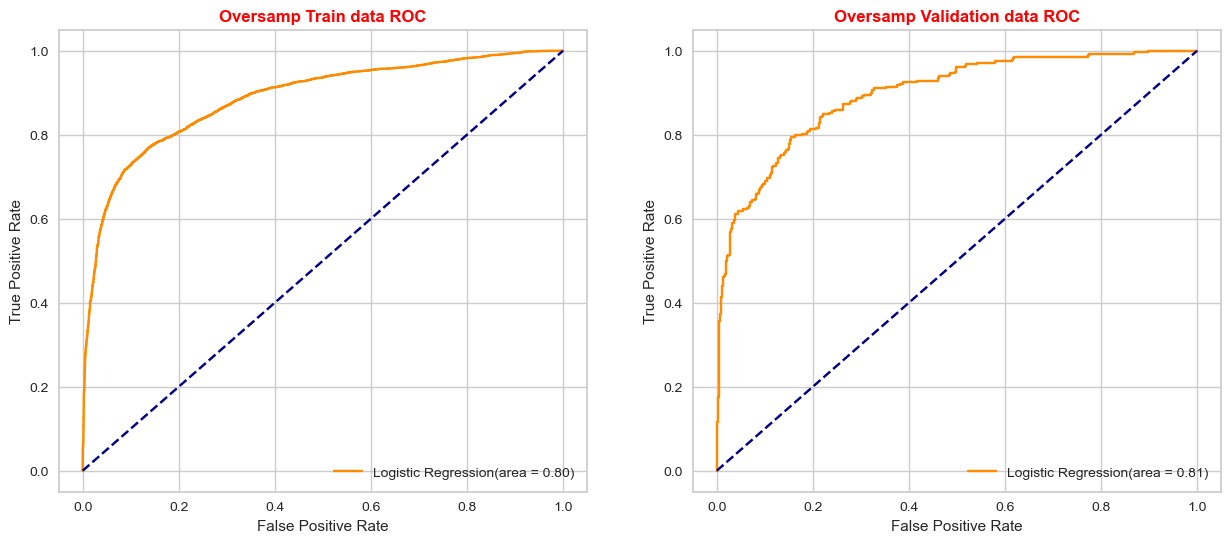

In [368]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))

train_roc = roc_auc_score(y_train_os, model11.predict(X_train_os))
fpr, tpr, thresholds = roc_curve(y_train_os, model11.predict_proba(X_train_os)[:, 1])

ax1.plot(fpr, tpr, color='darkorange',label="Logistic Regression(area = %0.2f)" % train_roc)
ax1.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Oversamp Train data ROC",fontweight='bold',color='red')
ax1.legend(loc="lower right")


val_roc = roc_auc_score(y_val, model11.predict(X_val))
fpr, tpr, thresholds = roc_curve(y_val, model11.predict_proba(X_val)[:, 1])

ax2.plot(fpr, tpr, color='darkorange',label="Logistic Regression(area = %0.2f)" % val_roc)
ax2.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Oversamp Validation data ROC",fontweight='bold',color='red')
ax2.legend(loc="lower right")

plt.show()

#### Cross validation

In [369]:
scores = cross_validate(model11, X_train_os, y_train_os, scoring=['accuracy','precision', 'recall', 'f1'], cv=skf)
cv_score=pd.DataFrame(scores).iloc[:,2:]
cv_score.mean()

test_accuracy    0.80
test_precision   0.81
test_recall      0.80
test_f1          0.80
dtype: float64

In [370]:
Logistic_oversamp_data

,LR_oversamp_Train,LR_oversamp_Validation
Accuracy,80.45,80.57
Recall,80.12,81.29
Precision,80.65,45.66
F1,80.38,58.47


### 12 Naive Bayes

In [371]:
model12=GaussianNB()

In [372]:
model12=model12.fit(X_train_os,y_train_os)

#### Train Performance

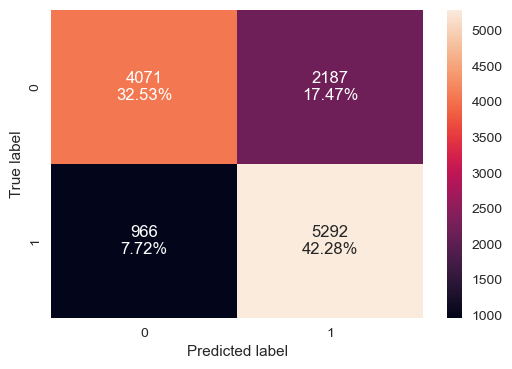

In [373]:
model_confusion_matrix(model12,X_train_os,y_train_os)
plt.show()

In [374]:
NB_oversampmodel_train_performance=model_performance_classification(model12,X_train_os,y_train_os)
NB_oversampmodel_train_performance

,Accuracy,Recall,Precision,F1
0,74.81,84.56,70.76,77.05


#### validation performance

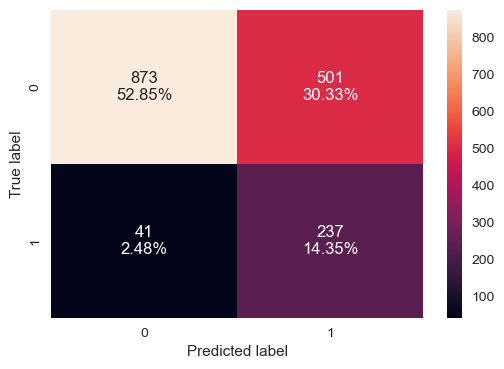

In [375]:
model_confusion_matrix(model12,X_val,y_val)
plt.show()

In [376]:
NB_oversampmodel_validatiion_performance=model_performance_classification(model12,X_val,y_val)
NB_oversampmodel_validatiion_performance

,Accuracy,Recall,Precision,F1
0,67.19,85.25,32.11,46.65


In [377]:
NB_oversamp_data=pd.concat([NB_oversampmodel_train_performance,NB_oversampmodel_validatiion_performance]).T
NB_oversamp_data.columns=['NB_oversamp_Train','NB_oversamp_Validation']
NB_oversamp_data

,NB_oversamp_Train,NB_oversamp_Validation
Accuracy,74.81,67.19
Recall,84.56,85.25
Precision,70.76,32.11
F1,77.05,46.65


#### ROC AUC

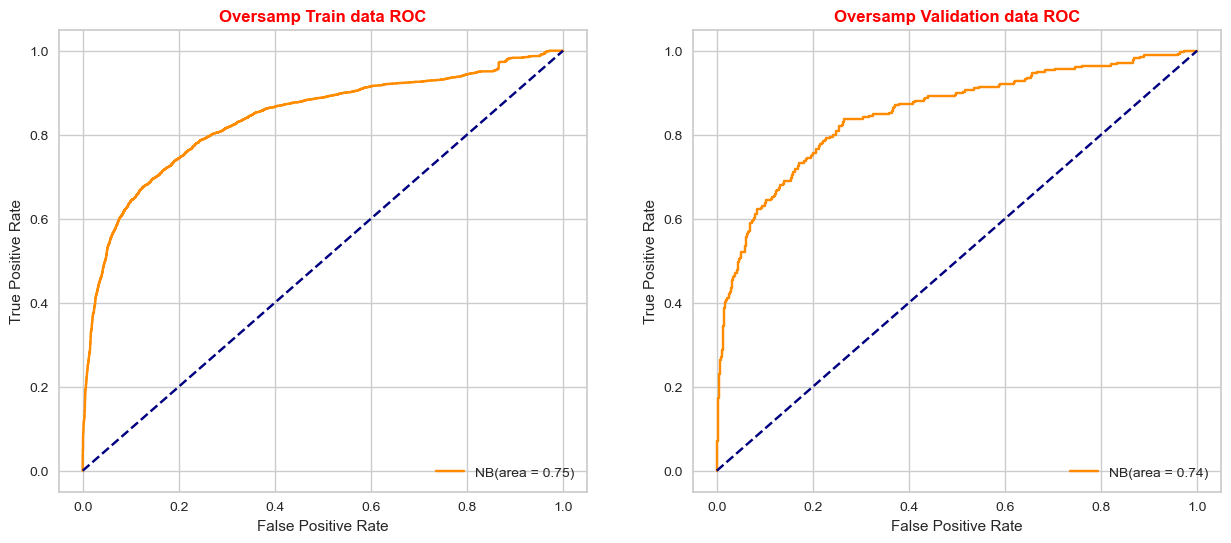

In [378]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))

train_roc = roc_auc_score(y_train_os, model12.predict(X_train_os))
fpr, tpr, thresholds = roc_curve(y_train_os, model12.predict_proba(X_train_os)[:, 1])

ax1.plot(fpr, tpr, color='darkorange',label="NB(area = %0.2f)" % train_roc)
ax1.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Oversamp Train data ROC",fontweight='bold',color='red')
ax1.legend(loc="lower right")


val_roc = roc_auc_score(y_val, model12.predict(X_val))
fpr, tpr, thresholds = roc_curve(y_val, model12.predict_proba(X_val)[:, 1])

ax2.plot(fpr, tpr, color='darkorange',label="NB(area = %0.2f)" % val_roc)
ax2.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Oversamp Validation data ROC",fontweight='bold',color='red')
ax2.legend(loc="lower right")

plt.show()

#### Cross validation

In [379]:
scores = cross_validate(model12, X_train_os, y_train_os, scoring=['accuracy','precision', 'recall', 'f1'], cv=skf)
cv_score=pd.DataFrame(scores).iloc[:,2:]
cv_score.mean()

test_accuracy    0.75
test_precision   0.71
test_recall      0.84
test_f1          0.77
dtype: float64

In [380]:
NB_oversamp_data

,NB_oversamp_Train,NB_oversamp_Validation
Accuracy,74.81,67.19
Recall,84.56,85.25
Precision,70.76,32.11
F1,77.05,46.65


### 13 LDA

In [381]:
model13=LinearDiscriminantAnalysis()

In [382]:
model13=model13.fit(X_train_os,y_train_os)

#### Train Performance

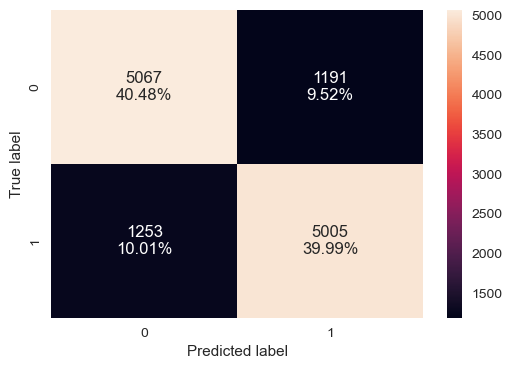

In [383]:
model_confusion_matrix(model13,X_train_os,y_train_os)
plt.show()

In [384]:
LDA_oversampmodel_train_performance=model_performance_classification(model13,X_train_os,y_train_os)
LDA_oversampmodel_train_performance

,Accuracy,Recall,Precision,F1
0,80.47,79.98,80.78,80.38


#### validation performance

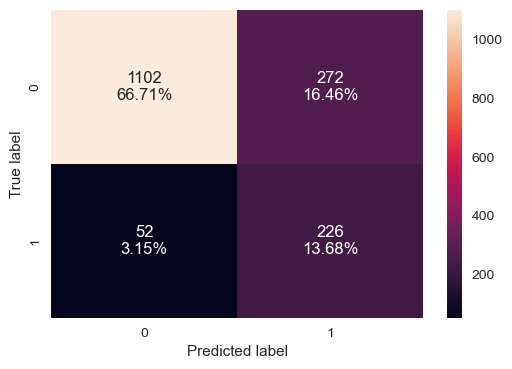

In [385]:
model_confusion_matrix(model13,X_val,y_val)
plt.show()

In [386]:
LDA_oversampmodel_validatiion_performance=model_performance_classification(model13,X_val,y_val)
LDA_oversampmodel_validatiion_performance

,Accuracy,Recall,Precision,F1
0,80.39,81.29,45.38,58.25


In [387]:
LDA_oversamp_data=pd.concat([LDA_oversampmodel_train_performance,LDA_oversampmodel_validatiion_performance]).T
LDA_oversamp_data.columns=['LDA_oversamp_Train','LDA_oversamp_Validation']
LDA_oversamp_data

,LDA_oversamp_Train,LDA_oversamp_Validation
Accuracy,80.47,80.39
Recall,79.98,81.29
Precision,80.78,45.38
F1,80.38,58.25


#### ROC AUC

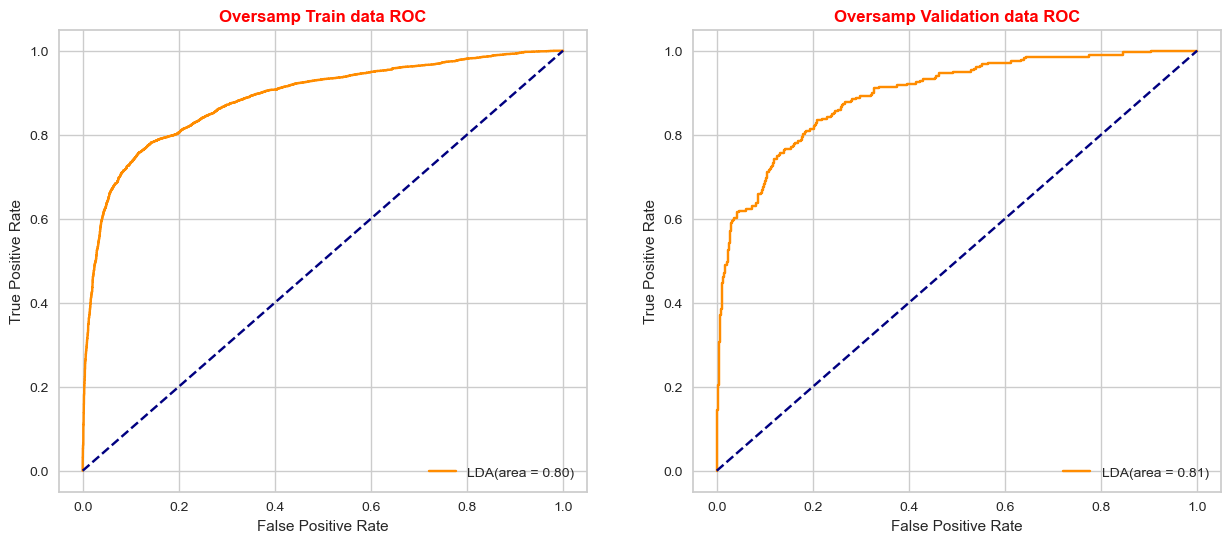

In [388]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))

train_roc = roc_auc_score(y_train_os, model13.predict(X_train_os))
fpr, tpr, thresholds = roc_curve(y_train_os, model13.predict_proba(X_train_os)[:, 1])

ax1.plot(fpr, tpr, color='darkorange',label="LDA(area = %0.2f)" % train_roc)
ax1.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Oversamp Train data ROC",fontweight='bold',color='red')
ax1.legend(loc="lower right")


val_roc = roc_auc_score(y_val, model13.predict(X_val))
fpr, tpr, thresholds = roc_curve(y_val, model13.predict_proba(X_val)[:, 1])

ax2.plot(fpr, tpr, color='darkorange',label="LDA(area = %0.2f)" % val_roc)
ax2.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Oversamp Validation data ROC",fontweight='bold',color='red')
ax2.legend(loc="lower right")

plt.show()

#### Cross validation

In [389]:
scores = cross_validate(model13, X_train_os, y_train_os, scoring=['accuracy','precision', 'recall', 'f1'], cv=skf)
cv_score=pd.DataFrame(scores).iloc[:,2:]
cv_score.mean()

test_accuracy    0.80
test_precision   0.81
test_recall      0.80
test_f1          0.80
dtype: float64

In [390]:
LDA_oversamp_data

,LDA_oversamp_Train,LDA_oversamp_Validation
Accuracy,80.47,80.39
Recall,79.98,81.29
Precision,80.78,45.38
F1,80.38,58.25


## Non-Parametric Models

### 14 KNN Classifier

In [391]:
model14=KNeighborsClassifier(n_neighbors=5)

In [392]:
model14=model14.fit(X_train_os,y_train_os)

#### Train Performance

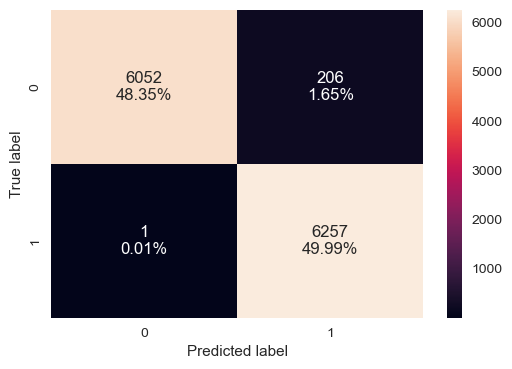

In [393]:
model_confusion_matrix(model14,X_train_os,y_train_os)
plt.show()

In [394]:
KNN_oversampmodel_train_performance=model_performance_classification(model14,X_train_os,y_train_os)
KNN_oversampmodel_train_performance

,Accuracy,Recall,Precision,F1
0,98.35,99.98,96.81,98.37


#### validation performance

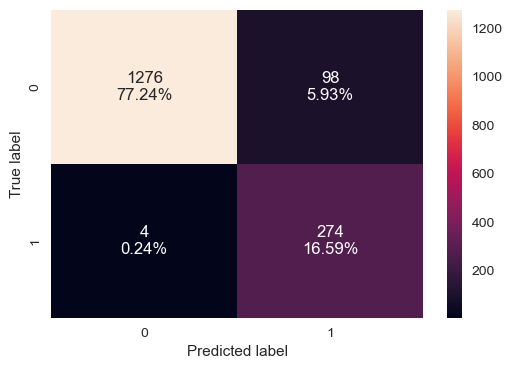

In [395]:
model_confusion_matrix(model14,X_val,y_val)
plt.show()

In [396]:
KNN_oversampmodel_validatiion_performance=model_performance_classification(model14,X_val,y_val)
KNN_oversampmodel_validatiion_performance

,Accuracy,Recall,Precision,F1
0,93.83,98.56,73.66,84.31


In [397]:
KNN_oversamp_data=pd.concat([KNN_oversampmodel_train_performance,KNN_oversampmodel_validatiion_performance]).T
KNN_oversamp_data.columns=['KNN_oversamp_Train','KNN_oversamp_Validation']
KNN_oversamp_data

,KNN_oversamp_Train,KNN_oversamp_Validation
Accuracy,98.35,93.83
Recall,99.98,98.56
Precision,96.81,73.66
F1,98.37,84.31


#### ROC AUC

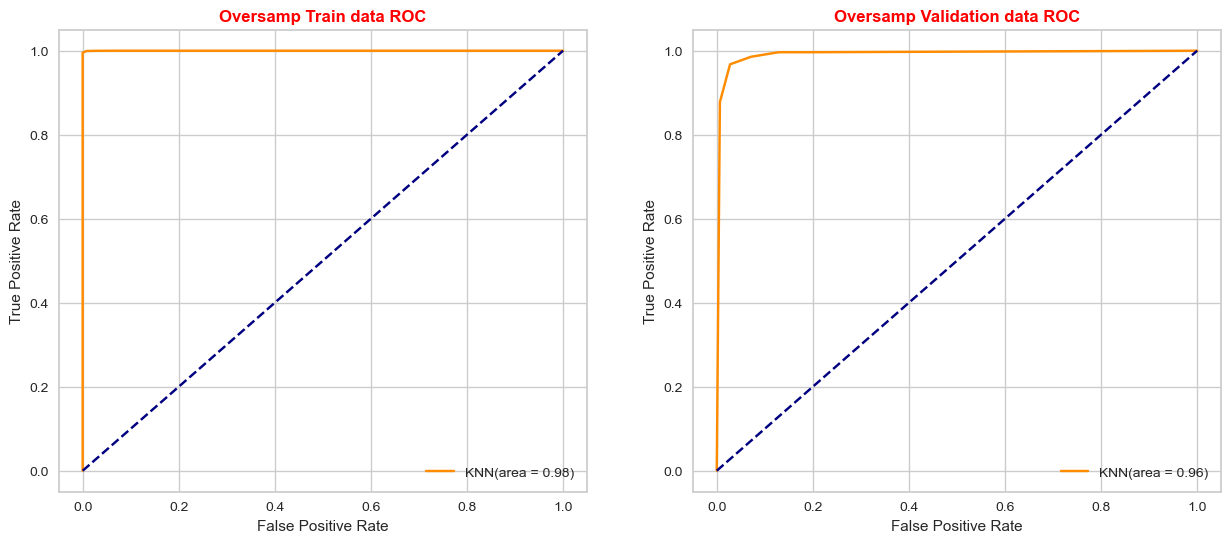

In [398]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))

train_roc = roc_auc_score(y_train_os, model14.predict(X_train_os))
fpr, tpr, thresholds = roc_curve(y_train_os, model14.predict_proba(X_train_os)[:, 1])

ax1.plot(fpr, tpr, color='darkorange',label="KNN(area = %0.2f)" % train_roc)
ax1.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Oversamp Train data ROC",fontweight='bold',color='red')
ax1.legend(loc="lower right")


val_roc = roc_auc_score(y_val, model14.predict(X_val))
fpr, tpr, thresholds = roc_curve(y_val, model14.predict_proba(X_val)[:, 1])

ax2.plot(fpr, tpr, color='darkorange',label="KNN(area = %0.2f)" % val_roc)
ax2.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Oversamp Validation data ROC",fontweight='bold',color='red')
ax2.legend(loc="lower right")

plt.show()

#### Cross validation

In [399]:
scores = cross_validate(model14, X_train_os, y_train_os, scoring=['accuracy','precision', 'recall', 'f1'], cv=skf)
cv_score=pd.DataFrame(scores).iloc[:,2:]
cv_score.mean()

test_accuracy    0.95
test_precision   0.92
test_recall      1.00
test_f1          0.96
dtype: float64

In [400]:
KNN_oversamp_data

,KNN_oversamp_Train,KNN_oversamp_Validation
Accuracy,98.35,93.83
Recall,99.98,98.56
Precision,96.81,73.66
F1,98.37,84.31


### 15 Decision Tree Classifier

In [401]:
model15=DecisionTreeClassifier(random_state=1)

In [402]:
model15=model15.fit(X_train_os,y_train_os)

#### Train Performance

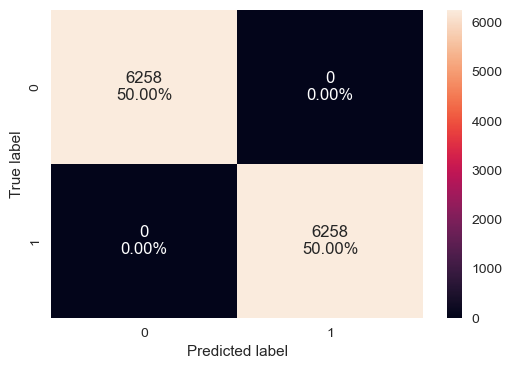

In [403]:
model_confusion_matrix(model15,X_train_os,y_train_os)
plt.show()

In [404]:
DT_oversampmodel_train_performance=model_performance_classification(model15,X_train_os,y_train_os)
DT_oversampmodel_train_performance

,Accuracy,Recall,Precision,F1
0,100.00,100.00,100.00,100.00


#### validation performance

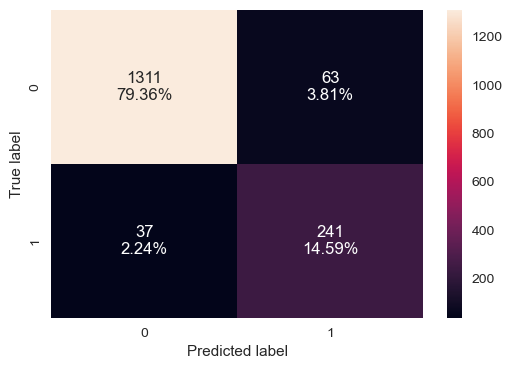

In [405]:
model_confusion_matrix(model15,X_val,y_val)
plt.show()

In [406]:
DT_oversampmodel_validatiion_performance=model_performance_classification(model15,X_val,y_val)
DT_oversampmodel_validatiion_performance

,Accuracy,Recall,Precision,F1
0,93.95,86.69,79.28,82.82


In [407]:
DT_oversamp_data=pd.concat([DT_oversampmodel_train_performance,DT_oversampmodel_validatiion_performance]).T
DT_oversamp_data.columns=['DT_oversamp_Train','DT_oversamp_Validation']
DT_oversamp_data

,DT_oversamp_Train,DT_oversamp_Validation
Accuracy,100.00,93.95
Recall,100.00,86.69
Precision,100.00,79.28
F1,100.00,82.82


#### ROC AUC

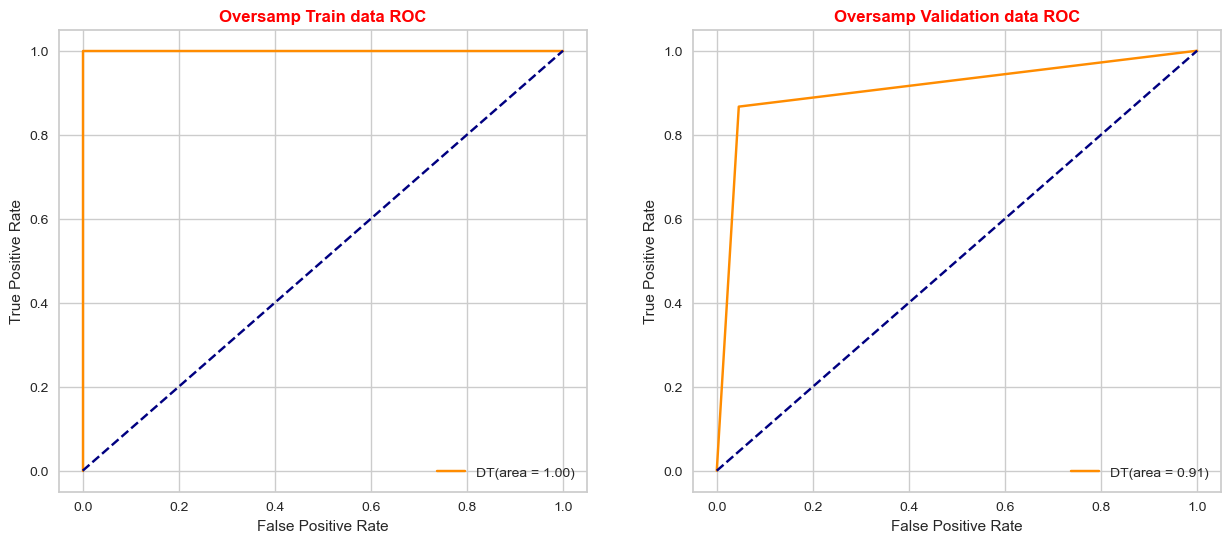

In [408]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))

train_roc = roc_auc_score(y_train_os, model15.predict(X_train_os))
fpr, tpr, thresholds = roc_curve(y_train_os, model15.predict_proba(X_train_os)[:, 1])

ax1.plot(fpr, tpr, color='darkorange',label="DT(area = %0.2f)" % train_roc)
ax1.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Oversamp Train data ROC",fontweight='bold',color='red')
ax1.legend(loc="lower right")


val_roc = roc_auc_score(y_val, model15.predict(X_val))
fpr, tpr, thresholds = roc_curve(y_val, model15.predict_proba(X_val)[:, 1])

ax2.plot(fpr, tpr, color='darkorange',label="DT(area = %0.2f)" % val_roc)
ax2.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Oversamp Validation data ROC",fontweight='bold',color='red')
ax2.legend(loc="lower right")

plt.show()

#### Cross validation

In [409]:
scores = cross_validate(model15, X_train_os, y_train_os, scoring=['accuracy','precision', 'recall', 'f1'], cv=skf)
cv_score=pd.DataFrame(scores).iloc[:,2:]
cv_score.mean()

test_accuracy    0.96
test_precision   0.96
test_recall      0.97
test_f1          0.96
dtype: float64

In [410]:
DT_oversamp_data

,DT_oversamp_Train,DT_oversamp_Validation
Accuracy,100.00,93.95
Recall,100.00,86.69
Precision,100.00,79.28
F1,100.00,82.82


### 16 Bagging Classifier

In [411]:
model16=BaggingClassifier(random_state=1)

In [412]:
model16=model6.fit(X_train_os,y_train_os)

#### Train Performance

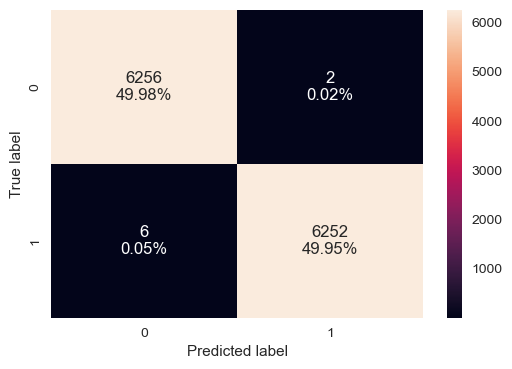

In [413]:
model_confusion_matrix(model16,X_train_os,y_train_os)
plt.show()

In [414]:
Bag_oversampmodel_train_performance=model_performance_classification(model16,X_train_os,y_train_os)
Bag_oversampmodel_train_performance

,Accuracy,Recall,Precision,F1
0,99.94,99.90,99.97,99.94


#### validation performance

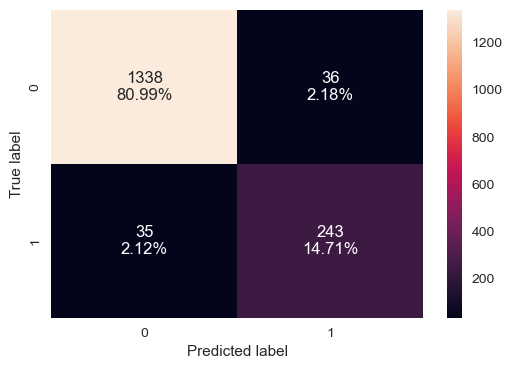

In [415]:
model_confusion_matrix(model16,X_val,y_val)
plt.show()

In [416]:
Bag_oversampmodel_validatiion_performance=model_performance_classification(model16,X_val,y_val)
Bag_oversampmodel_validatiion_performance

,Accuracy,Recall,Precision,F1
0,95.70,87.41,87.10,87.25


In [417]:
Bag_oversamp_data=pd.concat([Bag_oversampmodel_train_performance,Bag_oversampmodel_validatiion_performance]).T
Bag_oversamp_data.columns=['Bag_oversamp_Train','Bag_oversamp_Validation']
Bag_oversamp_data

,Bag_oversamp_Train,Bag_oversamp_Validation
Accuracy,99.94,95.70
Recall,99.90,87.41
Precision,99.97,87.10
F1,99.94,87.25


#### ROC AUC

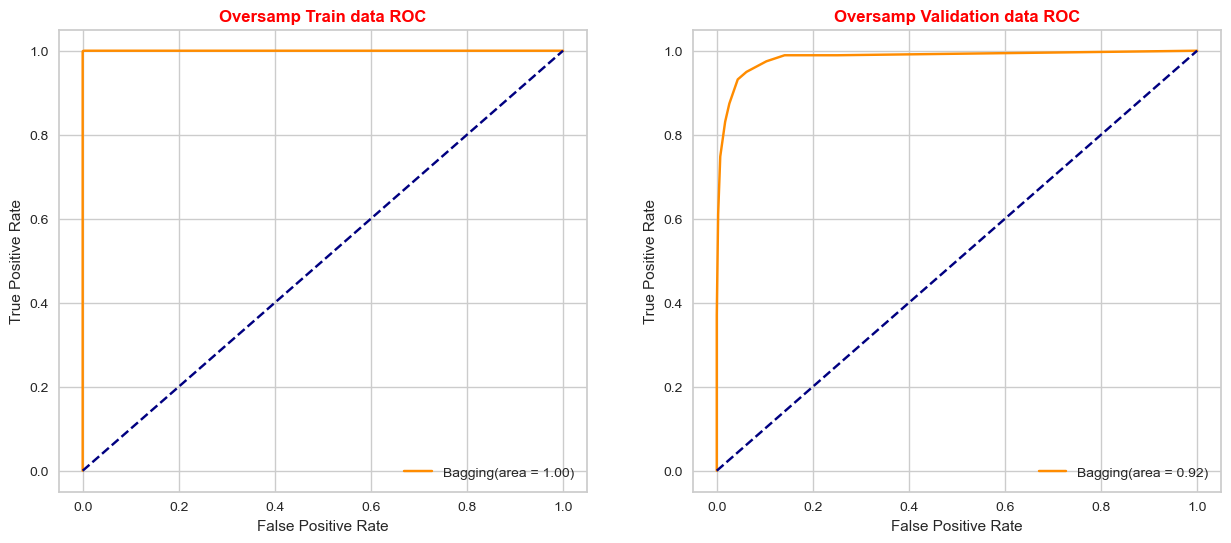

In [418]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))

train_roc = roc_auc_score(y_train_os, model16.predict(X_train_os))
fpr, tpr, thresholds = roc_curve(y_train_os, model16.predict_proba(X_train_os)[:, 1])

ax1.plot(fpr, tpr, color='darkorange',label="Bagging(area = %0.2f)" % train_roc)
ax1.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Oversamp Train data ROC",fontweight='bold',color='red')
ax1.legend(loc="lower right")


val_roc = roc_auc_score(y_val, model16.predict(X_val))
fpr, tpr, thresholds = roc_curve(y_val, model16.predict_proba(X_val)[:, 1])

ax2.plot(fpr, tpr, color='darkorange',label="Bagging(area = %0.2f)" % val_roc)
ax2.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Oversamp Validation data ROC",fontweight='bold',color='red')
ax2.legend(loc="lower right")

plt.show()

#### Cross validation

In [419]:
scores = cross_validate(model16, X_train_os, y_train_os, scoring=['accuracy','precision', 'recall', 'f1'], cv=skf)
cv_score=pd.DataFrame(scores).iloc[:,2:]
cv_score.mean()

test_accuracy    0.98
test_precision   0.98
test_recall      0.98
test_f1          0.98
dtype: float64

In [420]:
Bag_oversamp_data

,Bag_oversamp_Train,Bag_oversamp_Validation
Accuracy,99.94,95.70
Recall,99.90,87.41
Precision,99.97,87.10
F1,99.94,87.25


### 17 Random Forest Classifier

In [421]:
model17=RandomForestClassifier(random_state=1)

In [422]:
model17=model17.fit(X_train_os,y_train_os)

#### Train Performance

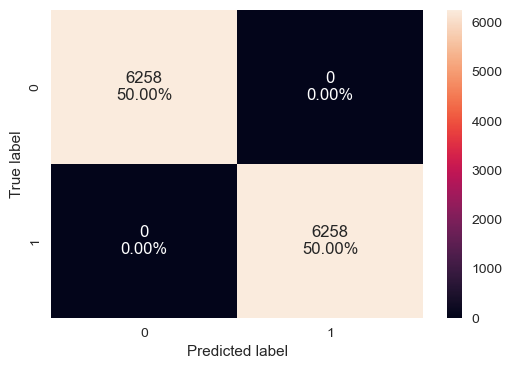

In [423]:
model_confusion_matrix(model17,X_train_os,y_train_os)
plt.show()

In [424]:
RF_oversampmodel_train_performance=model_performance_classification(model17,X_train_os,y_train_os)
RF_oversampmodel_train_performance

,Accuracy,Recall,Precision,F1
0,100.00,100.00,100.00,100.00


#### validation performance

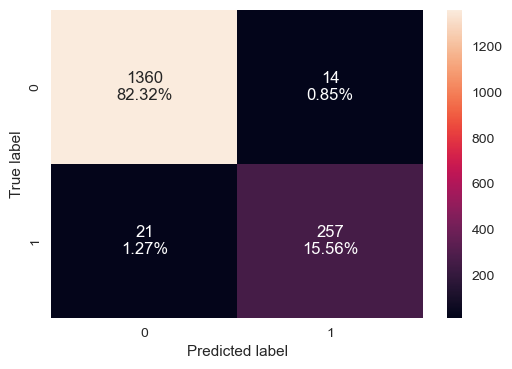

In [425]:
model_confusion_matrix(model17,X_val,y_val)
plt.show()

In [426]:
RF_oversampmodel_validatiion_performance=model_performance_classification(model17,X_val,y_val)
RF_oversampmodel_validatiion_performance

,Accuracy,Recall,Precision,F1
0,97.88,92.45,94.83,93.62


In [427]:
RF_oversamp_data=pd.concat([RF_oversampmodel_train_performance,RF_oversampmodel_validatiion_performance]).T
RF_oversamp_data.columns=['RF_oversamp_Train','RF_oversamp_Validation']
RF_oversamp_data

,RF_oversamp_Train,RF_oversamp_Validation
Accuracy,100.00,97.88
Recall,100.00,92.45
Precision,100.00,94.83
F1,100.00,93.62


#### ROC AUC

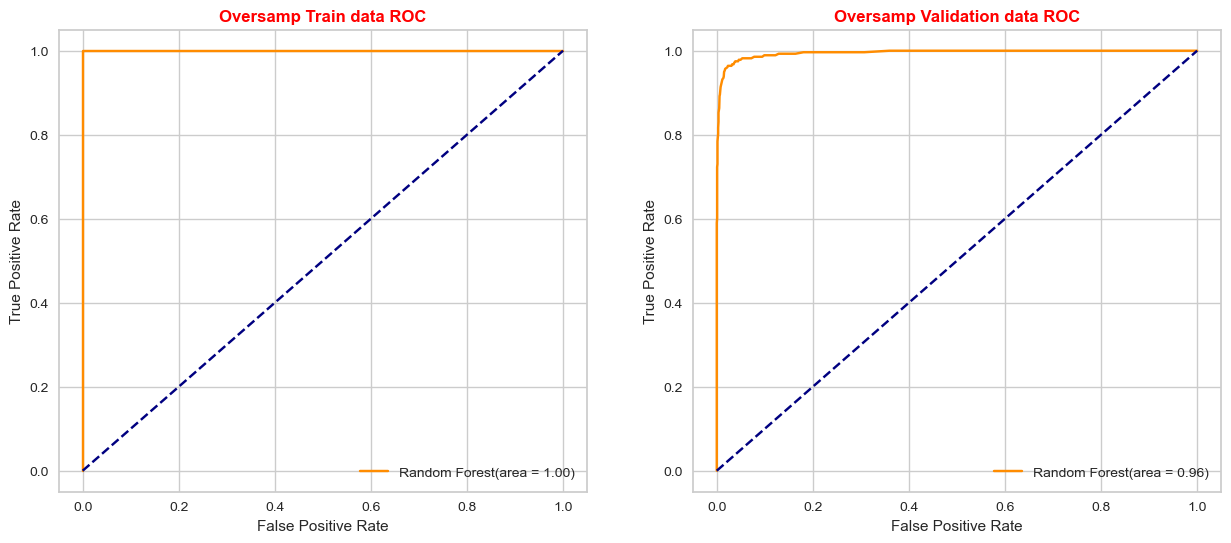

In [428]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))

train_roc = roc_auc_score(y_train_os, model17.predict(X_train_os))
fpr, tpr, thresholds = roc_curve(y_train_os, model17.predict_proba(X_train_os)[:, 1])

ax1.plot(fpr, tpr, color='darkorange',label="Random Forest(area = %0.2f)" % train_roc)
ax1.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Oversamp Train data ROC",fontweight='bold',color='red')
ax1.legend(loc="lower right")


val_roc = roc_auc_score(y_val, model17.predict(X_val))
fpr, tpr, thresholds = roc_curve(y_val, model17.predict_proba(X_val)[:, 1])

ax2.plot(fpr, tpr, color='darkorange',label="Random Forest(area = %0.2f)" % val_roc)
ax2.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Oversamp Validation data ROC",fontweight='bold',color='red')
ax2.legend(loc="lower right")

plt.show()

#### Cross validation

In [429]:
scores = cross_validate(model17, X_train_os, y_train_os, scoring=['accuracy','precision', 'recall', 'f1'], cv=skf)
cv_score=pd.DataFrame(scores).iloc[:,2:]
cv_score.mean()

test_accuracy    0.99
test_precision   0.99
test_recall      0.99
test_f1          0.99
dtype: float64

In [430]:
RF_oversamp_data

,RF_oversamp_Train,RF_oversamp_Validation
Accuracy,100.00,97.88
Recall,100.00,92.45
Precision,100.00,94.83
F1,100.00,93.62


### 18 AdaBoost Classifier

In [431]:
model18=AdaBoostClassifier(random_state=1)

In [432]:
model18=model18.fit(X_train_os,y_train_os)

#### Train Performance

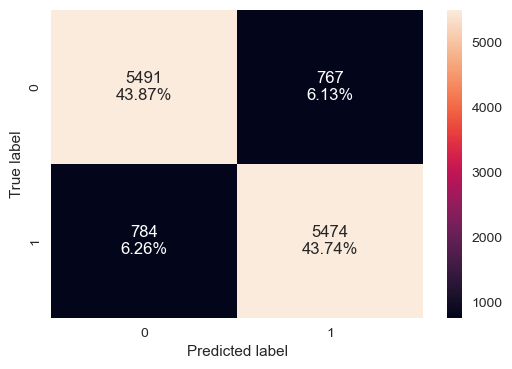

In [433]:
model_confusion_matrix(model18,X_train_os,y_train_os)
plt.show()

In [434]:
AB_oversampmodel_train_performance=model_performance_classification(model18,X_train_os,y_train_os)
AB_oversampmodel_train_performance

,Accuracy,Recall,Precision,F1
0,87.61,87.47,87.71,87.59


#### validation performance

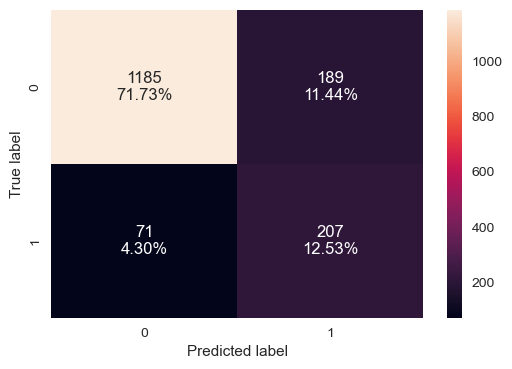

In [435]:
model_confusion_matrix(model18,X_val,y_val)
plt.show()

In [436]:
AB_oversampmodel_validatiion_performance=model_performance_classification(model18,X_val,y_val)
AB_oversampmodel_validatiion_performance

,Accuracy,Recall,Precision,F1
0,84.26,74.46,52.27,61.42


In [437]:
AB_oversamp_data=pd.concat([AB_oversampmodel_train_performance,AB_oversampmodel_validatiion_performance]).T
AB_oversamp_data.columns=['AB_oversamp_Train','AB_oversamp_Validation']
AB_oversamp_data

,AB_oversamp_Train,AB_oversamp_Validation
Accuracy,87.61,84.26
Recall,87.47,74.46
Precision,87.71,52.27
F1,87.59,61.42


#### ROC AUC

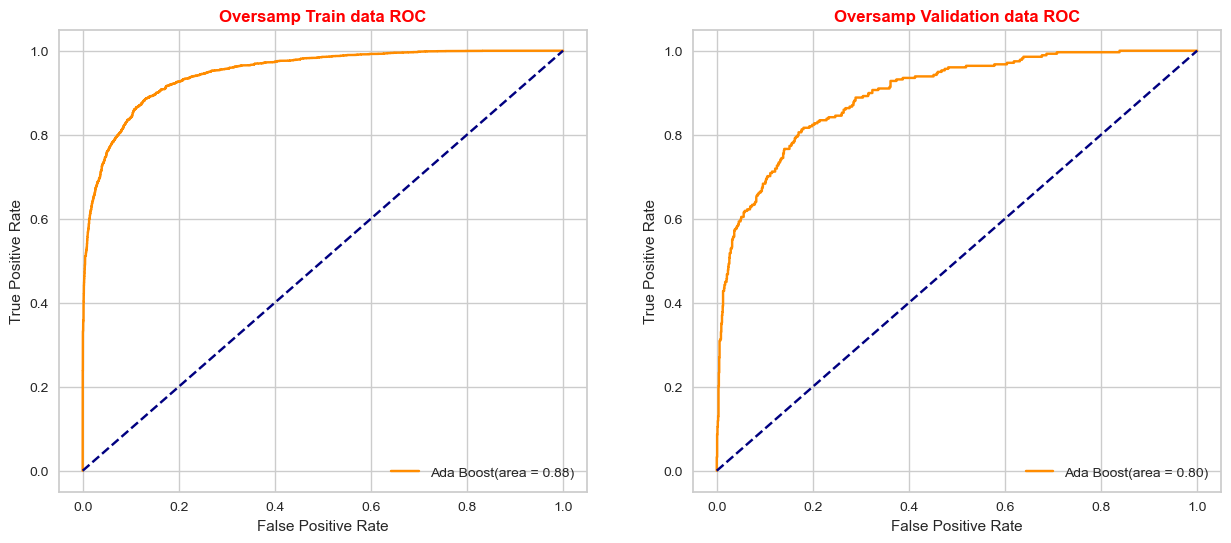

In [438]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))

train_roc = roc_auc_score(y_train_os, model18.predict(X_train_os))
fpr, tpr, thresholds = roc_curve(y_train_os, model18.predict_proba(X_train_os)[:, 1])

ax1.plot(fpr, tpr, color='darkorange',label="Ada Boost(area = %0.2f)" % train_roc)
ax1.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Oversamp Train data ROC",fontweight='bold',color='red')
ax1.legend(loc="lower right")


val_roc = roc_auc_score(y_val, model18.predict(X_val))
fpr, tpr, thresholds = roc_curve(y_val, model18.predict_proba(X_val)[:, 1])

ax2.plot(fpr, tpr, color='darkorange',label="Ada Boost(area = %0.2f)" % val_roc)
ax2.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Oversamp Validation data ROC",fontweight='bold',color='red')
ax2.legend(loc="lower right")

plt.show()

#### Cross validation

In [439]:
scores = cross_validate(model18, X_train_os, y_train_os, scoring=['accuracy','precision', 'recall', 'f1'], cv=skf)
cv_score=pd.DataFrame(scores).iloc[:,2:]
cv_score.mean()

test_accuracy    0.87
test_precision   0.88
test_recall      0.87
test_f1          0.87
dtype: float64

In [440]:
AB_oversamp_data

,AB_oversamp_Train,AB_oversamp_Validation
Accuracy,87.61,84.26
Recall,87.47,74.46
Precision,87.71,52.27
F1,87.59,61.42


### 19 Gradient Boosting Classifier

In [441]:
model19=GradientBoostingClassifier(random_state=1)

In [442]:
model19=model19.fit(X_train_os,y_train_os)

#### Train Performance

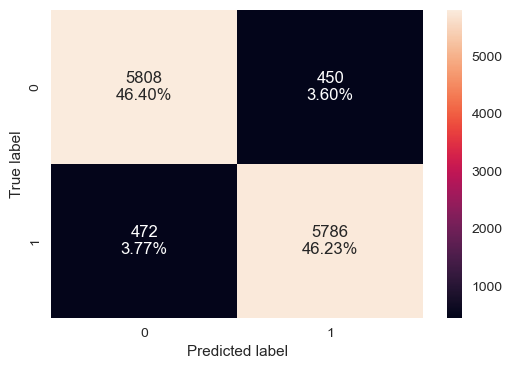

In [443]:
model_confusion_matrix(model19,X_train_os,y_train_os)
plt.show()

In [444]:
GB_oversampmodel_train_performance=model_performance_classification(model19,X_train_os,y_train_os)
GB_oversampmodel_train_performance

,Accuracy,Recall,Precision,F1
0,92.63,92.46,92.78,92.62


#### validation performance

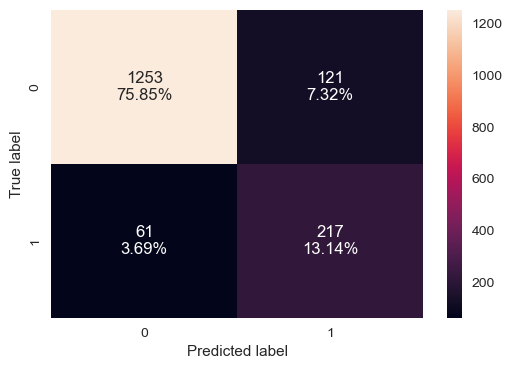

In [445]:
model_confusion_matrix(model19,X_val,y_val)
plt.show()

In [446]:
GB_oversampmodel_validatiion_performance=model_performance_classification(model19,X_val,y_val)
GB_oversampmodel_validatiion_performance

,Accuracy,Recall,Precision,F1
0,88.98,78.06,64.20,70.45


In [447]:
GB_oversamp_data=pd.concat([GB_oversampmodel_train_performance,GB_oversampmodel_validatiion_performance]).T
GB_oversamp_data.columns=['GB_oversamp_Train','GB_oversamp_Validation']
GB_oversamp_data

,GB_oversamp_Train,GB_oversamp_Validation
Accuracy,92.63,88.98
Recall,92.46,78.06
Precision,92.78,64.20
F1,92.62,70.45


#### ROC AUC

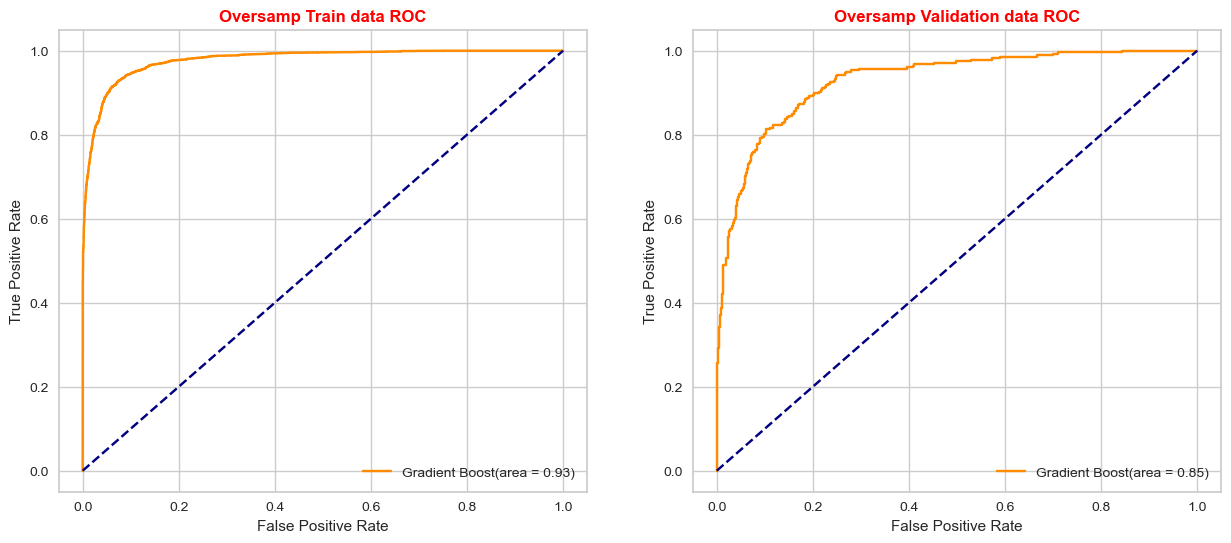

In [448]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))

train_roc = roc_auc_score(y_train_os, model19.predict(X_train_os))
fpr, tpr, thresholds = roc_curve(y_train_os, model19.predict_proba(X_train_os)[:, 1])

ax1.plot(fpr, tpr, color='darkorange',label="Gradient Boost(area = %0.2f)" % train_roc)
ax1.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Oversamp Train data ROC",fontweight='bold',color='red')
ax1.legend(loc="lower right")


val_roc = roc_auc_score(y_val, model19.predict(X_val))
fpr, tpr, thresholds = roc_curve(y_val, model19.predict_proba(X_val)[:, 1])

ax2.plot(fpr, tpr, color='darkorange',label="Gradient Boost(area = %0.2f)" % val_roc)
ax2.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Oversamp Validation data ROC",fontweight='bold',color='red')
ax2.legend(loc="lower right")

plt.show()

#### Cross validation

In [449]:
scores = cross_validate(model19, X_train_os, y_train_os, scoring=['accuracy','precision', 'recall', 'f1'], cv=skf)
cv_score=pd.DataFrame(scores).iloc[:,2:]
cv_score.mean()

test_accuracy    0.92
test_precision   0.92
test_recall      0.92
test_f1          0.92
dtype: float64

In [450]:
GB_oversamp_data

,GB_oversamp_Train,GB_oversamp_Validation
Accuracy,92.63,88.98
Recall,92.46,78.06
Precision,92.78,64.20
F1,92.62,70.45


### 20 XGBoost Classifier

In [451]:
model20=XGBClassifier(random_state=1)

In [452]:
model20=model20.fit(X_train_os,y_train_os)

#### Train Performance

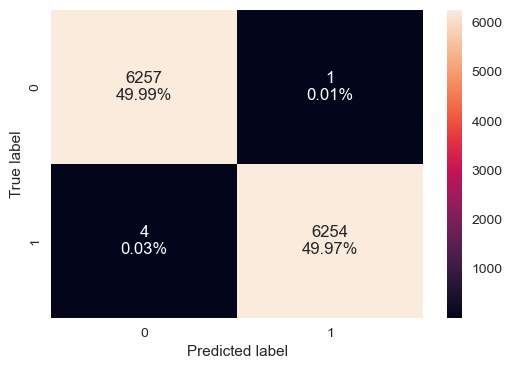

In [453]:
model_confusion_matrix(model20,X_train_os,y_train_os)
plt.show()

In [454]:
XGB_oversampmodel_train_performance=model_performance_classification(model20,X_train_os,y_train_os)
XGB_oversampmodel_train_performance

,Accuracy,Recall,Precision,F1
0,99.96,99.94,99.98,99.96


#### validation performance

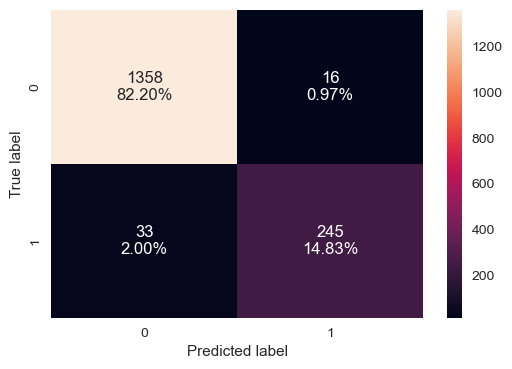

In [455]:
model_confusion_matrix(model20,X_val,y_val)
plt.show()

In [456]:
XGB_oversampmodel_validatiion_performance=model_performance_classification(model20,X_val,y_val)
XGB_oversampmodel_validatiion_performance

,Accuracy,Recall,Precision,F1
0,97.03,88.13,93.87,90.91


In [457]:
XGB_oversamp_data=pd.concat([XGB_oversampmodel_train_performance,XGB_oversampmodel_validatiion_performance]).T
XGB_oversamp_data.columns=['XGB_oversamp_Train','XGB_oversamp_Validation']
XGB_oversamp_data

,XGB_oversamp_Train,XGB_oversamp_Validation
Accuracy,99.96,97.03
Recall,99.94,88.13
Precision,99.98,93.87
F1,99.96,90.91


#### ROC AUC

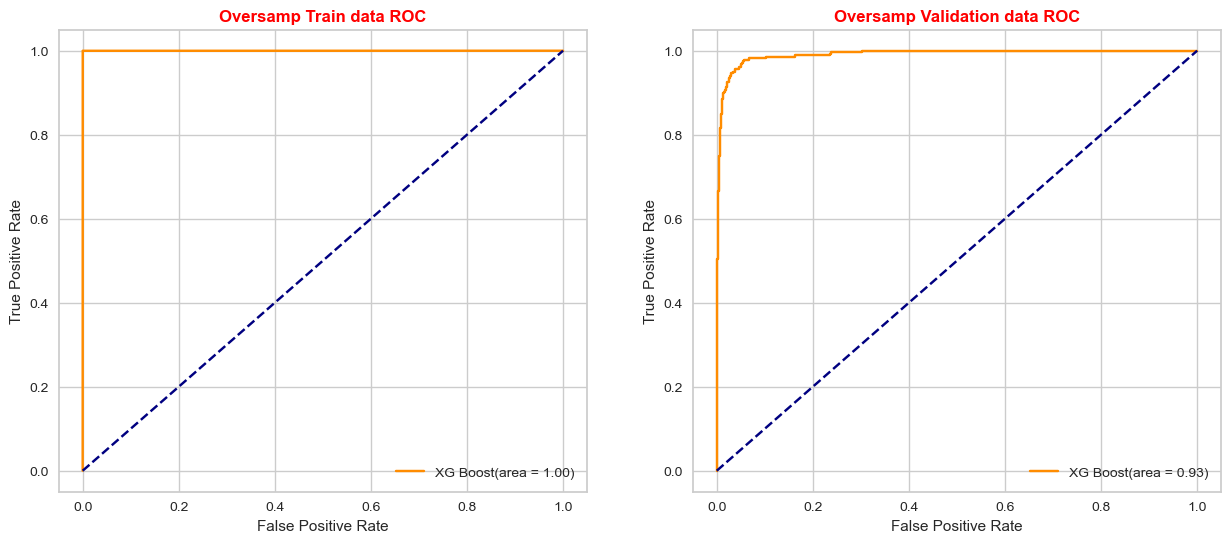

In [458]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))

train_roc = roc_auc_score(y_train_os, model20.predict(X_train_os))
fpr, tpr, thresholds = roc_curve(y_train_os, model20.predict_proba(X_train_os)[:, 1])

ax1.plot(fpr, tpr, color='darkorange',label="XG Boost(area = %0.2f)" % train_roc)
ax1.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Oversamp Train data ROC",fontweight='bold',color='red')
ax1.legend(loc="lower right")


val_roc = roc_auc_score(y_val, model20.predict(X_val))
fpr, tpr, thresholds = roc_curve(y_val, model20.predict_proba(X_val)[:, 1])

ax2.plot(fpr, tpr, color='darkorange',label="XG Boost(area = %0.2f)" % val_roc)
ax2.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Oversamp Validation data ROC",fontweight='bold',color='red')
ax2.legend(loc="lower right")

plt.show()

#### Cross validation

In [459]:
scores = cross_validate(model20, X_train_os, y_train_os, scoring=['accuracy','precision', 'recall', 'f1'], cv=skf)
cv_score=pd.DataFrame(scores).iloc[:,2:]
cv_score.mean()

test_accuracy    0.98
test_precision   0.98
test_recall      0.98
test_f1          0.98
dtype: float64

In [460]:
XGB_oversamp_data

,XGB_oversamp_Train,XGB_oversamp_Validation
Accuracy,99.96,97.03
Recall,99.94,88.13
Precision,99.98,93.87
F1,99.96,90.91


### Comparison

In [461]:
oversamp_data_performance=Logistic_oversamp_data.join(NB_oversamp_data).join(LDA_oversamp_data).join(KNN_oversamp_data).join(DT_oversamp_data).join(Bag_oversamp_data).join(RF_oversamp_data).\
join(AB_oversamp_data).join(GB_oversamp_data).join(XGB_oversamp_data)

In [462]:
oversamp_data_performance.T

,Accuracy,Recall,Precision,F1
LR_oversamp_Train,80.45,80.12,80.65,80.38
LR_oversamp_Validation,80.57,81.29,45.66,58.47
NB_oversamp_Train,74.81,84.56,70.76,77.05
NB_oversamp_Validation,67.19,85.25,32.11,46.65
LDA_oversamp_Train,80.47,79.98,80.78,80.38
LDA_oversamp_Validation,80.39,81.29,45.38,58.25
KNN_oversamp_Train,98.35,99.98,96.81,98.37
KNN_oversamp_Validation,93.83,98.56,73.66,84.31
DT_oversamp_Train,100.00,100.00,100.00,100.00
DT_oversamp_Validation,93.95,86.69,79.28,82.82


In [463]:
validation=[]
for i in oversamp_data_performance.columns:
    if 'Validation' in i:
        validation.append(i)

In [464]:
Train=[]
for i in oversamp_data_performance.columns:
    if 'Train' in i:
        Train.append(i)

In [465]:
oversamp_data_performance[Train].T

,Accuracy,Recall,Precision,F1
LR_oversamp_Train,80.45,80.12,80.65,80.38
NB_oversamp_Train,74.81,84.56,70.76,77.05
LDA_oversamp_Train,80.47,79.98,80.78,80.38
KNN_oversamp_Train,98.35,99.98,96.81,98.37
DT_oversamp_Train,100.00,100.00,100.00,100.00
Bag_oversamp_Train,99.94,99.90,99.97,99.94
RF_oversamp_Train,100.00,100.00,100.00,100.00
AB_oversamp_Train,87.61,87.47,87.71,87.59
GB_oversamp_Train,92.63,92.46,92.78,92.62
XGB_oversamp_Train,99.96,99.94,99.98,99.96


In [466]:
oversamp_data_performance[validation].T

,Accuracy,Recall,Precision,F1
LR_oversamp_Validation,80.57,81.29,45.66,58.47
NB_oversamp_Validation,67.19,85.25,32.11,46.65
LDA_oversamp_Validation,80.39,81.29,45.38,58.25
KNN_oversamp_Validation,93.83,98.56,73.66,84.31
DT_oversamp_Validation,93.95,86.69,79.28,82.82
Bag_oversamp_Validation,95.70,87.41,87.10,87.25
RF_oversamp_Validation,97.88,92.45,94.83,93.62
AB_oversamp_Validation,84.26,74.46,52.27,61.42
GB_oversamp_Validation,88.98,78.06,64.20,70.45
XGB_oversamp_Validation,97.03,88.13,93.87,90.91


DT , Bagging , RF , XG boost on oversample

# Model Tuning

In [467]:
Actual_data_performance

,LR_Train,LR_Validation,NB_Train,NB_Validation,LDA_Train,LDA_Validation,KNN_Train,KNN_Validation,DT_Train,DT_Validation,Bag_Train,Bag_Validation,RF_Train,RF_Validation,AB_Train,AB_Validation,GB_Train,GB_Validation,XGB_Train,XGB_Validation
Accuracy,89.59,90.44,80.98,80.99,89.72,90.19,98.06,95.22,100.00,96.49,99.79,97.58,100.00,97.76,89.07,88.92,91.84,91.28,99.99,97.46
Recall,55.49,56.47,70.83,73.38,60.16,59.35,91.70,77.70,100.00,88.13,98.81,89.57,100.00,88.49,56.36,56.83,62.85,60.43,99.92,89.93
Precision,76.14,80.93,45.76,45.95,73.88,77.10,96.59,92.70,100.00,90.74,99.92,95.77,100.00,98.01,72.53,71.49,84.66,83.17,100.00,94.70
F1,64.20,66.53,55.60,56.51,66.32,67.07,94.08,84.54,100.00,89.42,99.36,92.57,100.00,93.01,63.43,63.33,72.14,70.00,99.96,92.25


In [468]:
oversamp_data_performance

,LR_oversamp_Train,LR_oversamp_Validation,NB_oversamp_Train,NB_oversamp_Validation,LDA_oversamp_Train,LDA_oversamp_Validation,KNN_oversamp_Train,KNN_oversamp_Validation,DT_oversamp_Train,DT_oversamp_Validation,Bag_oversamp_Train,Bag_oversamp_Validation,RF_oversamp_Train,RF_oversamp_Validation,AB_oversamp_Train,AB_oversamp_Validation,GB_oversamp_Train,GB_oversamp_Validation,XGB_oversamp_Train,XGB_oversamp_Validation
Accuracy,80.45,80.57,74.81,67.19,80.47,80.39,98.35,93.83,100.00,93.95,99.94,95.70,100.00,97.88,87.61,84.26,92.63,88.98,99.96,97.03
Recall,80.12,81.29,84.56,85.25,79.98,81.29,99.98,98.56,100.00,86.69,99.90,87.41,100.00,92.45,87.47,74.46,92.46,78.06,99.94,88.13
Precision,80.65,45.66,70.76,32.11,80.78,45.38,96.81,73.66,100.00,79.28,99.97,87.10,100.00,94.83,87.71,52.27,92.78,64.20,99.98,93.87
F1,80.38,58.47,77.05,46.65,80.38,58.25,98.37,84.31,100.00,82.82,99.94,87.25,100.00,93.62,87.59,61.42,92.62,70.45,99.96,90.91


-  Bagging normal data tuning
-  RF Oversampled data tuning
-  XGB on both dataset.

# Model Tuning

In [469]:
%%time
estimator1=DecisionTreeClassifier(random_state=1)

parameters={
     'max_depth':np.arange(2,12,2),
     'min_samples_split':np.arange(0.01,0.15,0.01),
     'min_samples_leaf':np.arange(0.01,0.10,0.01),
     "criterion": ["entropy", "gini"],
     "splitter": ["best", "random"],
}

scorer=make_scorer(recall_score)

rscv=RandomizedSearchCV(estimator=estimator1,param_distributions=parameters,scoring=scorer,cv=skf,random_state=1)

rscv=rscv.fit(X_train,y_train)

estimator1=rscv.best_estimator_

estimator1.fit(X_train,y_train)

print("Best depth:", rscv.best_params_)

Best depth: {'splitter': 'random', 'min_samples_split': 0.13, 'min_samples_leaf': 0.02, 'max_depth': 10, 'criterion': 'entropy'}
CPU times: total: 1.7 s
Wall time: 1.72 s


In [470]:
model_performance_classification(estimator1,X_train,y_train)

,Accuracy,Recall,Precision,F1
0,87.25,56.05,63.76,59.66


In [471]:
model_performance_classification(estimator1,X_val,y_val)

,Accuracy,Recall,Precision,F1
0,87.59,55.40,65.53,60.04


In [472]:
%%time
estimator2=DecisionTreeClassifier()

parameters={
     'max_depth':np.arange(2,12,2),
     "class_weight":[None,'balanced'],
     'min_samples_split':np.arange(0.01,0.15,0.01),
#     'min_samples_leaf':np.arange(0.01,0.10,0.01),
     "criterion": ["entropy", "gini",'log_loss'],
     "splitter": ["best", "random"],
    'random_state':[1,2,3,4,5,42]
}

scorer=make_scorer(recall_score)

rscv=RandomizedSearchCV(estimator=estimator2,param_distributions=parameters,scoring=scorer,cv=5,random_state=1)

rscv=rscv.fit(X_train_os,y_train_os)

estimator2=rscv.best_estimator_

estimator2.fit(X_train_os,y_train_os)

print("Best depth:", rscv.best_params_)

Best depth: {'splitter': 'best', 'random_state': 2, 'min_samples_split': 0.03, 'max_depth': 6, 'criterion': 'gini', 'class_weight': None}
CPU times: total: 3.12 s
Wall time: 3.18 s


In [473]:
model_performance_classification(estimator2,X_train_os,y_train_os)

,Accuracy,Recall,Precision,F1
0,83.62,84.80,82.84,83.81


In [474]:
model_performance_classification(estimator2,X_val,y_val)

,Accuracy,Recall,Precision,F1
0,82.08,82.01,48.10,60.64


## XGB Actual data

In [475]:
%%time
estimator3=XGBClassifier(random_state=1)

parameters={
    'n_estimators':np.arange(100,500,50),
     'max_depth':np.arange(4,12,2),
     'gamma':np.arange(0.01,0.5,0.01),
     'learning_rate':[0.001,0.005,0.01,0.05,0.1],
     'subsample': [0.6, 0.7, 0.8,0.9,1],
     'colsample_bytree':[0.7,0.8,0.9,1],
     'colsample_bynode':[0.7,0.8,0.9,1],
     'colsample_bylevel':[0.7,0.8,0.9,1],
     'reg_alpha':[0.5],
     'reg_lambda':[0.5]
}

scorer=make_scorer(recall_score)

rscv=RandomizedSearchCV(estimator=estimator3,param_distributions=parameters,scoring=scorer,cv=skf,random_state=1)

rscv=rscv.fit(X_train,y_train)

estimator3=rscv.best_estimator_

estimator3.fit(X_train,y_train)

print("Best depth:", rscv.best_params_)

Best depth: {'subsample': 0.6, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 450, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0.48000000000000004, 'colsample_bytree': 0.9, 'colsample_bynode': 1, 'colsample_bylevel': 1}
CPU times: total: 7min 9s
Wall time: 37.3 s


In [476]:
XGB_actual_train=model_performance_classification(estimator3,X_train_os,y_train_os)
XGB_actual_train

,Accuracy,Recall,Precision,F1
0,95.18,90.44,99.91,94.94


In [477]:
XGB_actual_val=model_performance_classification(estimator3,X_val,y_val)
XGB_actual_val

,Accuracy,Recall,Precision,F1
0,96.13,82.73,93.50,87.79


In [478]:
XGB_actual_tuned=pd.concat([XGB_actual_train,XGB_actual_val]).T
XGB_actual_tuned.columns=['XGB_actual_train','XGB_actual_val']
XGB_actual_tuned

,XGB_actual_train,XGB_actual_val
Accuracy,95.18,96.13
Recall,90.44,82.73
Precision,99.91,93.50
F1,94.94,87.79


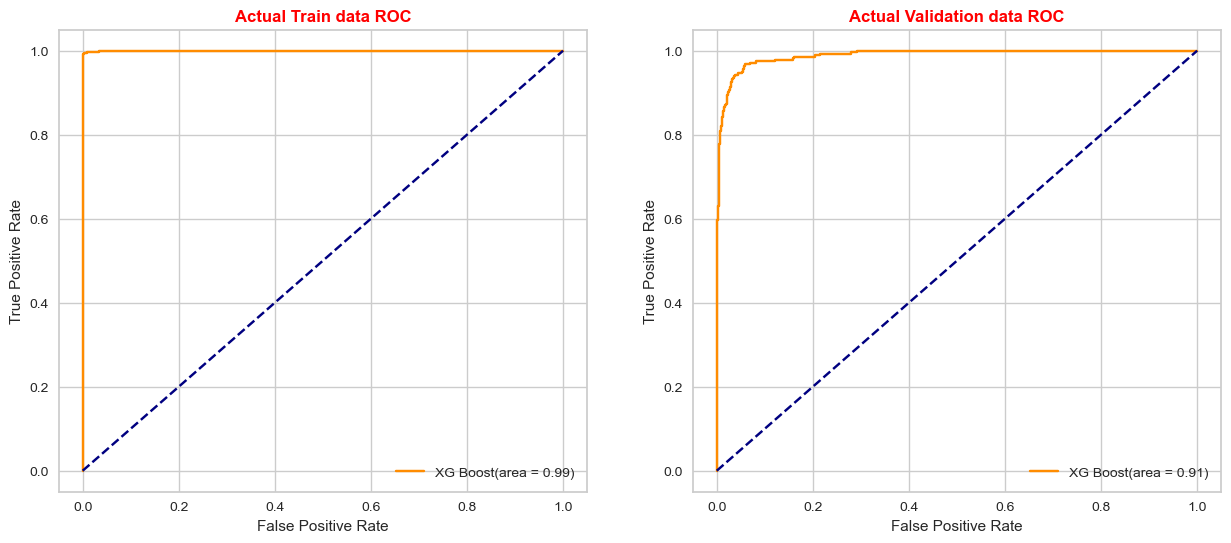

In [479]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))

train_roc = roc_auc_score(y_train, estimator3.predict(X_train))
fpr, tpr, thresholds = roc_curve(y_train, estimator3.predict_proba(X_train)[:, 1])

ax1.plot(fpr, tpr, color='darkorange',label="XG Boost(area = %0.2f)" % train_roc)
ax1.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Actual Train data ROC",fontweight='bold',color='red')
ax1.legend(loc="lower right")


val_roc = roc_auc_score(y_val, estimator3.predict(X_val))
fpr, tpr, thresholds = roc_curve(y_val, estimator3.predict_proba(X_val)[:, 1])

ax2.plot(fpr, tpr, color='darkorange',label="XG Boost(area = %0.2f)" % val_roc)
ax2.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Actual Validation data ROC",fontweight='bold',color='red')
ax2.legend(loc="lower right")

plt.show()

## XGB Oversample data

In [480]:
%%time
estimator4=XGBClassifier(random_state=1,eval_metric='error')

parameters={
    'n_estimators':np.arange(100,500,50),
     'max_depth':np.arange(4,12,2),
     'gamma':np.arange(0.01,0.5,0.01),
     'learning_rate':[0.001,0.005,0.01,0.05,0.1],
     'subsample': [0.6, 0.7, 0.8,0.9,1],
     'colsample_bytree':[0.7,0.8,0.9,1],
     'colsample_bynode':[0.7,0.8,0.9,1],
     'colsample_bylevel':[0.7,0.8,0.9,1],
     'reg_alpha':[0.5,0.6,0.7,0.8,0.9,1],
     'reg_lambda':[0.5,0.6,0.7,0.8,0.9,1]
}

scorer=make_scorer(recall_score)

rscv=RandomizedSearchCV(estimator=estimator4,param_distributions=parameters,scoring=scorer,cv=5,random_state=1)

rscv=rscv.fit(X_train_os,y_train_os)

estimator4=rscv.best_estimator_

estimator4.fit(X_train_os,y_train_os)

print("Best depth:", rscv.best_params_)

Best depth: {'subsample': 0.7, 'reg_lambda': 0.7, 'reg_alpha': 0.6, 'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.1, 'gamma': 0.25, 'colsample_bytree': 0.8, 'colsample_bynode': 0.9, 'colsample_bylevel': 0.7}
CPU times: total: 8min 57s
Wall time: 49.7 s


In [481]:
XGB_oversamp_train=model_performance_classification(estimator4,X_train_os,y_train_os)
XGB_oversamp_train

,Accuracy,Recall,Precision,F1
0,99.88,99.81,99.95,99.88


In [482]:
XGB_oversamp_val=model_performance_classification(estimator4,X_val,y_val)
XGB_oversamp_val

,Accuracy,Recall,Precision,F1
0,96.43,88.85,89.82,89.33


In [483]:
XGB_oversamp_tuned=pd.concat([XGB_oversamp_train,XGB_oversamp_val]).T
XGB_oversamp_tuned.columns=['XGB_oversamp_train','XGB_oversamp_val']
XGB_oversamp_tuned

,XGB_oversamp_train,XGB_oversamp_val
Accuracy,99.88,96.43
Recall,99.81,88.85
Precision,99.95,89.82
F1,99.88,89.33


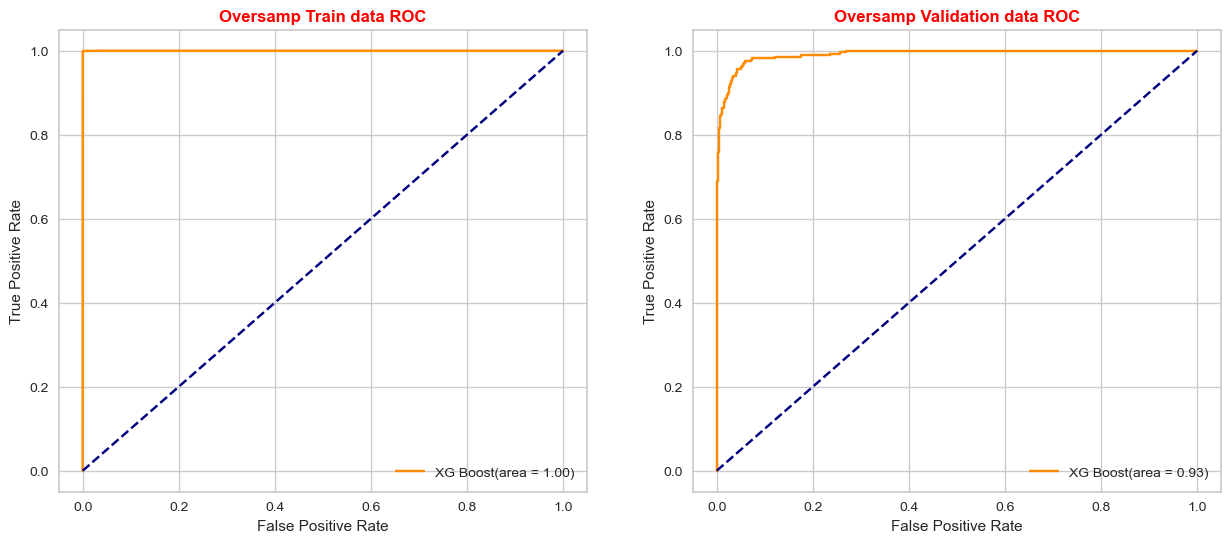

In [484]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))

train_roc = roc_auc_score(y_train_os, estimator4.predict(X_train_os))
fpr, tpr, thresholds = roc_curve(y_train_os, estimator4.predict_proba(X_train_os)[:, 1])

ax1.plot(fpr, tpr, color='darkorange',label="XG Boost(area = %0.2f)" % train_roc)
ax1.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Oversamp Train data ROC",fontweight='bold',color='red')
ax1.legend(loc="lower right")


val_roc = roc_auc_score(y_val, estimator4.predict(X_val))
fpr, tpr, thresholds = roc_curve(y_val, estimator4.predict_proba(X_val)[:, 1])

ax2.plot(fpr, tpr, color='darkorange',label="XG Boost(area = %0.2f)" % val_roc)
ax2.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Oversamp Validation data ROC",fontweight='bold',color='red')
ax2.legend(loc="lower right")

plt.show()

## Random Forest Actual data

In [485]:
%%time
estimator5=RandomForestClassifier(random_state=1)

parameters = {
    "max_depth":[3,4,5,6,7,8,9],
    "max_features":[0.7,0.8,0.9],
    "class_weight":[None,'balanced'],
    "max_samples":[0.7,0.8,0.9],
    'n_estimators':[100,125,150,175,200],
}

scorer=make_scorer(recall_score)

rscv=RandomizedSearchCV(estimator=estimator5,param_distributions=parameters,scoring=scorer,cv=skf,random_state=1)

rscv=rscv.fit(X_train,y_train)

estimator5=rscv.best_estimator_

estimator5.fit(X_train,y_train)

CPU times: total: 2min 37s
Wall time: 2min 43s


RandomForestClassifier(class_weight='balanced', max_depth=9, max_features=0.9,
                       max_samples=0.9, n_estimators=150, random_state=1)

In [486]:
RF_actual_train=model_performance_classification(estimator5,X_train,y_train)
RF_actual_train

,Accuracy,Recall,Precision,F1
0,95.97,94.70,83.54,88.77


In [487]:
RF_actual_val=model_performance_classification(estimator5,X_val,y_val)
RF_actual_val

,Accuracy,Recall,Precision,F1
0,93.22,88.85,75.30,81.52


In [488]:
RF_actual_tuned=pd.concat([RF_actual_train,RF_actual_val]).T
RF_actual_tuned.columns=['RF_actual_train','RF_actual_val']
RF_actual_tuned

,RF_actual_train,RF_actual_val
Accuracy,95.97,93.22
Recall,94.70,88.85
Precision,83.54,75.30
F1,88.77,81.52


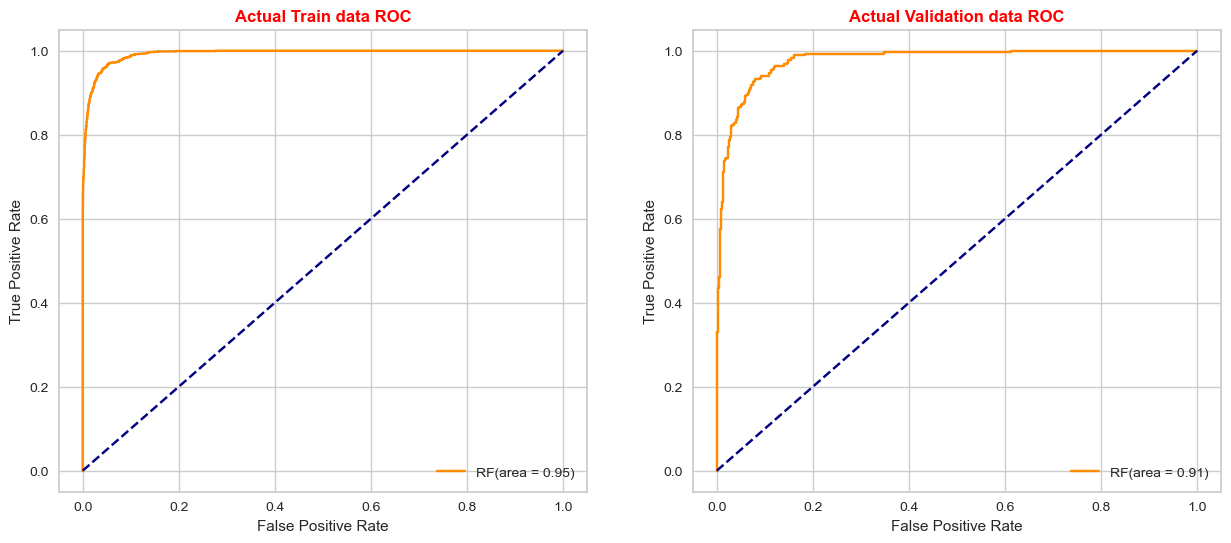

In [489]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))

train_roc = roc_auc_score(y_train, estimator5.predict(X_train))
fpr, tpr, thresholds = roc_curve(y_train, estimator5.predict_proba(X_train)[:, 1])

ax1.plot(fpr, tpr, color='darkorange',label="RF(area = %0.2f)" % train_roc)
ax1.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Actual Train data ROC",fontweight='bold',color='red')
ax1.legend(loc="lower right")


val_roc = roc_auc_score(y_val, estimator5.predict(X_val))
fpr, tpr, thresholds = roc_curve(y_val, estimator5.predict_proba(X_val)[:, 1])

ax2.plot(fpr, tpr, color='darkorange',label="RF(area = %0.2f)" % val_roc)
ax2.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Actual Validation data ROC",fontweight='bold',color='red')
ax2.legend(loc="lower right")

plt.show()

## Random Forest Oversampled data

In [490]:
%%time
estimator6=RandomForestClassifier(random_state=1)

parameters = {
    "max_depth":[3,4,5,6,7,8,9],
    "max_features":[0.7,0.8,0.9],
    "max_samples":[0.7,0.8,0.9],
    'n_estimators':[100,125,150,175,200]
}

scorer=make_scorer(recall_score)

rscv=RandomizedSearchCV(estimator=estimator6,param_distributions=parameters,scoring=scorer,cv=skf,random_state=1)

rscv=rscv.fit(X_train_os,y_train_os)

estimator6=rscv.best_estimator_

estimator6.fit(X_train_os,y_train_os)

CPU times: total: 5min 35s
Wall time: 5min 49s


RandomForestClassifier(max_depth=9, max_features=0.7, max_samples=0.7,
                       n_estimators=125, random_state=1)

In [491]:
RF_oversamp_train=model_performance_classification(estimator6,X_train_os,y_train_os)
RF_oversamp_train

,Accuracy,Recall,Precision,F1
0,96.52,96.50,96.55,96.52


In [492]:
RF_oversamp_val=model_performance_classification(estimator6,X_val,y_val)
RF_oversamp_val

,Accuracy,Recall,Precision,F1
0,92.62,87.41,73.64,79.93


In [493]:
RF_oversamp_tuned=pd.concat([RF_oversamp_train,RF_oversamp_val]).T
RF_oversamp_tuned.columns=['RF_oversamp_train','RF_oversamp_val']
RF_oversamp_tuned

,RF_oversamp_train,RF_oversamp_val
Accuracy,96.52,92.62
Recall,96.50,87.41
Precision,96.55,73.64
F1,96.52,79.93


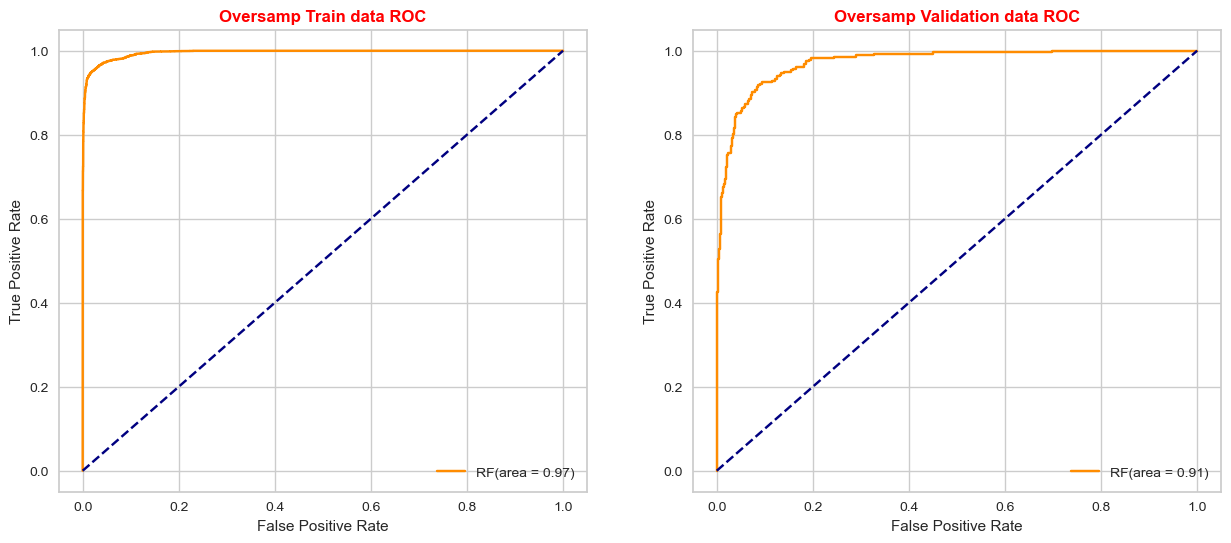

In [494]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))

train_roc = roc_auc_score(y_train_os, estimator6.predict(X_train_os))
fpr, tpr, thresholds = roc_curve(y_train_os, estimator6.predict_proba(X_train_os)[:, 1])

ax1.plot(fpr, tpr, color='darkorange',label="RF(area = %0.2f)" % train_roc)
ax1.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Oversamp Train data ROC",fontweight='bold',color='red')
ax1.legend(loc="lower right")


val_roc = roc_auc_score(y_val, estimator6.predict(X_val))
fpr, tpr, thresholds = roc_curve(y_val, estimator6.predict_proba(X_val)[:, 1])

ax2.plot(fpr, tpr, color='darkorange',label="RF(area = %0.2f)" % val_roc)
ax2.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Oversamp Validation data ROC",fontweight='bold',color='red')
ax2.legend(loc="lower right")

plt.show()

## Bagging Forest Actual data

In [495]:
%%time
estimator7=BaggingClassifier(random_state=1)

parameters = {
    "n_estimators":[50,60,70,80,90,100],
    "max_samples":[0.6,0.7,0.8,0.9],
    "max_features":[0.6,0.7,0.8,0.9],
}

scorer=make_scorer(recall_score)

rscv=RandomizedSearchCV(estimator=estimator7,param_distributions=parameters,scoring=scorer,cv=skf,random_state=1)

rscv=rscv.fit(X_train,y_train)

estimator7=rscv.best_estimator_

estimator7.fit(X_train,y_train)

CPU times: total: 2min 24s
Wall time: 2min 29s


BaggingClassifier(max_features=0.9, max_samples=0.8, n_estimators=60,
                  random_state=1)

In [496]:
Bagging_actual_train=model_performance_classification(estimator7,X_train,y_train)
Bagging_actual_train

,Accuracy,Recall,Precision,F1
0,99.96,99.76,100.00,99.88


In [497]:
Bagging_actual_val=model_performance_classification(estimator7,X_val,y_val)
Bagging_actual_val

,Accuracy,Recall,Precision,F1
0,97.34,88.13,95.70,91.76


In [498]:
Bagging_actual_tuned=pd.concat([Bagging_actual_train,Bagging_actual_val]).T
Bagging_actual_tuned.columns=['Bagging_actual_train','Bagging_actual_val']
Bagging_actual_tuned

,Bagging_actual_train,Bagging_actual_val
Accuracy,99.96,97.34
Recall,99.76,88.13
Precision,100.00,95.70
F1,99.88,91.76


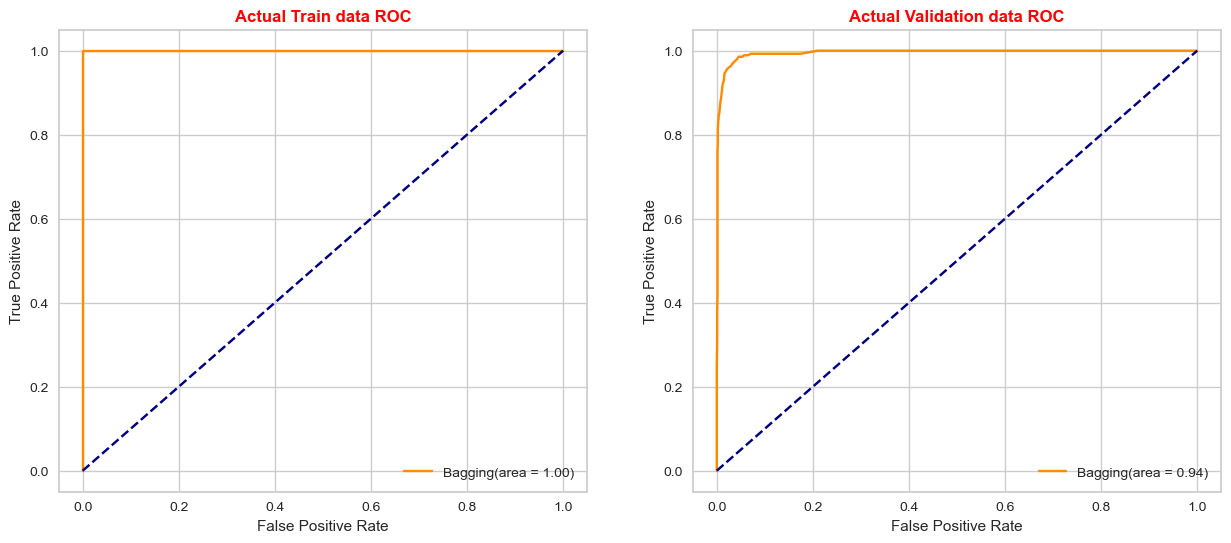

In [499]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))

train_roc = roc_auc_score(y_train, estimator7.predict(X_train))
fpr, tpr, thresholds = roc_curve(y_train, estimator7.predict_proba(X_train)[:, 1])

ax1.plot(fpr, tpr, color='darkorange',label="Bagging(area = %0.2f)" % train_roc)
ax1.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Actual Train data ROC",fontweight='bold',color='red')
ax1.legend(loc="lower right")


val_roc = roc_auc_score(y_val, estimator7.predict(X_val))
fpr, tpr, thresholds = roc_curve(y_val, estimator7.predict_proba(X_val)[:, 1])

ax2.plot(fpr, tpr, color='darkorange',label="Bagging(area = %0.2f)" % val_roc)
ax2.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Actual Validation data ROC",fontweight='bold',color='red')
ax2.legend(loc="lower right")

plt.show()

## Bagging Oversampled data

In [500]:
%%time
estimator8=BaggingClassifier(random_state=1)

parameters = {
    'estimator':[DecisionTreeClassifier(random_state=1)],
    "n_estimators":[50,60,70,80,90,100,120,140],
    "max_samples":[0.6,0.7,0.8],
    "max_features":[0.6,0.7,0.8]
}

scorer=make_scorer(recall_score)

rscv=RandomizedSearchCV(estimator=estimator8,param_distributions=parameters,scoring=scorer,cv=skf,random_state=1)

rscv=rscv.fit(X_train_os,y_train_os)

estimator8=rscv.best_estimator_

estimator8.fit(X_train_os,y_train_os)

CPU times: total: 5min 41s
Wall time: 5min 55s


BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1),
                  max_features=0.8, max_samples=0.6, n_estimators=140,
                  random_state=1)

In [501]:
Bagging_oversamp_train=model_performance_classification(estimator8,X_train_os,y_train_os)
Bagging_oversamp_train

,Accuracy,Recall,Precision,F1
0,99.98,99.97,100.00,99.98


In [502]:
Bagging_oversamp_val=model_performance_classification(estimator8,X_val,y_val)
Bagging_oversamp_val

,Accuracy,Recall,Precision,F1
0,97.40,92.81,91.81,92.31


In [503]:
Bagging_oversamp_tuned=pd.concat([Bagging_oversamp_train,Bagging_oversamp_val]).T
Bagging_oversamp_tuned.columns=['Bagging_oversamp_train','Bagging_oversamp_val']
Bagging_oversamp_tuned

,Bagging_oversamp_train,Bagging_oversamp_val
Accuracy,99.98,97.40
Recall,99.97,92.81
Precision,100.00,91.81
F1,99.98,92.31


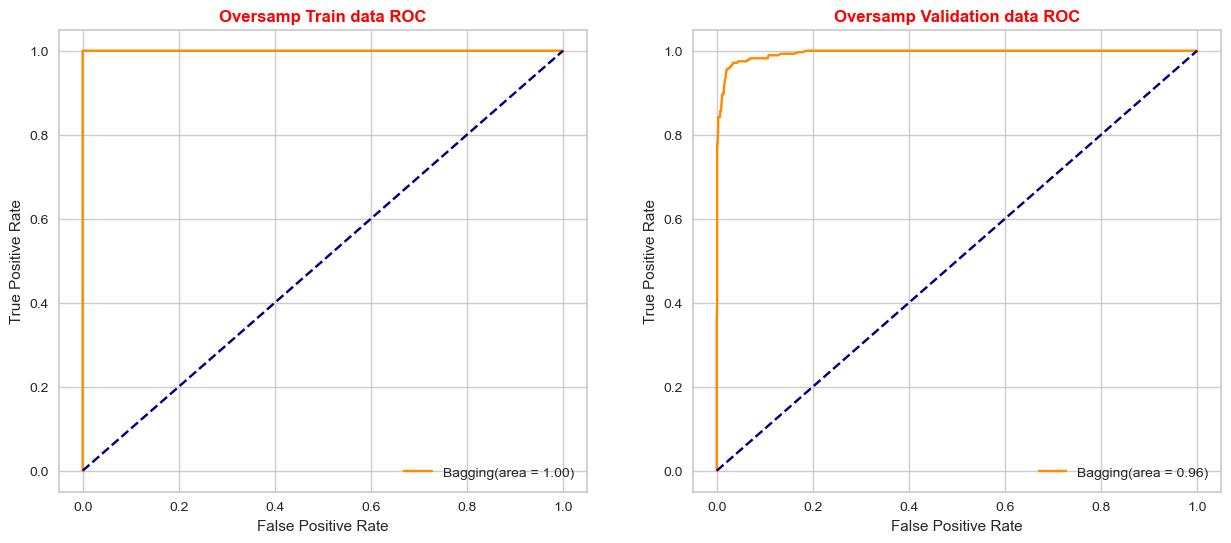

In [504]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,6))

train_roc = roc_auc_score(y_train_os, estimator8.predict(X_train_os))
fpr, tpr, thresholds = roc_curve(y_train_os, estimator8.predict_proba(X_train_os)[:, 1])

ax1.plot(fpr, tpr, color='darkorange',label="Bagging(area = %0.2f)" % train_roc)
ax1.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Oversamp Train data ROC",fontweight='bold',color='red')
ax1.legend(loc="lower right")


val_roc = roc_auc_score(y_val, estimator8.predict(X_val))
fpr, tpr, thresholds = roc_curve(y_val, estimator8.predict_proba(X_val)[:, 1])

ax2.plot(fpr, tpr, color='darkorange',label="Bagging(area = %0.2f)" % val_roc)
ax2.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Oversamp Validation data ROC",fontweight='bold',color='red')
ax2.legend(loc="lower right")

plt.show()

## Comapring Tuned models

In [505]:
Tuned_model_performance=XGB_actual_tuned.join(XGB_oversamp_tuned).join(RF_actual_tuned).join(RF_oversamp_tuned).\
join(Bagging_actual_tuned).join(Bagging_oversamp_tuned)

In [506]:
Tuned_model_performance.T

,Accuracy,Recall,Precision,F1
XGB_actual_train,95.18,90.44,99.91,94.94
XGB_actual_val,96.13,82.73,93.50,87.79
XGB_oversamp_train,99.88,99.81,99.95,99.88
XGB_oversamp_val,96.43,88.85,89.82,89.33
RF_actual_train,95.97,94.70,83.54,88.77
RF_actual_val,93.22,88.85,75.30,81.52
RF_oversamp_train,96.52,96.50,96.55,96.52
RF_oversamp_val,92.62,87.41,73.64,79.93
Bagging_actual_train,99.96,99.76,100.00,99.88
Bagging_actual_val,97.34,88.13,95.70,91.76


# Final model

In [507]:
RF_actual_test=model_performance_classification(estimator5,X_test,y_test).T

In [508]:
RF_actual_test.columns=['RF_actual_test']

In [509]:
RF_actual_tuned.join(RF_actual_test)

,RF_actual_train,RF_actual_val,RF_actual_test
Accuracy,95.97,93.22,93.02
Recall,94.70,88.85,89.38
Precision,83.54,75.30,74.39
F1,88.77,81.52,81.20


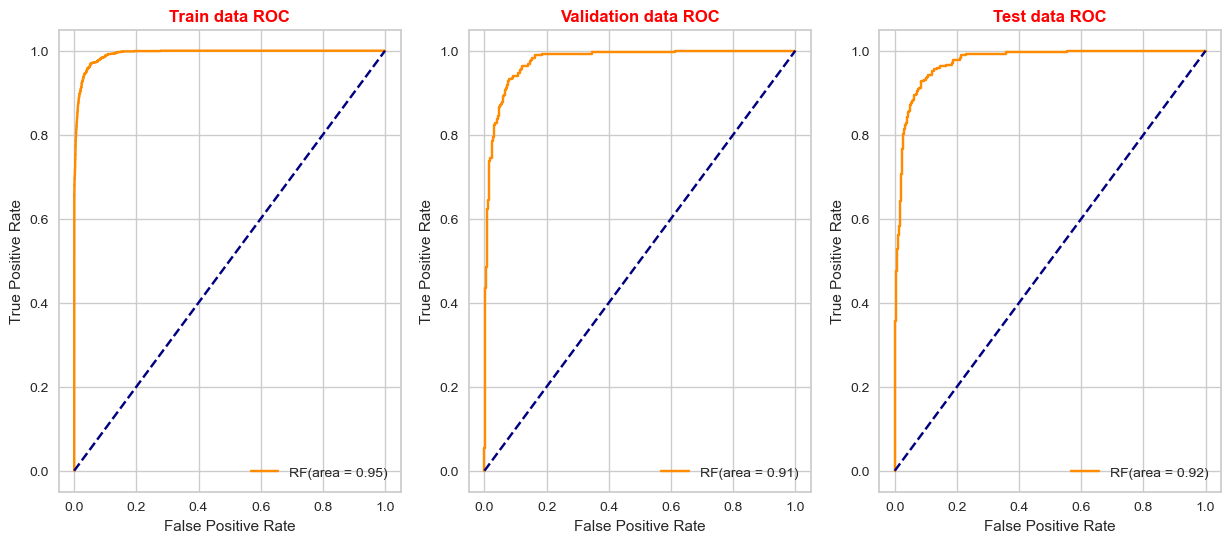

In [510]:
fig,(ax1,ax2,ax3)=plt.subplots(1,3,figsize=(15,6))

train_roc = roc_auc_score(y_train, estimator5.predict(X_train))
fpr, tpr, thresholds = roc_curve(y_train, estimator5.predict_proba(X_train)[:, 1])

ax1.plot(fpr, tpr, color='darkorange',label="RF(area = %0.2f)" % train_roc)
ax1.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("Train data ROC",fontweight='bold',color='red')
ax1.legend(loc="lower right")


val_roc = roc_auc_score(y_val, estimator5.predict(X_val))
fpr, tpr, thresholds = roc_curve(y_val, estimator5.predict_proba(X_val)[:, 1])

ax2.plot(fpr, tpr, color='darkorange',label="RF(area = %0.2f)" % val_roc)
ax2.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("Validation data ROC",fontweight='bold',color='red')
ax2.legend(loc="lower right")

val_roc = roc_auc_score(y_test, estimator5.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, estimator5.predict_proba(X_test)[:, 1])

ax3.plot(fpr, tpr, color='darkorange',label="RF(area = %0.2f)" % val_roc)
ax3.plot([0, 1], [0, 1], color='navy',linestyle='--')
ax3.set_xlabel("False Positive Rate")
ax3.set_ylabel("True Positive Rate")
ax3.set_title("Test data ROC",fontweight='bold',color='red')
ax3.legend(loc="lower right")

plt.show()

# Feature Importance

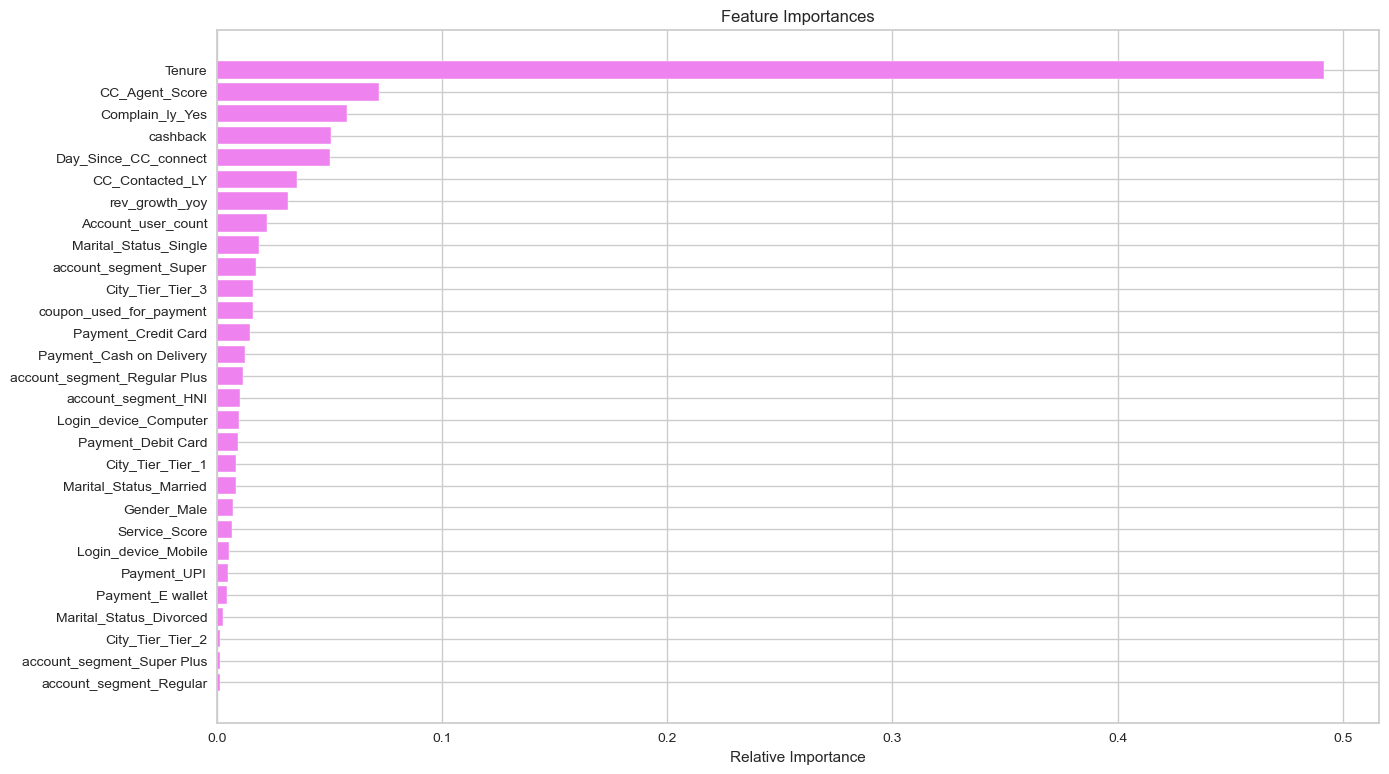

In [511]:
feature_names = X_train.columns.tolist()
importances = estimator5.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(15,9))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()